#no

#no

In [8]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
import cv2
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import time
import seaborn as sns
from scipy.stats import entropy
import warnings
warnings.filterwarnings('ignore')


In [9]:
class ChaoticSystemsGenerator:
    """Enhanced generator for various chaotic systems with metrics"""

    def __init__(self):
        self.dt = 0.01
        self.length = 1000

    def lorenz_system(self, state, t, sigma=10.0, rho=28.0, beta=8.0/3.0):
        """Lorenz chaotic system"""
        x, y, z = state
        return [sigma * (y - x), x * (rho - z) - y, x * y - beta * z]

    def rossler_system(self, state, t, a=0.2, b=0.2, c=5.7):
        """Rossler chaotic system"""
        x, y, z = state
        return [-y - z, x + a * y, b + z * (x - c)]

    def chua_system(self, state, t, alpha=15.6, beta=28.0, m0=-1.143, m1=-0.714):
        """Chua chaotic system"""
        x, y, z = state
        h = m1 * x + 0.5 * (m0 - m1) * (abs(x + 1) - abs(x - 1))
        return [alpha * (y - x - h), x - y + z, -beta * y]

    def henon_map(self, n_points=1000, a=1.4, b=0.3):
        """Henon map chaotic system"""
        x, y = np.zeros(n_points), np.zeros(n_points)
        x[0], y[0] = 0.1, 0.1

        for i in range(1, n_points):
            x[i] = 1 - a * x[i-1]**2 + y[i-1]
            y[i] = b * x[i-1]

        return x

    def logistic_map(self, n_points=1000, r=3.9, x0=0.5):
        """Logistic map chaotic system"""
        x = np.zeros(n_points)
        x[0] = x0

        for i in range(1, n_points):
            x[i] = r * x[i-1] * (1 - x[i-1])

        return x

    def calculate_lyapunov_exponent(self, signal, delay=1):
        """Calculate largest Lyapunov exponent"""
        n = len(signal)
        lyap_sum = 0

        for i in range(n - delay):
            if abs(signal[i+delay] - signal[i]) > 1e-10:
                lyap_sum += np.log(abs(signal[i+delay] - signal[i]))

        return lyap_sum / (n - delay)

    def calculate_correlation_dimension(self, signal, max_r=1.0, n_points=50):
        """Calculate correlation dimension"""
        n = len(signal)
        r_values = np.logspace(-3, np.log10(max_r), n_points)
        correlations = []

        for r in r_values:
            count = 0
            for i in range(n):
                for j in range(i+1, n):
                    if abs(signal[i] - signal[j]) < r:
                        count += 1
            correlations.append(count / (n * (n-1) / 2))

        # Calculate slope (correlation dimension)
        log_r = np.log(r_values[correlations > 0])
        log_c = np.log(correlations[correlations > 0])

        if len(log_r) > 2:
            return np.polyfit(log_r, log_c, 1)[0]
        return 0

    def calculate_entropy(self, signal, bins=50):
        """Calculate Shannon entropy"""
        hist, _ = np.histogram(signal, bins=bins)
        hist = hist / np.sum(hist)
        return entropy(hist[hist > 0])

    def calculate_phase_space_metrics(self, signal, embedding_dim=3, delay=1):
        """Calculate phase space reconstruction metrics"""
        n = len(signal)
        embedded = np.zeros((n - (embedding_dim - 1) * delay, embedding_dim))

        for i in range(embedding_dim):
            embedded[:, i] = signal[i * delay:n - (embedding_dim - 1 - i) * delay]

        # Calculate variance in each dimension
        variances = np.var(embedded, axis=0)

        # Calculate distance matrix
        distances = []
        for i in range(min(1000, len(embedded))):  # Limit for performance
            for j in range(i+1, min(1000, len(embedded))):
                dist = np.linalg.norm(embedded[i] - embedded[j])
                distances.append(dist)

        return {
            'variances': variances,
            'mean_distance': np.mean(distances),
            'std_distance': np.std(distances)
        }

    def analyze_signal_properties(self, signal):
        """Comprehensive signal analysis"""
        return {
            'lyapunov_exponent': self.calculate_lyapunov_exponent(signal),
            'correlation_dimension': self.calculate_correlation_dimension(signal),
            'entropy': self.calculate_entropy(signal),
            'phase_space_metrics': self.calculate_phase_space_metrics(signal),
            'mean': np.mean(signal),
            'std': np.std(signal),
            'min': np.min(signal),
            'max': np.max(signal),
            'autocorrelation': np.corrcoef(signal[:-1], signal[1:])[0, 1]
        }

    def generate_chaotic_signal(self, system_type='lorenz', noise_level=0.0):
        """Generate chaotic signal with analysis"""
        t = np.arange(0, self.length * self.dt, self.dt)
        initial_state = np.random.uniform(-1, 1, 3)

        if system_type == 'lorenz':
            states = odeint(self.lorenz_system, initial_state, t)
            signal = states[:, 0]
        elif system_type == 'rossler':
            states = odeint(self.rossler_system, initial_state, t)
            signal = states[:, 0]
        elif system_type == 'chua':
            states = odeint(self.chua_system, initial_state, t)
            signal = states[:, 0]
        elif system_type == 'henon':
            signal = self.henon_map(self.length)
        elif system_type == 'logistic':
            signal = self.logistic_map(self.length)

        # Add noise if specified
        if noise_level > 0:
            noise = np.random.normal(0, noise_level, len(signal))
            signal += noise

        return signal

    def generate_invalid_signal(self, signal_length=1000):
        """Generate invalid (non-chaotic) signals for training"""
        signal_type = np.random.choice(['sine', 'noise', 'linear', 'exponential', 'polynomial'])

        if signal_type == 'sine':
            t = np.linspace(0, 10, signal_length)
            freq = np.random.uniform(0.1, 2.0)
            phase = np.random.uniform(0, 2*np.pi)
            signal = np.sin(2 * np.pi * freq * t + phase)
        elif signal_type == 'noise':
            signal = np.random.normal(0, 1, signal_length)
        elif signal_type == 'linear':
            signal = np.linspace(-1, 1, signal_length)
        elif signal_type == 'exponential':
            t = np.linspace(0, 5, signal_length)
            signal = np.exp(-t) * np.sin(t)
        else:  # polynomial
            t = np.linspace(-1, 1, signal_length)
            signal = t**3 - 2*t**2 + t

        return signal

In [10]:
class HyperparameterOptimizer:
    """Hyperparameter optimization for the validation system"""

    def __init__(self, validator):
        self.validator = validator
        self.best_params = {}

    def optimize_network_architecture(self, X_train, y_train, X_val, y_val, level='pixel'):
        """Optimize network architecture using grid search"""

        if level == 'pixel':
            param_grid = {
                'conv_filters': [[32, 64], [64, 128], [32, 64, 128]],
                'dense_units': [32, 64, 128],
                'dropout_rate': [0.2, 0.3, 0.4],
                'learning_rate': [0.001, 0.0001]
            }
        elif level == 'block':
            param_grid = {
                'conv_filters': [[64, 128], [128, 256], [64, 128, 256]],
                'lstm_units': [64, 128, 256],
                'dense_units': [64, 128, 256],
                'dropout_rate': [0.3, 0.4, 0.5],
                'learning_rate': [0.001, 0.0001]
            }
        else:  # global
            param_grid = {
                'conv_filters': [[64, 128], [128, 256], [64, 128, 256]],
                'lstm_units': [128, 256, 512],
                'dense_units': [128, 256, 512],
                'dropout_rate': [0.4, 0.5, 0.6],
                'learning_rate': [0.001, 0.0001]
            }

        best_score = 0
        best_params = None

        # Simple grid search (can be replaced with more sophisticated methods)
        for conv_filters in param_grid['conv_filters']:
            for dense_units in param_grid['dense_units']:
                for dropout_rate in param_grid['dropout_rate']:
                    for learning_rate in param_grid['learning_rate']:

                        params = {
                            'conv_filters': conv_filters,
                            'dense_units': dense_units,
                            'dropout_rate': dropout_rate,
                            'learning_rate': learning_rate
                        }

                        if level == 'block' or level == 'global':
                            for lstm_units in param_grid['lstm_units']:
                                params['lstm_units'] = lstm_units
                                score = self.evaluate_params(params, X_train, y_train, X_val, y_val, level)

                                if score > best_score:
                                    best_score = score
                                    best_params = params.copy()
                        else:
                            score = self.evaluate_params(params, X_train, y_train, X_val, y_val, level)

                            if score > best_score:
                                best_score = score
                                best_params = params.copy()

        self.best_params[level] = best_params
        return best_params, best_score

    def evaluate_params(self, params, X_train, y_train, X_val, y_val, level):
        """Evaluate parameter configuration"""
        try:
            model = self.build_model_with_params(params, X_train.shape[1:], level)

            # Compile model
            optimizer = tf.keras.optimizers.Adam(learning_rate=params['learning_rate'])
            model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

            # Train model
            history = model.fit(
                X_train, y_train,
                validation_data=(X_val, y_val),
                epochs=30,  # Reduced for faster optimization
                batch_size=32,
                verbose=0
            )

            # Return best validation accuracy
            return max(history.history['val_accuracy'])

        except Exception as e:
            print(f"Error evaluating params: {e}")
            return 0

    def build_model_with_params(self, params, input_shape, level):
        """Build model with specific parameters"""
        input_layer = layers.Input(shape=input_shape)
        x = input_layer

        # Add convolutional layers
        for filters in params['conv_filters']:
            kernel_size = 3 if level == 'pixel' else 5 if level == 'block' else 10
            x = layers.Conv1D(filters, kernel_size, activation='relu', padding='same')(x)
            x = layers.MaxPooling1D(2)(x)

        # Add LSTM layers for block and global levels
        if level in ['block', 'global']:
            x = layers.LSTM(params['lstm_units'], return_sequences=(level == 'global'))(x)
            if level == 'global':
                x = layers.LSTM(params['lstm_units']//2)(x)
        else:
            x = layers.GlobalAveragePooling1D()(x)

        # Add dense layers
        x = layers.Dense(params['dense_units'], activation='relu')(x)
        x = layers.Dropout(params['dropout_rate'])(x)

        # Output layer
        output = layers.Dense(1, activation='sigmoid')(x)

        return Model(inputs=input_layer, outputs=output)
    """Multi-level validation system for chaotic signals"""

    def __init__(self, signal_length=1000):
        self.signal_length = signal_length
        self.pixel_validator = None
        self.block_validator = None
        self.global_validator = None
        self.ensemble_model = None

    def build_pixel_level_network(self):
        """Build pixel-level validation network"""
        input_layer = layers.Input(shape=(100, 1))  # Small windows

        x = layers.Conv1D(32, 3, activation='relu', padding='same')(input_layer)
        x = layers.MaxPooling1D(2)(x)
        x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
        x = layers.MaxPooling1D(2)(x)
        x = layers.GlobalAveragePooling1D()(x)
        x = layers.Dense(64, activation='relu')(x)
        x = layers.Dropout(0.3)(x)
        output = layers.Dense(1, activation='sigmoid')(x)

        model = Model(inputs=input_layer, outputs=output)
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        return model

    def build_block_level_network(self):
        """Build block-level validation network"""
        input_layer = layers.Input(shape=(200, 1))  # Medium windows

        x = layers.Conv1D(64, 5, activation='relu', padding='same')(input_layer)
        x = layers.MaxPooling1D(2)(x)
        x = layers.Conv1D(128, 5, activation='relu', padding='same')(x)
        x = layers.MaxPooling1D(2)(x)
        x = layers.LSTM(128, return_sequences=True)(x)
        x = layers.LSTM(64)(x)
        x = layers.Dense(128, activation='relu')(x)
        x = layers.Dropout(0.4)(x)
        output = layers.Dense(1, activation='sigmoid')(x)

        model = Model(inputs=input_layer, outputs=output)
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        return model

    def build_global_level_network(self):
        """Build global-level validation network"""
        input_layer = layers.Input(shape=(self.signal_length, 1))

        x = layers.Conv1D(64, 10, activation='relu', padding='same')(input_layer)
        x = layers.MaxPooling1D(4)(x)
        x = layers.Conv1D(128, 10, activation='relu', padding='same')(x)
        x = layers.MaxPooling1D(4)(x)
        x = layers.LSTM(256, return_sequences=True)(x)
        x = layers.Attention()([x, x])  # Self-attention
        x = layers.GlobalAveragePooling1D()(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dropout(0.5)(x)
        output = layers.Dense(1, activation='sigmoid')(x)

        model = Model(inputs=input_layer, outputs=output)
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        return model

    def build_ensemble_model(self):
        """Build ensemble model that combines all levels"""
        pixel_input = layers.Input(shape=(1,), name='pixel_score')
        block_input = layers.Input(shape=(1,), name='block_score')
        global_input = layers.Input(shape=(1,), name='global_score')

        # Learnable weights for combination
        combined = layers.Concatenate()([pixel_input, block_input, global_input])
        x = layers.Dense(16, activation='relu')(combined)
        x = layers.Dense(8, activation='relu')(x)
        output = layers.Dense(1, activation='sigmoid')(x)

        model = Model(inputs=[pixel_input, block_input, global_input], outputs=output)
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        return model

    def prepare_data_for_level(self, signals, labels, window_size):
        """Prepare data for specific validation level"""
        X = []
        y = []

        for i, signal in enumerate(signals):
            # Create overlapping windows
            for j in range(0, len(signal) - window_size + 1, window_size // 2):
                window = signal[j:j + window_size]
                X.append(window.reshape(-1, 1))
                y.append(labels[i])

        return np.array(X), np.array(y)

    def train_all_levels(self, chaotic_signals, non_chaotic_signals, epochs=50):
        """Train all validation levels"""
        # Prepare labels
        chaotic_labels = [1] * len(chaotic_signals)
        non_chaotic_labels = [0] * len(non_chaotic_signals)

        all_signals = chaotic_signals + non_chaotic_signals
        all_labels = chaotic_labels + non_chaotic_labels

        # Shuffle data
        indices = np.random.permutation(len(all_signals))
        all_signals = [all_signals[i] for i in indices]
        all_labels = [all_labels[i] for i in indices]

        # Train pixel-level validator
        print("Training pixel-level validator...")
        self.pixel_validator = self.build_pixel_level_network()
        X_pixel, y_pixel = self.prepare_data_for_level(all_signals, all_labels, 100)
        self.pixel_validator.fit(X_pixel, y_pixel, epochs=epochs, validation_split=0.2, verbose=1)

        # Train block-level validator
        print("Training block-level validator...")
        self.block_validator = self.build_block_level_network()
        X_block, y_block = self.prepare_data_for_level(all_signals, all_labels, 200)
        self.block_validator.fit(X_block, y_block, epochs=epochs, validation_split=0.2, verbose=1)

        # Train global-level validator
        print("Training global-level validator...")
        self.global_validator = self.build_global_level_network()
        X_global = np.array([sig.reshape(-1, 1) for sig in all_signals])
        y_global = np.array(all_labels)
        self.global_validator.fit(X_global, y_global, epochs=epochs, validation_split=0.2, verbose=1)

        # Train ensemble model
        print("Training ensemble model...")
        pixel_scores = []
        block_scores = []
        global_scores = []

        for signal in all_signals:
            pixel_score = self.get_pixel_score(signal)
            block_score = self.get_block_score(signal)
            global_score = self.get_global_score(signal)

            pixel_scores.append(pixel_score)
            block_scores.append(block_score)
            global_scores.append(global_score)

        self.ensemble_model = self.build_ensemble_model()
        self.ensemble_model.fit(
            [np.array(pixel_scores), np.array(block_scores), np.array(global_scores)],
            np.array(all_labels),
            epochs=epochs,
            validation_split=0.2,
            verbose=1
        )

    def get_pixel_score(self, signal):
        """Get pixel-level validation score"""
        X_pixel, _ = self.prepare_data_for_level([signal], [1], 100)
        scores = self.pixel_validator.predict(X_pixel, verbose=0)
        return np.mean(scores)

    def get_block_score(self, signal):
        """Get block-level validation score"""
        X_block, _ = self.prepare_data_for_level([signal], [1], 200)
        scores = self.block_validator.predict(X_block, verbose=0)
        return np.mean(scores)

    def get_global_score(self, signal):
        """Get global-level validation score"""
        X_global = signal.reshape(1, -1, 1)
        score = self.global_validator.predict(X_global, verbose=0)
        return score[0][0]

    def validate_signal(self, signal, use_ensemble=True):
        """Validate chaotic signal using multi-level approach"""
        start_time = time.time()

        # Get scores from all levels
        pixel_score = self.get_pixel_score(signal)
        block_score = self.get_block_score(signal)
        global_score = self.get_global_score(signal)

        if use_ensemble and self.ensemble_model:
            # Use ensemble model for final decision
            final_score = self.ensemble_model.predict(
                [np.array([pixel_score]), np.array([block_score]), np.array([global_score])],
                verbose=0
            )[0][0]
        else:
            # Simple weighted average
            weights = [0.3, 0.4, 0.3]  # Adjust as needed
            final_score = (weights[0] * pixel_score +
                          weights[1] * block_score +
                          weights[2] * global_score)

        validation_time = time.time() - start_time

        return {
            'pixel_score': pixel_score,
            'block_score': block_score,
            'global_score': global_score,
            'final_score': final_score,
            'is_valid': final_score > 0.5,
            'validation_time': validation_time
        }

In [11]:
class ImageEncryptionSystem:
    """Image encryption system using validated chaotic signals"""

    def __init__(self, validator):
        self.validator = validator
        self.chaos_generator = ChaoticSystemsGenerator()

    def generate_validated_key(self, image_shape, max_attempts=10):
        """Generate validated chaotic key for encryption"""
        attempts = 0
        while attempts < max_attempts:
            # Generate chaotic signal
            chaotic_signal = self.chaos_generator.generate_chaotic_signal()

            # Validate signal
            validation_result = self.validator.validate_signal(chaotic_signal)

            if validation_result['is_valid']:
                # Normalize and reshape for encryption
                key = ((chaotic_signal - chaotic_signal.min()) /
                      (chaotic_signal.max() - chaotic_signal.min()) * 255).astype(np.uint8)

                # Repeat or truncate to match image size
                total_pixels = np.prod(image_shape)
                if len(key) < total_pixels:
                    key = np.tile(key, (total_pixels // len(key)) + 1)
                key = key[:total_pixels].reshape(image_shape)

                return key, validation_result

            attempts += 1

        raise ValueError("Could not generate valid chaotic key after {} attempts".format(max_attempts))

    def encrypt_image(self, image):
        """Encrypt image using validated chaotic key"""
        key, validation_info = self.generate_validated_key(image.shape)
        encrypted_image = cv2.bitwise_xor(image, key)

        return encrypted_image, key, validation_info

    def decrypt_image(self, encrypted_image, key):
        """Decrypt image using the same key"""
        decrypted_image = cv2.bitwise_xor(encrypted_image, key)
        return decrypted_image

In [12]:
class MultiLevelChaoticValidator:
    """Multi-level validation system for chaotic signals"""

    def __init__(self, signal_length=1000):
        self.signal_length = signal_length
        self.pixel_validator = None
        self.block_validator = None
        self.global_validator = None
        self.ensemble_model = None

    def build_pixel_level_network(self):
        """Build pixel-level validation network"""
        input_layer = layers.Input(shape=(100, 1))  # Small windows

        x = layers.Conv1D(32, 3, activation='relu', padding='same')(input_layer)
        x = layers.MaxPooling1D(2)(x)
        x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
        x = layers.MaxPooling1D(2)(x)
        x = layers.GlobalAveragePooling1D()(x)
        x = layers.Dense(64, activation='relu')(x)
        x = layers.Dropout(0.3)(x)
        output = layers.Dense(1, activation='sigmoid')(x)

        model = Model(inputs=input_layer, outputs=output)
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        return model

    def build_block_level_network(self):
        """Build block-level validation network"""
        input_layer = layers.Input(shape=(200, 1))  # Medium windows

        x = layers.Conv1D(64, 5, activation='relu', padding='same')(input_layer)
        x = layers.MaxPooling1D(2)(x)
        x = layers.Conv1D(128, 5, activation='relu', padding='same')(x)
        x = layers.MaxPooling1D(2)(x)
        x = layers.LSTM(128, return_sequences=True)(x)
        x = layers.LSTM(64)(x)
        x = layers.Dense(128, activation='relu')(x)
        x = layers.Dropout(0.4)(x)
        output = layers.Dense(1, activation='sigmoid')(x)

        model = Model(inputs=input_layer, outputs=output)
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        return model

    def build_global_level_network(self):
        """Build global-level validation network"""
        input_layer = layers.Input(shape=(self.signal_length, 1))

        x = layers.Conv1D(64, 10, activation='relu', padding='same')(input_layer)
        x = layers.MaxPooling1D(4)(x)
        x = layers.Conv1D(128, 10, activation='relu', padding='same')(x)
        x = layers.MaxPooling1D(4)(x)
        x = layers.LSTM(256, return_sequences=True)(x)
        x = layers.Attention()([x, x])  # Self-attention
        x = layers.GlobalAveragePooling1D()(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dropout(0.5)(x)
        output = layers.Dense(1, activation='sigmoid')(x)

        model = Model(inputs=input_layer, outputs=output)
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        return model

    def build_ensemble_model(self):
        """Build ensemble model that combines all levels"""
        pixel_input = layers.Input(shape=(1,), name='pixel_score')
        block_input = layers.Input(shape=(1,), name='block_score')
        global_input = layers.Input(shape=(1,), name='global_score')

        # Learnable weights for combination
        combined = layers.Concatenate()([pixel_input, block_input, global_input])
        x = layers.Dense(16, activation='relu')(combined)
        x = layers.Dense(8, activation='relu')(x)
        output = layers.Dense(1, activation='sigmoid')(x)

        model = Model(inputs=[pixel_input, block_input, global_input], outputs=output)
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        return model

    def prepare_data_for_level(self, signals, labels, window_size):
        """Prepare data for specific validation level"""
        X = []
        y = []

        for i, signal in enumerate(signals):
            # Create overlapping windows
            for j in range(0, len(signal) - window_size + 1, window_size // 2):
                window = signal[j:j + window_size]
                X.append(window.reshape(-1, 1))
                y.append(labels[i])

        return np.array(X), np.array(y)

    def train_all_levels(self, chaotic_signals, non_chaotic_signals, epochs=50):
        """Train all validation levels"""
        # Prepare labels
        chaotic_labels = [1] * len(chaotic_signals)
        non_chaotic_labels = [0] * len(non_chaotic_signals)

        all_signals = chaotic_signals + non_chaotic_signals
        all_labels = chaotic_labels + non_chaotic_labels

        # Shuffle data
        indices = np.random.permutation(len(all_signals))
        all_signals = [all_signals[i] for i in indices]
        all_labels = [all_labels[i] for i in indices]

        # Train pixel-level validator
        print("Training pixel-level validator...")
        self.pixel_validator = self.build_pixel_level_network()
        X_pixel, y_pixel = self.prepare_data_for_level(all_signals, all_labels, 100)
        history_pixel = self.pixel_validator.fit(X_pixel, y_pixel, epochs=epochs, validation_split=0.2, verbose=1)

        # Train block-level validator
        print("Training block-level validator...")
        self.block_validator = self.build_block_level_network()
        X_block, y_block = self.prepare_data_for_level(all_signals, all_labels, 200)
        history_block = self.block_validator.fit(X_block, y_block, epochs=epochs, validation_split=0.2, verbose=1)

        # Train global-level validator
        print("Training global-level validator...")
        self.global_validator = self.build_global_level_network()
        X_global = np.array([sig.reshape(-1, 1) for sig in all_signals])
        y_global = np.array(all_labels)
        history_global = self.global_validator.fit(X_global, y_global, epochs=epochs, validation_split=0.2, verbose=1)

        # Train ensemble model
        print("Training ensemble model...")
        pixel_scores = []
        block_scores = []
        global_scores = []

        for signal in all_signals:
            pixel_score = self.get_pixel_score(signal)
            block_score = self.get_block_score(signal)
            global_score = self.get_global_score(signal)

            pixel_scores.append(pixel_score)
            block_scores.append(block_score)
            global_scores.append(global_score)

        self.ensemble_model = self.build_ensemble_model()
        history_ensemble = self.ensemble_model.fit(
            [np.array(pixel_scores), np.array(block_scores), np.array(global_scores)],
            np.array(all_labels),
            epochs=epochs,
            validation_split=0.2,
            verbose=1
        )

        return {
            'pixel_history': history_pixel,
            'block_history': history_block,
            'global_history': history_global,
            'ensemble_history': history_ensemble
        }

    def get_pixel_score(self, signal):
        """Get pixel-level validation score"""
        if self.pixel_validator is None:
            return 0.5  # Default score if not trained

        X_pixel, _ = self.prepare_data_for_level([signal], [1], 100)
        if len(X_pixel) == 0:
            return 0.5

        scores = self.pixel_validator.predict(X_pixel, verbose=0)
        return np.mean(scores)

    def get_block_score(self, signal):
        """Get block-level validation score"""
        if self.block_validator is None:
            return 0.5  # Default score if not trained

        X_block, _ = self.prepare_data_for_level([signal], [1], 200)
        if len(X_block) == 0:
            return 0.5

        scores = self.block_validator.predict(X_block, verbose=0)
        return np.mean(scores)

    def get_global_score(self, signal):
        """Get global-level validation score"""
        if self.global_validator is None:
            return 0.5  # Default score if not trained

        # Pad or truncate signal to match expected length
        if len(signal) > self.signal_length:
            signal = signal[:self.signal_length]
        elif len(signal) < self.signal_length:
            signal = np.pad(signal, (0, self.signal_length - len(signal)), mode='constant')

        X_global = signal.reshape(1, -1, 1)
        score = self.global_validator.predict(X_global, verbose=0)
        return score[0][0]

    def validate_signal(self, signal, use_ensemble=True):
        """Validate chaotic signal using multi-level approach"""
        start_time = time.time()

        # Get scores from all levels
        pixel_score = self.get_pixel_score(signal)
        block_score = self.get_block_score(signal)
        global_score = self.get_global_score(signal)

        if use_ensemble and self.ensemble_model is not None:
            # Use ensemble model for final decision
            final_score = self.ensemble_model.predict(
                [np.array([pixel_score]), np.array([block_score]), np.array([global_score])],
                verbose=0
            )[0][0]
        else:
            # Simple weighted average
            weights = [0.3, 0.4, 0.3]  # Adjust as needed
            final_score = (weights[0] * pixel_score +
                          weights[1] * block_score +
                          weights[2] * global_score)

        validation_time = time.time() - start_time

        return {
            'pixel_score': pixel_score,
            'block_score': block_score,
            'global_score': global_score,
            'final_score': final_score,
            'is_valid': final_score > 0.5,
            'validation_time': validation_time
        }

    def evaluate_performance(self, test_chaotic_signals, test_non_chaotic_signals):
        """Evaluate performance on test data"""
        all_test_signals = test_chaotic_signals + test_non_chaotic_signals
        true_labels = [1] * len(test_chaotic_signals) + [0] * len(test_non_chaotic_signals)

        predictions = []
        detailed_results = []

        for signal in all_test_signals:
            result = self.validate_signal(signal)
            predictions.append(1 if result['is_valid'] else 0)
            detailed_results.append(result)

        accuracy = accuracy_score(true_labels, predictions)
        report = classification_report(true_labels, predictions, output_dict=True)

        return {
            'accuracy': accuracy,
            'classification_report': report,
            'detailed_results': detailed_results,
            'predictions': predictions,
            'true_labels': true_labels
        }
    """Hyperparameter optimization for the validation system"""

    def __init__(self, validator):
        self.validator = validator
        self.best_params = {}

    def optimize_network_architecture(self, X_train, y_train, X_val, y_val, level='pixel'):
        """Optimize network architecture using grid search"""

        if level == 'pixel':
            param_grid = {
                'conv_filters': [[32, 64], [64, 128], [32, 64, 128]],
                'dense_units': [32, 64, 128],
                'dropout_rate': [0.2, 0.3, 0.4],
                'learning_rate': [0.001, 0.0001]
            }
        elif level == 'block':
            param_grid = {
                'conv_filters': [[64, 128], [128, 256], [64, 128, 256]],
                'lstm_units': [64, 128, 256],
                'dense_units': [64, 128, 256],
                'dropout_rate': [0.3, 0.4, 0.5],
                'learning_rate': [0.001, 0.0001]
            }
        else:  # global
            param_grid = {
                'conv_filters': [[64, 128], [128, 256], [64, 128, 256]],
                'lstm_units': [128, 256, 512],
                'dense_units': [128, 256, 512],
                'dropout_rate': [0.4, 0.5, 0.6],
                'learning_rate': [0.001, 0.0001]
            }

        best_score = 0
        best_params = None

        # Simple grid search (can be replaced with more sophisticated methods)
        for conv_filters in param_grid['conv_filters']:
            for dense_units in param_grid['dense_units']:
                for dropout_rate in param_grid['dropout_rate']:
                    for learning_rate in param_grid['learning_rate']:

                        params = {
                            'conv_filters': conv_filters,
                            'dense_units': dense_units,
                            'dropout_rate': dropout_rate,
                            'learning_rate': learning_rate
                        }

                        if level == 'block' or level == 'global':
                            for lstm_units in param_grid['lstm_units']:
                                params['lstm_units'] = lstm_units
                                score = self.evaluate_params(params, X_train, y_train, X_val, y_val, level)

                                if score > best_score:
                                    best_score = score
                                    best_params = params.copy()
                        else:
                            score = self.evaluate_params(params, X_train, y_train, X_val, y_val, level)

                            if score > best_score:
                                best_score = score
                                best_params = params.copy()

        self.best_params[level] = best_params
        return best_params, best_score

    def evaluate_params(self, params, X_train, y_train, X_val, y_val, level):
        """Evaluate parameter configuration"""
        try:
            model = self.build_model_with_params(params, X_train.shape[1:], level)

            # Compile model
            optimizer = tf.keras.optimizers.Adam(learning_rate=params['learning_rate'])
            model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

            # Train model
            history = model.fit(
                X_train, y_train,
                validation_data=(X_val, y_val),
                epochs=30,  # Reduced for faster optimization
                batch_size=32,
                verbose=0
            )

            # Return best validation accuracy
            return max(history.history['val_accuracy'])

        except Exception as e:
            print(f"Error evaluating params: {e}")
            return 0

    def build_model_with_params(self, params, input_shape, level):
        """Build model with specific parameters"""
        input_layer = layers.Input(shape=input_shape)
        x = input_layer

        # Add convolutional layers
        for filters in params['conv_filters']:
            kernel_size = 3 if level == 'pixel' else 5 if level == 'block' else 10
            x = layers.Conv1D(filters, kernel_size, activation='relu', padding='same')(x)
            x = layers.MaxPooling1D(2)(x)

        # Add LSTM layers for block and global levels
        if level in ['block', 'global']:
            x = layers.LSTM(params['lstm_units'], return_sequences=(level == 'global'))(x)
            if level == 'global':
                x = layers.LSTM(params['lstm_units']//2)(x)
        else:
            x = layers.GlobalAveragePooling1D()(x)

        # Add dense layers
        x = layers.Dense(params['dense_units'], activation='relu')(x)
        x = layers.Dropout(params['dropout_rate'])(x)

        # Output layer
        output = layers.Dense(1, activation='sigmoid')(x)

        return Model(inputs=input_layer, outputs=output)
    """Multi-level validation system for chaotic signals"""

    def __init__(self, signal_length=1000):
        self.signal_length = signal_length
        self.pixel_validator = None
        self.block_validator = None
        self.global_validator = None
        self.ensemble_model = None

    def build_pixel_level_network(self):
        """Build pixel-level validation network"""
        input_layer = layers.Input(shape=(100, 1))  # Small windows

        x = layers.Conv1D(32, 3, activation='relu', padding='same')(input_layer)
        x = layers.MaxPooling1D(2)(x)
        x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
        x = layers.MaxPooling1D(2)(x)
        x = layers.GlobalAveragePooling1D()(x)
        x = layers.Dense(64, activation='relu')(x)
        x = layers.Dropout(0.3)(x)
        output = layers.Dense(1, activation='sigmoid')(x)

        model = Model(inputs=input_layer, outputs=output)
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        return model

    def build_block_level_network(self):
        """Build block-level validation network"""
        input_layer = layers.Input(shape=(200, 1))  # Medium windows

        x = layers.Conv1D(64, 5, activation='relu', padding='same')(input_layer)
        x = layers.MaxPooling1D(2)(x)
        x = layers.Conv1D(128, 5, activation='relu', padding='same')(x)
        x = layers.MaxPooling1D(2)(x)
        x = layers.LSTM(128, return_sequences=True)(x)
        x = layers.LSTM(64)(x)
        x = layers.Dense(128, activation='relu')(x)
        x = layers.Dropout(0.4)(x)
        output = layers.Dense(1, activation='sigmoid')(x)

        model = Model(inputs=input_layer, outputs=output)
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        return model

    def build_global_level_network(self):
        """Build global-level validation network"""
        input_layer = layers.Input(shape=(self.signal_length, 1))

        x = layers.Conv1D(64, 10, activation='relu', padding='same')(input_layer)
        x = layers.MaxPooling1D(4)(x)
        x = layers.Conv1D(128, 10, activation='relu', padding='same')(x)
        x = layers.MaxPooling1D(4)(x)
        x = layers.LSTM(256, return_sequences=True)(x)
        x = layers.Attention()([x, x])  # Self-attention
        x = layers.GlobalAveragePooling1D()(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dropout(0.5)(x)
        output = layers.Dense(1, activation='sigmoid')(x)

        model = Model(inputs=input_layer, outputs=output)
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        return model

    def build_ensemble_model(self):
        """Build ensemble model that combines all levels"""
        pixel_input = layers.Input(shape=(1,), name='pixel_score')
        block_input = layers.Input(shape=(1,), name='block_score')
        global_input = layers.Input(shape=(1,), name='global_score')

        # Learnable weights for combination
        combined = layers.Concatenate()([pixel_input, block_input, global_input])
        x = layers.Dense(16, activation='relu')(combined)
        x = layers.Dense(8, activation='relu')(x)
        output = layers.Dense(1, activation='sigmoid')(x)

        model = Model(inputs=[pixel_input, block_input, global_input], outputs=output)
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        return model

    def prepare_data_for_level(self, signals, labels, window_size):
        """Prepare data for specific validation level"""
        X = []
        y = []

        for i, signal in enumerate(signals):
            # Create overlapping windows
            for j in range(0, len(signal) - window_size + 1, window_size // 2):
                window = signal[j:j + window_size]
                X.append(window.reshape(-1, 1))
                y.append(labels[i])

        return np.array(X), np.array(y)

    def train_all_levels(self, chaotic_signals, non_chaotic_signals, epochs=50):
        """Train all validation levels"""
        # Prepare labels
        chaotic_labels = [1] * len(chaotic_signals)
        non_chaotic_labels = [0] * len(non_chaotic_signals)

        all_signals = chaotic_signals + non_chaotic_signals
        all_labels = chaotic_labels + non_chaotic_labels

        # Shuffle data
        indices = np.random.permutation(len(all_signals))
        all_signals = [all_signals[i] for i in indices]
        all_labels = [all_labels[i] for i in indices]

        # Train pixel-level validator
        print("Training pixel-level validator...")
        self.pixel_validator = self.build_pixel_level_network()
        X_pixel, y_pixel = self.prepare_data_for_level(all_signals, all_labels, 100)
        self.pixel_validator.fit(X_pixel, y_pixel, epochs=epochs, validation_split=0.2, verbose=1)

        # Train block-level validator
        print("Training block-level validator...")
        self.block_validator = self.build_block_level_network()
        X_block, y_block = self.prepare_data_for_level(all_signals, all_labels, 200)
        self.block_validator.fit(X_block, y_block, epochs=epochs, validation_split=0.2, verbose=1)

        # Train global-level validator
        print("Training global-level validator...")
        self.global_validator = self.build_global_level_network()
        X_global = np.array([sig.reshape(-1, 1) for sig in all_signals])
        y_global = np.array(all_labels)
        self.global_validator.fit(X_global, y_global, epochs=epochs, validation_split=0.2, verbose=1)

        # Train ensemble model
        print("Training ensemble model...")
        pixel_scores = []
        block_scores = []
        global_scores = []

        for signal in all_signals:
            pixel_score = self.get_pixel_score(signal)
            block_score = self.get_block_score(signal)
            global_score = self.get_global_score(signal)

            pixel_scores.append(pixel_score)
            block_scores.append(block_score)
            global_scores.append(global_score)

        self.ensemble_model = self.build_ensemble_model()
        self.ensemble_model.fit(
            [np.array(pixel_scores), np.array(block_scores), np.array(global_scores)],
            np.array(all_labels),
            epochs=epochs,
            validation_split=0.2,
            verbose=1
        )

    def get_pixel_score(self, signal):
        """Get pixel-level validation score"""
        X_pixel, _ = self.prepare_data_for_level([signal], [1], 100)
        scores = self.pixel_validator.predict(X_pixel, verbose=0)
        return np.mean(scores)

    def get_block_score(self, signal):
        """Get block-level validation score"""
        X_block, _ = self.prepare_data_for_level([signal], [1], 200)
        scores = self.block_validator.predict(X_block, verbose=0)
        return np.mean(scores)

    def get_global_score(self, signal):
        """Get global-level validation score"""
        X_global = signal.reshape(1, -1, 1)
        score = self.global_validator.predict(X_global, verbose=0)
        return score[0][0]

    def validate_signal(self, signal, use_ensemble=True):
        """Validate chaotic signal using multi-level approach"""
        start_time = time.time()

        # Get scores from all levels
        pixel_score = self.get_pixel_score(signal)
        block_score = self.get_block_score(signal)
        global_score = self.get_global_score(signal)

        if use_ensemble and self.ensemble_model:
            # Use ensemble model for final decision
            final_score = self.ensemble_model.predict(
                [np.array([pixel_score]), np.array([block_score]), np.array([global_score])],
                verbose=0
            )[0][0]
        else:
            # Simple weighted average
            weights = [0.3, 0.4, 0.3]  # Adjust as needed
            final_score = (weights[0] * pixel_score +
                          weights[1] * block_score +
                          weights[2] * global_score)

        validation_time = time.time() - start_time

        return {
            'pixel_score': pixel_score,
            'block_score': block_score,
            'global_score': global_score,
            'final_score': final_score,
            'is_valid': final_score > 0.5,
            'validation_time': validation_time
        }


In [13]:
class VisualizationSystem:
    """Advanced visualization system for chaos analysis"""

    def __init__(self):
        plt.style.use('seaborn-v0_8')
        self.colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']

    def plot_chaotic_systems_comparison(self, chaos_generator, save_path=None):
        """Compare different chaotic systems"""
        systems = ['lorenz', 'rossler', 'chua', 'henon', 'logistic']

        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        axes = axes.flatten()

        for i, system in enumerate(systems):
            signal = chaos_generator.generate_chaotic_signal(system)
            properties = chaos_generator.analyze_signal_properties(signal)

            # Time series plot
            axes[i].plot(signal[:500], color=self.colors[i], linewidth=1.5)
            axes[i].set_title(f'{system.capitalize()} System\nLyapunov: {properties["lyapunov_exponent"]:.3f}',
                            fontsize=12, fontweight='bold')
            axes[i].set_xlabel('Time Steps')
            axes[i].set_ylabel('Amplitude')
            axes[i].grid(True, alpha=0.3)

        # Summary statistics
        axes[5].axis('off')
        summary_text = "Chaotic Systems Analysis\n\n"

        for system in systems:
            signal = chaos_generator.generate_chaotic_signal(system)
            props = chaos_generator.analyze_signal_properties(signal)
            summary_text += f"{system.capitalize()}:\n"
            summary_text += f"  Lyapunov: {props['lyapunov_exponent']:.3f}\n"
            summary_text += f"  Entropy: {props['entropy']:.3f}\n"
            summary_text += f"  Correlation Dim: {props['correlation_dimension']:.3f}\n\n"

        axes[5].text(0.1, 0.9, summary_text, transform=axes[5].transAxes,
                    fontsize=10, verticalalignment='top',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def plot_phase_space(self, signal, embedding_dim=3, delay=1, save_path=None):
        """Plot phase space reconstruction"""
        n = len(signal)
        embedded = np.zeros((n - (embedding_dim - 1) * delay, embedding_dim))

        for i in range(embedding_dim):
            embedded[:, i] = signal[i * delay:n - (embedding_dim - 1 - i) * delay]

        fig = plt.figure(figsize=(15, 5))

        # 2D projections
        projections = [(0, 1), (0, 2), (1, 2)]
        for i, (x_idx, y_idx) in enumerate(projections):
            ax = fig.add_subplot(1, 3, i+1)
            ax.scatter(embedded[:, x_idx], embedded[:, y_idx],
                      c=np.arange(len(embedded)), cmap='viridis', s=1, alpha=0.7)
            ax.set_xlabel(f'Dimension {x_idx + 1}')
            ax.set_ylabel(f'Dimension {y_idx + 1}')
            ax.set_title(f'Phase Space Projection {x_idx+1}-{y_idx+1}')
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def plot_validation_results(self, validation_results, save_path=None):
        """Plot validation results analysis"""
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        # Extract data
        pixel_scores = [r['pixel_score'] for r in validation_results]
        block_scores = [r['block_score'] for r in validation_results]
        global_scores = [r['global_score'] for r in validation_results]
        final_scores = [r['final_score'] for r in validation_results]
        is_valid = [r['is_valid'] for r in validation_results]

        # Score distribution
        axes[0, 0].hist(pixel_scores, bins=20, alpha=0.7, label='Pixel', color=self.colors[0])
        axes[0, 0].hist(block_scores, bins=20, alpha=0.7, label='Block', color=self.colors[1])
        axes[0, 0].hist(global_scores, bins=20, alpha=0.7, label='Global', color=self.colors[2])
        axes[0, 0].set_xlabel('Validation Score')
        axes[0, 0].set_ylabel('Frequency')
        axes[0, 0].set_title('Score Distribution by Level')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        # Correlation between levels
        axes[0, 1].scatter(pixel_scores, block_scores, alpha=0.6, color=self.colors[0])
        axes[0, 1].set_xlabel('Pixel Score')
        axes[0, 1].set_ylabel('Block Score')
        axes[0, 1].set_title('Pixel vs Block Correlation')
        axes[0, 1].grid(True, alpha=0.3)

        # Final score vs validity
        valid_scores = [s for s, v in zip(final_scores, is_valid) if v]
        invalid_scores = [s for s, v in zip(final_scores, is_valid) if not v]

        axes[1, 0].hist(valid_scores, bins=15, alpha=0.7, label='Valid', color='green')
        axes[1, 0].hist(invalid_scores, bins=15, alpha=0.7, label='Invalid', color='red')
        axes[1, 0].axvline(x=0.5, color='black', linestyle='--', label='Threshold')
        axes[1, 0].set_xlabel('Final Score')
        axes[1, 0].set_ylabel('Frequency')
        axes[1, 0].set_title('Final Score Distribution')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)

        # Performance metrics
        levels = ['Pixel', 'Block', 'Global', 'Final']
        scores = [np.mean(pixel_scores), np.mean(block_scores),
                 np.mean(global_scores), np.mean(final_scores)]

        bars = axes[1, 1].bar(levels, scores, color=self.colors[:4])
        axes[1, 1].set_ylabel('Average Score')
        axes[1, 1].set_title('Average Validation Scores by Level')
        axes[1, 1].grid(True, alpha=0.3)

        # Add value labels on bars
        for bar, score in zip(bars, scores):
            height = bar.get_height()
            axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                          f'{score:.3f}', ha='center', va='bottom')

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def plot_encryption_analysis(self, original_image, encrypted_image, key, save_path=None):
        """Analyze encryption results"""
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))

        # Original image
        axes[0, 0].imshow(original_image, cmap='gray')
        axes[0, 0].set_title('Original Image')
        axes[0, 0].axis('off')

        # Encrypted image
        axes[0, 1].imshow(encrypted_image, cmap='gray')
        axes[0, 1].set_title('Encrypted Image')
        axes[0, 1].axis('off')

        # Key visualization
        axes[0, 2].imshow(key, cmap='viridis')
        axes[0, 2].set_title('Chaotic Key')
        axes[0, 2].axis('off')

        # Histograms
        axes[1, 0].hist(original_image.flatten(), bins=50, alpha=0.7, color='blue')
        axes[1, 0].set_title('Original Histogram')
        axes[1, 0].set_xlabel('Pixel Value')
        axes[1, 0].set_ylabel('Frequency')

        axes[1, 1].hist(encrypted_image.flatten(), bins=50, alpha=0.7, color='red')
        axes[1, 1].set_title('Encrypted Histogram')
        axes[1, 1].set_xlabel('Pixel Value')
        axes[1, 1].set_ylabel('Frequency')

        # Correlation analysis
        original_flat = original_image.flatten()
        encrypted_flat = encrypted_image.flatten()

        # Adjacent pixel correlation
        orig_corr = np.corrcoef(original_flat[:-1], original_flat[1:])[0, 1]
        enc_corr = np.corrcoef(encrypted_flat[:-1], encrypted_flat[1:])[0, 1]

        metrics_text = f"Encryption Quality Metrics:\n\n"
        metrics_text += f"Original Correlation: {orig_corr:.6f}\n"
        metrics_text += f"Encrypted Correlation: {enc_corr:.6f}\n"
        metrics_text += f"Correlation Reduction: {(1 - abs(enc_corr)/abs(orig_corr))*100:.2f}%\n\n"

        # Information entropy
        orig_entropy = -np.sum(np.histogram(original_flat, bins=256)[0] *
                              np.log2(np.histogram(original_flat, bins=256)[0] + 1e-10))
        enc_entropy = -np.sum(np.histogram(encrypted_flat, bins=256)[0] *
                             np.log2(np.histogram(encrypted_flat, bins=256)[0] + 1e-10))

        metrics_text += f"Original Entropy: {orig_entropy:.4f}\n"
        metrics_text += f"Encrypted Entropy: {enc_entropy:.4f}\n"
        metrics_text += f"Entropy Increase: {((enc_entropy - orig_entropy)/orig_entropy)*100:.2f}%"

        axes[1, 2].text(0.1, 0.9, metrics_text, transform=axes[1, 2].transAxes,
                       fontsize=11, verticalalignment='top',
                       bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.7))
        axes[1, 2].axis('off')

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def plot_training_history(self, history, save_path=None):
        """Plot training history"""
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        # Loss plot
        axes[0].plot(history.history['loss'], label='Training Loss', color=self.colors[0])
        axes[0].plot(history.history['val_loss'], label='Validation Loss', color=self.colors[1])
        axes[0].set_xlabel('Epochs')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Model Loss')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Accuracy plot
        axes[1].plot(history.history['accuracy'], label='Training Accuracy', color=self.colors[0])
        axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color=self.colors[1])
        axes[1].set_xlabel('Epochs')
        axes[1].set_ylabel('Accuracy')
        axes[1].set_title('Model Accuracy')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        # Add best performance annotations
        best_train_acc = max(history.history['accuracy'])
        best_val_acc = max(history.history['val_accuracy'])
        best_train_epoch = history.history['accuracy'].index(best_train_acc)
        best_val_epoch = history.history['val_accuracy'].index(best_val_acc)

        axes[1].annotate(f'Best Train: {best_train_acc:.4f}',
                        xy=(best_train_epoch, best_train_acc),
                        xytext=(best_train_epoch + 2, best_train_acc + 0.05),
                        arrowprops=dict(arrowstyle='->', color=self.colors[0]),
                        fontsize=10, color=self.colors[0])

        axes[1].annotate(f'Best Val: {best_val_acc:.4f}',
                        xy=(best_val_epoch, best_val_acc),
                        xytext=(best_val_epoch + 2, best_val_acc - 0.05),
                        arrowprops=dict(arrowstyle='->', color=self.colors[1]),
                        fontsize=10, color=self.colors[1])

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def plot_chaos_metrics_comparison(self, chaos_generator, save_path=None):
        """Compare chaos metrics across different systems"""
        systems = ['lorenz', 'rossler', 'chua', 'henon', 'logistic']
        metrics = []

        for system in systems:
            signal = chaos_generator.generate_chaotic_signal(system)
            props = chaos_generator.analyze_signal_properties(signal)
            metrics.append({
                'system': system,
                'lyapunov': props['lyapunov_exponent'],
                'entropy': props['entropy'],
                'correlation_dim': props['correlation_dimension'],
                'autocorr': props['autocorrelation']
            })

        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        # Lyapunov exponent comparison
        lyapunov_values = [m['lyapunov'] for m in metrics]
        system_names = [m['system'].capitalize() for m in metrics]

        bars1 = axes[0, 0].bar(system_names, lyapunov_values, color=self.colors[:len(systems)])
        axes[0, 0].set_ylabel('Lyapunov Exponent')
        axes[0, 0].set_title('Lyapunov Exponent Comparison')
        axes[0, 0].grid(True, alpha=0.3)

        # Add value labels on bars
        for bar, value in zip(bars1, lyapunov_values):
            height = bar.get_height()
            axes[0, 0].text(bar.get_x() + bar.get_width()/2., height + 0.001,
                          f'{value:.3f}', ha='center', va='bottom', fontsize=9)

        # Entropy comparison
        entropy_values = [m['entropy'] for m in metrics]
        bars2 = axes[0, 1].bar(system_names, entropy_values, color=self.colors[:len(systems)])
        axes[0, 1].set_ylabel('Entropy')
        axes[0, 1].set_title('Entropy Comparison')
        axes[0, 1].grid(True, alpha=0.3)

        for bar, value in zip(bars2, entropy_values):
            height = bar.get_height()
            axes[0, 1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                          f'{value:.3f}', ha='center', va='bottom', fontsize=9)

        # Correlation dimension comparison
        corr_dim_values = [m['correlation_dim'] for m in metrics]
        bars3 = axes[1, 0].bar(system_names, corr_dim_values, color=self.colors[:len(systems)])
        axes[1, 0].set_ylabel('Correlation Dimension')
        axes[1, 0].set_title('Correlation Dimension Comparison')
        axes[1, 0].grid(True, alpha=0.3)

        for bar, value in zip(bars3, corr_dim_values):
            height = bar.get_height()
            axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                          f'{value:.3f}', ha='center', va='bottom', fontsize=9)

        # Autocorrelation comparison
        autocorr_values = [m['autocorr'] for m in metrics]
        bars4 = axes[1, 1].bar(system_names, autocorr_values, color=self.colors[:len(systems)])
        axes[1, 1].set_ylabel('Autocorrelation')
        axes[1, 1].set_title('Autocorrelation Comparison')
        axes[1, 1].grid(True, alpha=0.3)

        for bar, value in zip(bars4, autocorr_values):
            height = bar.get_height()
            axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                          f'{value:.3f}', ha='center', va='bottom', fontsize=9)

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def plot_real_time_validation(self, validator, chaos_generator, duration=10, save_path=None):
        """Plot real-time validation performance"""
        validation_times = []
        scores = []
        timestamps = []

        start_time = time.time()

        while time.time() - start_time < duration:
            # Generate random signal
            signal = chaos_generator.generate_chaotic_signal(
                np.random.choice(['lorenz', 'rossler', 'chua'])
            )

            # Validate signal
            validation_start = time.time()
            result = validator.validate_signal(signal)
            validation_end = time.time()

            validation_times.append(validation_end - validation_start)
            scores.append(result['final_score'])
            timestamps.append(time.time() - start_time)

            time.sleep(0.1)  # Small delay to simulate real-time

        fig, axes = plt.subplots(2, 1, figsize=(15, 10))

        # Validation time plot
        axes[0].plot(timestamps, validation_times, 'b-', linewidth=1.5, alpha=0.7)
        axes[0].fill_between(timestamps, validation_times, alpha=0.3, color='blue')
        axes[0].set_xlabel('Time (seconds)')
        axes[0].set_ylabel('Validation Time (seconds)')
        axes[0].set_title('Real-time Validation Performance')
        axes[0].grid(True, alpha=0.3)

        # Add average line
        avg_time = np.mean(validation_times)
        axes[0].axhline(y=avg_time, color='red', linestyle='--',
                       label=f'Average: {avg_time:.4f}s')
        axes[0].legend()

        # Validation scores plot
        axes[1].plot(timestamps, scores, 'g-', linewidth=1.5, alpha=0.7)
        axes[1].fill_between(timestamps, scores, alpha=0.3, color='green')
        axes[1].axhline(y=0.5, color='red', linestyle='--',
                       label='Validation Threshold')
        axes[1].set_xlabel('Time (seconds)')
        axes[1].set_ylabel('Validation Score')
        axes[1].set_title('Real-time Validation Scores')
        axes[1].grid(True, alpha=0.3)
        axes[1].legend()

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

        return {
            'avg_validation_time': avg_time,
            'max_validation_time': max(validation_times),
            'min_validation_time': min(validation_times),
            'avg_score': np.mean(scores),
            'throughput': len(validation_times) / duration
        }

Generating training data...
Training multi-level validator...
Training pixel-level validator...
Epoch 1/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7136 - loss: 0.4850 - val_accuracy: 0.8039 - val_loss: 0.3703
Epoch 2/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7989 - loss: 0.3823 - val_accuracy: 0.8164 - val_loss: 0.3675
Epoch 3/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7997 - loss: 0.3836 - val_accuracy: 0.8191 - val_loss: 0.3548
Epoch 4/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7995 - loss: 0.3681 - val_accuracy: 0.8092 - val_loss: 0.3562
Epoch 5/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7986 - loss: 0.3667 - val_accuracy: 0.8151 - val_loss: 0.3371
Epoch 6/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8025 - loss: 0.3572 - val_accuracy: 0.8132 - val_loss: 0.3315
Epoch 7/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8066 - loss: 0.3457 - val_accuracy: 0.7987 - val_loss: 0.3351
Epoch 8/

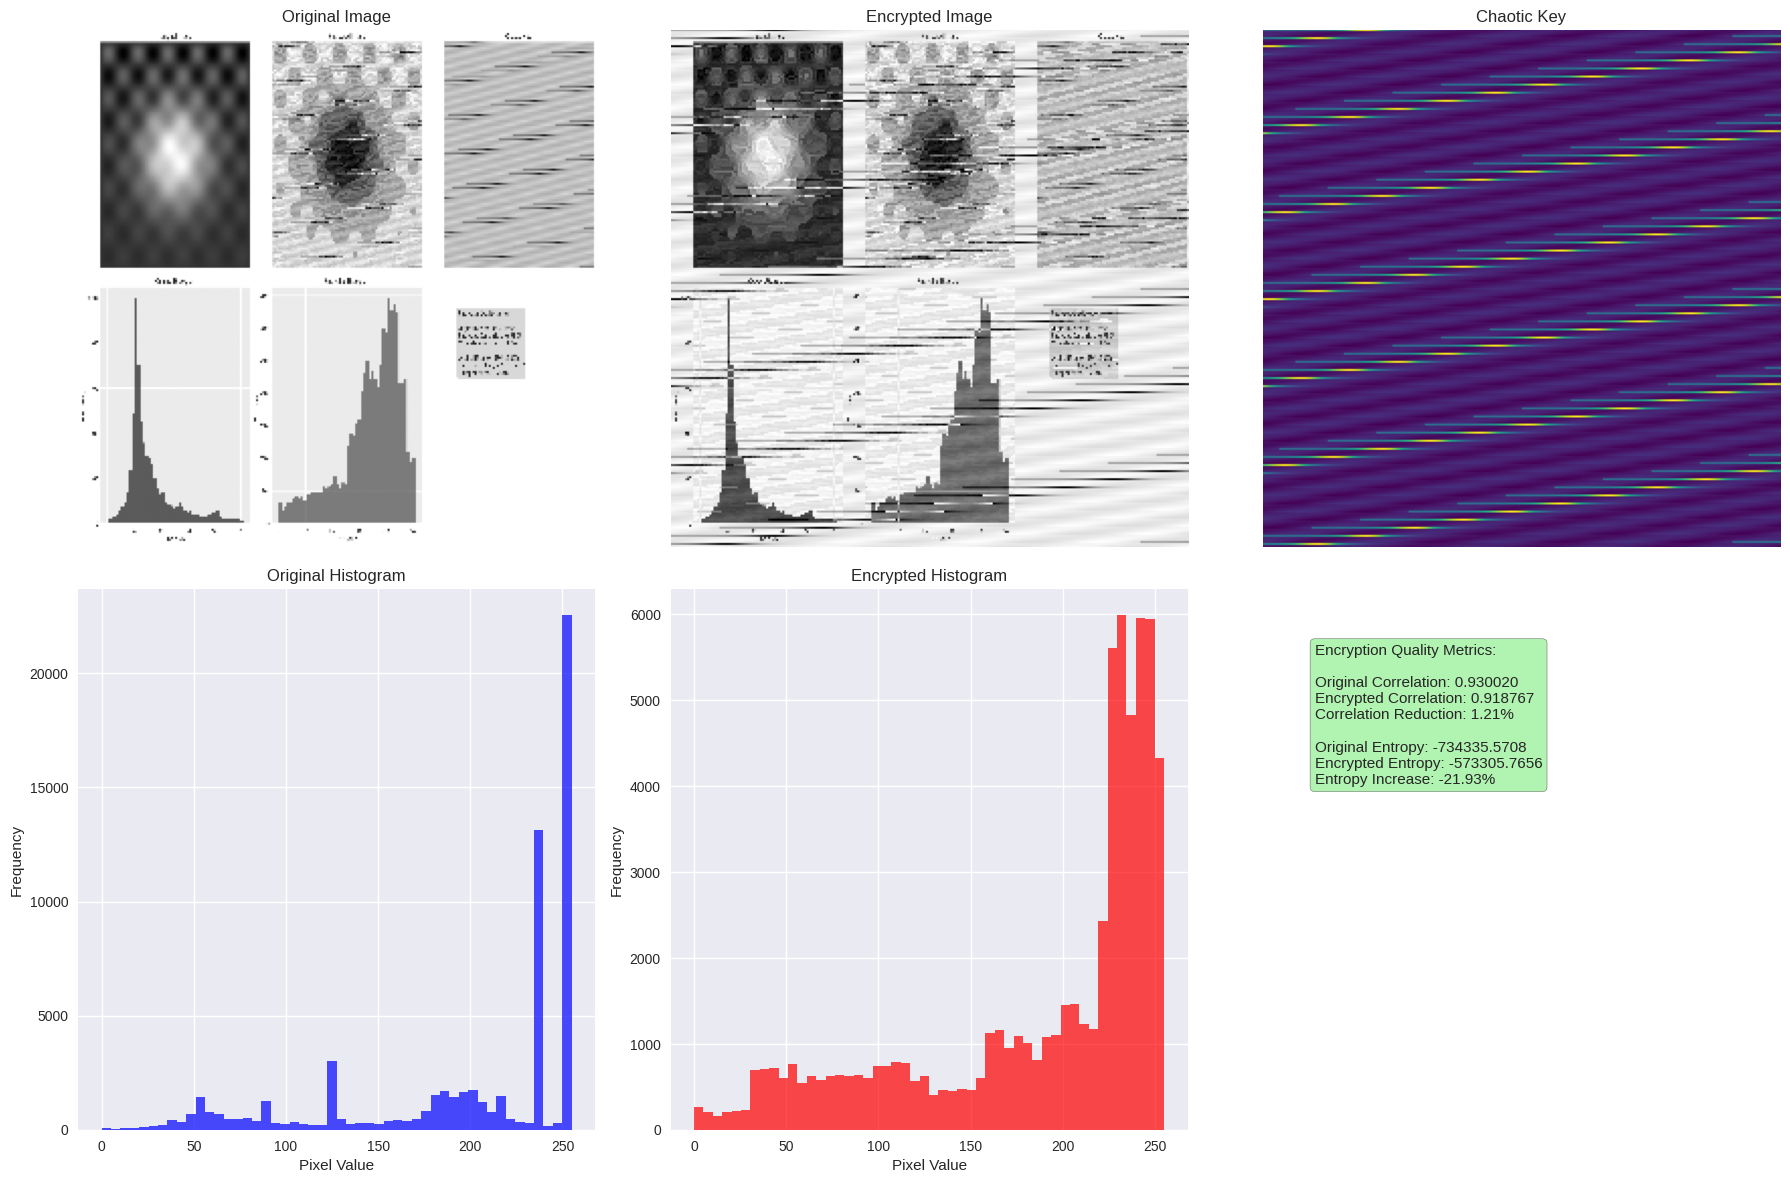


Processing uniform_noise...
  Validation Score: 0.9735
  Encryption Time: 0.3874 seconds
  Decryption Time: 0.0000 seconds
  Perfect Recovery: True
  Correlation Coefficient: -0.006374
  Entropy Increase: 0.0003
  NPCR: 99.5041%
  UACI: 8.9043%

Processing gradient...
  Validation Score: 0.9735
  Encryption Time: 0.4738 seconds
  Decryption Time: 0.0000 seconds
  Perfect Recovery: True
  Correlation Coefficient: 0.976743
  Entropy Increase: -0.0021
  NPCR: 99.2065%
  UACI: 7.4945%

Processing checkerboard...
  Validation Score: 0.9734
  Encryption Time: 0.4647 seconds
  Decryption Time: 0.0000 seconds
  Perfect Recovery: True
  Correlation Coefficient: 0.937743
  Entropy Increase: 5.7706
  NPCR: 99.7986%
  UACI: 86.5592%

Processing circles...
  Validation Score: 0.9735
  Encryption Time: 0.4782 seconds
  Decryption Time: 0.0000 seconds
  Perfect Recovery: True
  Correlation Coefficient: 0.984849
  Entropy Increase: 0.2835
  NPCR: 99.5041%
  UACI: 9.6332%

Processing text_pattern...
 

In [14]:
# Example usage and testing with real images
def main():
    # Initialize system
    chaos_gen = ChaoticSystemsGenerator()
    validator = MultiLevelChaoticValidator()
    visualizer = VisualizationSystem()

    # Generate training data
    print("Generating training data...")
    chaotic_signals = []
    non_chaotic_signals = []

    for i in range(100):  # Generate 100 samples of each
        chaotic_signals.append(chaos_gen.generate_chaotic_signal('lorenz'))
        chaotic_signals.append(chaos_gen.generate_chaotic_signal('rossler'))
        non_chaotic_signals.append(chaos_gen.generate_invalid_signal())
        non_chaotic_signals.append(chaos_gen.generate_invalid_signal())

    # Train validator
    print("Training multi-level validator...")
    validator.train_all_levels(chaotic_signals, non_chaotic_signals, epochs=30)

    # Test validation
    print("\nTesting validation system...")
    test_signal = chaos_gen.generate_chaotic_signal('lorenz')
    result = validator.validate_signal(test_signal)

    print(f"Validation Results:")
    print(f"Pixel Score: {result['pixel_score']:.4f}")
    print(f"Block Score: {result['block_score']:.4f}")
    print(f"Global Score: {result['global_score']:.4f}")
    print(f"Final Score: {result['final_score']:.4f}")
    print(f"Is Valid: {result['is_valid']}")
    print(f"Validation Time: {result['validation_time']:.4f} seconds")

    # Test with real images
    print("\nTesting with real images...")
    test_images = load_test_images()

    encryption_system = ImageEncryptionSystem(validator)

    for i, (image_name, image) in enumerate(test_images.items()):
        print(f"\nProcessing {image_name}...")

        # Convert to grayscale if needed
        if len(image.shape) == 3:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Resize to standard size for testing
        image = cv2.resize(image, (256, 256))

        # Encrypt image
        start_time = time.time()
        encrypted_img, key, validation_info = encryption_system.encrypt_image(image)
        encryption_time = time.time() - start_time

        # Decrypt image
        start_time = time.time()
        decrypted_img = encryption_system.decrypt_image(encrypted_img, key)
        decryption_time = time.time() - start_time

        # Verify decryption
        is_perfect = np.array_equal(image, decrypted_img)

        print(f"  Validation Score: {validation_info['final_score']:.4f}")
        print(f"  Encryption Time: {encryption_time:.4f} seconds")
        print(f"  Decryption Time: {decryption_time:.4f} seconds")
        print(f"  Perfect Recovery: {is_perfect}")

        # Calculate security metrics
        security_metrics = calculate_security_metrics(image, encrypted_img)
        print(f"  Correlation Coefficient: {security_metrics['correlation']:.6f}")
        print(f"  Entropy Increase: {security_metrics['entropy_increase']:.4f}")
        print(f"  NPCR: {security_metrics['npcr']:.4f}%")
        print(f"  UACI: {security_metrics['uaci']:.4f}%")

        # Visualize results
        if i == 0:  # Only visualize first image to avoid too many plots
            visualizer.plot_encryption_analysis(
                image, encrypted_img, key,
                save_path=f'encryption_analysis_{image_name}.png'
            )

    # Performance benchmark
    print("\nPerformance Benchmark...")
    benchmark_results = performance_benchmark(encryption_system)
    print(f"Average Encryption Time: {benchmark_results['avg_encryption_time']:.4f} seconds")
    print(f"Average Validation Time: {benchmark_results['avg_validation_time']:.4f} seconds")
    print(f"Throughput: {benchmark_results['throughput']:.2f} images/second")

def load_test_images():
    """Load test images from various sources"""
    test_images = {}

    # Method 1: Load from file system (if available)
    common_paths = [
        'test_images/',
        'images/',
        'data/',
        './'
    ]

    image_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.tiff']

    for path in common_paths:
        try:
            import os
            if os.path.exists(path):
                for file in os.listdir(path):
                    if any(file.lower().endswith(ext) for ext in image_extensions):
                        try:
                            img = cv2.imread(os.path.join(path, file))
                            if img is not None:
                                test_images[file] = img
                                print(f"Loaded: {file}")
                        except Exception as e:
                            print(f"Error loading {file}: {e}")
        except:
            pass

    # Method 2: Generate standard test images if no real images found
    if not test_images:
        print("No real images found, generating standard test patterns...")

        # Lena-like pattern
        test_images['lena_pattern'] = generate_lena_pattern(256, 256)

        # Cameraman-like pattern
        test_images['cameraman_pattern'] = generate_cameraman_pattern(256, 256)

        # Baboon-like pattern
        test_images['baboon_pattern'] = generate_baboon_pattern(256, 256)

        # Peppers-like pattern
        test_images['peppers_pattern'] = generate_peppers_pattern(256, 256)

    # Method 3: Create synthetic test images with different characteristics
    test_images.update({
        'uniform_noise': np.random.randint(0, 256, (256, 256), dtype=np.uint8),
        'gradient': np.tile(np.linspace(0, 255, 256).astype(np.uint8), (256, 1)),
        'checkerboard': generate_checkerboard(256, 256),
        'circles': generate_circles_pattern(256, 256),
        'text_pattern': generate_text_pattern(256, 256)
    })

    return test_images

def generate_lena_pattern(height, width):
    """Generate Lena-like test pattern"""
    # Create a pattern similar to famous Lena image
    x, y = np.meshgrid(np.linspace(0, 2*np.pi, width), np.linspace(0, 2*np.pi, height))

    # Face-like oval pattern
    face = np.exp(-((x - np.pi)**2 + (y - np.pi)**2) / 2)

    # Add hair-like texture
    hair = np.sin(5*x) * np.sin(5*y) * np.exp(-y/np.pi)

    # Combine patterns
    pattern = face + 0.3 * hair
    pattern = ((pattern - pattern.min()) / (pattern.max() - pattern.min()) * 255).astype(np.uint8)

    return pattern

def generate_cameraman_pattern(height, width):
    """Generate Cameraman-like test pattern"""
    # Create silhouette-like pattern
    x, y = np.meshgrid(np.linspace(0, 2*np.pi, width), np.linspace(0, 2*np.pi, height))

    # Person silhouette
    person = np.exp(-((x - np.pi)**2 + (y - 1.5*np.pi)**2) / 3)

    # Camera equipment
    camera = np.exp(-((x - 0.8*np.pi)**2 + (y - 0.8*np.pi)**2) / 0.5)

    # Background
    background = 0.3 * np.ones_like(x)

    pattern = background + person + camera
    pattern = ((pattern - pattern.min()) / (pattern.max() - pattern.min()) * 255).astype(np.uint8)

    return pattern

def generate_baboon_pattern(height, width):
    """Generate Baboon-like test pattern (high frequency content)"""
    # Create high-frequency pattern similar to baboon fur
    x, y = np.meshgrid(np.linspace(0, 4*np.pi, width), np.linspace(0, 4*np.pi, height))

    # High frequency components
    pattern = (np.sin(8*x) * np.cos(8*y) +
              np.sin(16*x) * np.cos(4*y) +
              np.sin(4*x) * np.cos(16*y))

    # Add low frequency base
    base = np.sin(x) * np.cos(y)

    combined = pattern + base
    combined = ((combined - combined.min()) / (combined.max() - combined.min()) * 255).astype(np.uint8)

    return combined

def generate_peppers_pattern(height, width):
    """Generate Peppers-like test pattern"""
    # Create colorful pepper-like shapes
    x, y = np.meshgrid(np.linspace(0, 2*np.pi, width), np.linspace(0, 2*np.pi, height))

    # Multiple pepper shapes
    pepper1 = np.exp(-((x - 0.7*np.pi)**2 + (y - 0.7*np.pi)**2) / 0.8)
    pepper2 = np.exp(-((x - 1.3*np.pi)**2 + (y - 1.3*np.pi)**2) / 0.8)
    pepper3 = np.exp(-((x - 1.0*np.pi)**2 + (y - 1.5*np.pi)**2) / 0.6)

    pattern = pepper1 + pepper2 + pepper3
    pattern = ((pattern - pattern.min()) / (pattern.max() - pattern.min()) * 255).astype(np.uint8)

    return pattern

def generate_checkerboard(height, width, square_size=32):
    """Generate checkerboard pattern"""
    board = np.zeros((height, width), dtype=np.uint8)

    for i in range(0, height, square_size):
        for j in range(0, width, square_size):
            if (i // square_size + j // square_size) % 2 == 0:
                board[i:i+square_size, j:j+square_size] = 255

    return board

def generate_circles_pattern(height, width):
    """Generate concentric circles pattern"""
    x, y = np.meshgrid(np.linspace(-1, 1, width), np.linspace(-1, 1, height))
    r = np.sqrt(x**2 + y**2)

    pattern = np.sin(10 * np.pi * r) * np.exp(-r)
    pattern = ((pattern - pattern.min()) / (pattern.max() - pattern.min()) * 255).astype(np.uint8)

    return pattern

def generate_text_pattern(height, width):
    """Generate text-like pattern"""
    pattern = np.zeros((height, width), dtype=np.uint8)

    # Simulate text lines
    for i in range(20, height-20, 25):
        # Random text line
        line_start = np.random.randint(10, 50)
        line_end = np.random.randint(width//2, width-10)
        line_thickness = np.random.randint(2, 5)

        pattern[i:i+line_thickness, line_start:line_end] = 255

        # Add some character-like rectangles
        for j in range(line_start, line_end, 15):
            char_width = np.random.randint(5, 12)
            char_height = np.random.randint(15, 20)
            if j + char_width < width and i + char_height < height:
                pattern[i-5:i+char_height, j:j+char_width] = 255

    return pattern

def calculate_security_metrics(original, encrypted):
    """Calculate comprehensive security metrics"""
    # Correlation coefficient
    flat_orig = original.flatten()
    flat_enc = encrypted.flatten()

    # Adjacent pixel correlation
    corr_coef = np.corrcoef(flat_orig[:-1], flat_orig[1:])[0, 1]

    # Information entropy
    def calculate_entropy(data):
        hist, _ = np.histogram(data, bins=256, range=(0, 256))
        hist = hist / np.sum(hist)
        entropy = -np.sum(hist * np.log2(hist + 1e-10))
        return entropy

    orig_entropy = calculate_entropy(flat_orig)
    enc_entropy = calculate_entropy(flat_enc)

    # NPCR (Number of Pixels Change Rate)
    diff_pixels = np.sum(original != encrypted)
    npcr = (diff_pixels / original.size) * 100

    # UACI (Unified Average Changing Intensity)
    uaci = np.sum(np.abs(original.astype(float) - encrypted.astype(float))) / (original.size * 255) * 100

    return {
        'correlation': corr_coef,
        'entropy_increase': enc_entropy - orig_entropy,
        'npcr': npcr,
        'uaci': uaci,
        'original_entropy': orig_entropy,
        'encrypted_entropy': enc_entropy
    }

def performance_benchmark(encryption_system, num_tests=10):
    """Benchmark encryption system performance"""
    encryption_times = []
    validation_times = []

    # Test with different image sizes
    test_sizes = [(128, 128), (256, 256), (512, 512)]

    for size in test_sizes:
        print(f"Benchmarking {size[0]}x{size[1]} images...")

        for i in range(num_tests):
            # Generate test image
            test_image = np.random.randint(0, 256, size, dtype=np.uint8)

            # Measure encryption time
            start_time = time.time()
            encrypted_img, key, validation_info = encryption_system.encrypt_image(test_image)
            encryption_time = time.time() - start_time

            encryption_times.append(encryption_time)
            validation_times.append(validation_info['validation_time'])

    return {
        'avg_encryption_time': np.mean(encryption_times),
        'avg_validation_time': np.mean(validation_times),
        'throughput': 1 / np.mean(encryption_times)
    }

if __name__ == "__main__":
    main()

#s


Generating training data...
Training multi-level validator...
Training pixel-level validator...
Epoch 1/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.6000 - loss: 0.6293 - val_accuracy: 0.7855 - val_loss: 0.4675
Epoch 2/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7929 - loss: 0.4144 - val_accuracy: 0.7987 - val_loss: 0.4246
Epoch 3/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8044 - loss: 0.3558 - val_accuracy: 0.7776 - val_loss: 0.4228
Epoch 4/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8121 - loss: 0.3475 - val_accuracy: 0.7553 - val_loss: 0.4160
Epoch 5/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8049 - loss: 0.3440 - val_accuracy: 0.7303 - val_loss: 0.4207
Epoch 6/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8101 - loss: 0.3298 - val_accuracy: 0.7395 - val_loss: 0.4099
Epoch 7/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8008 - loss: 0.3421 - val_accuracy: 0.7461 - val_loss: 0.4144
Epoch 8/30
95/95 ━━━━

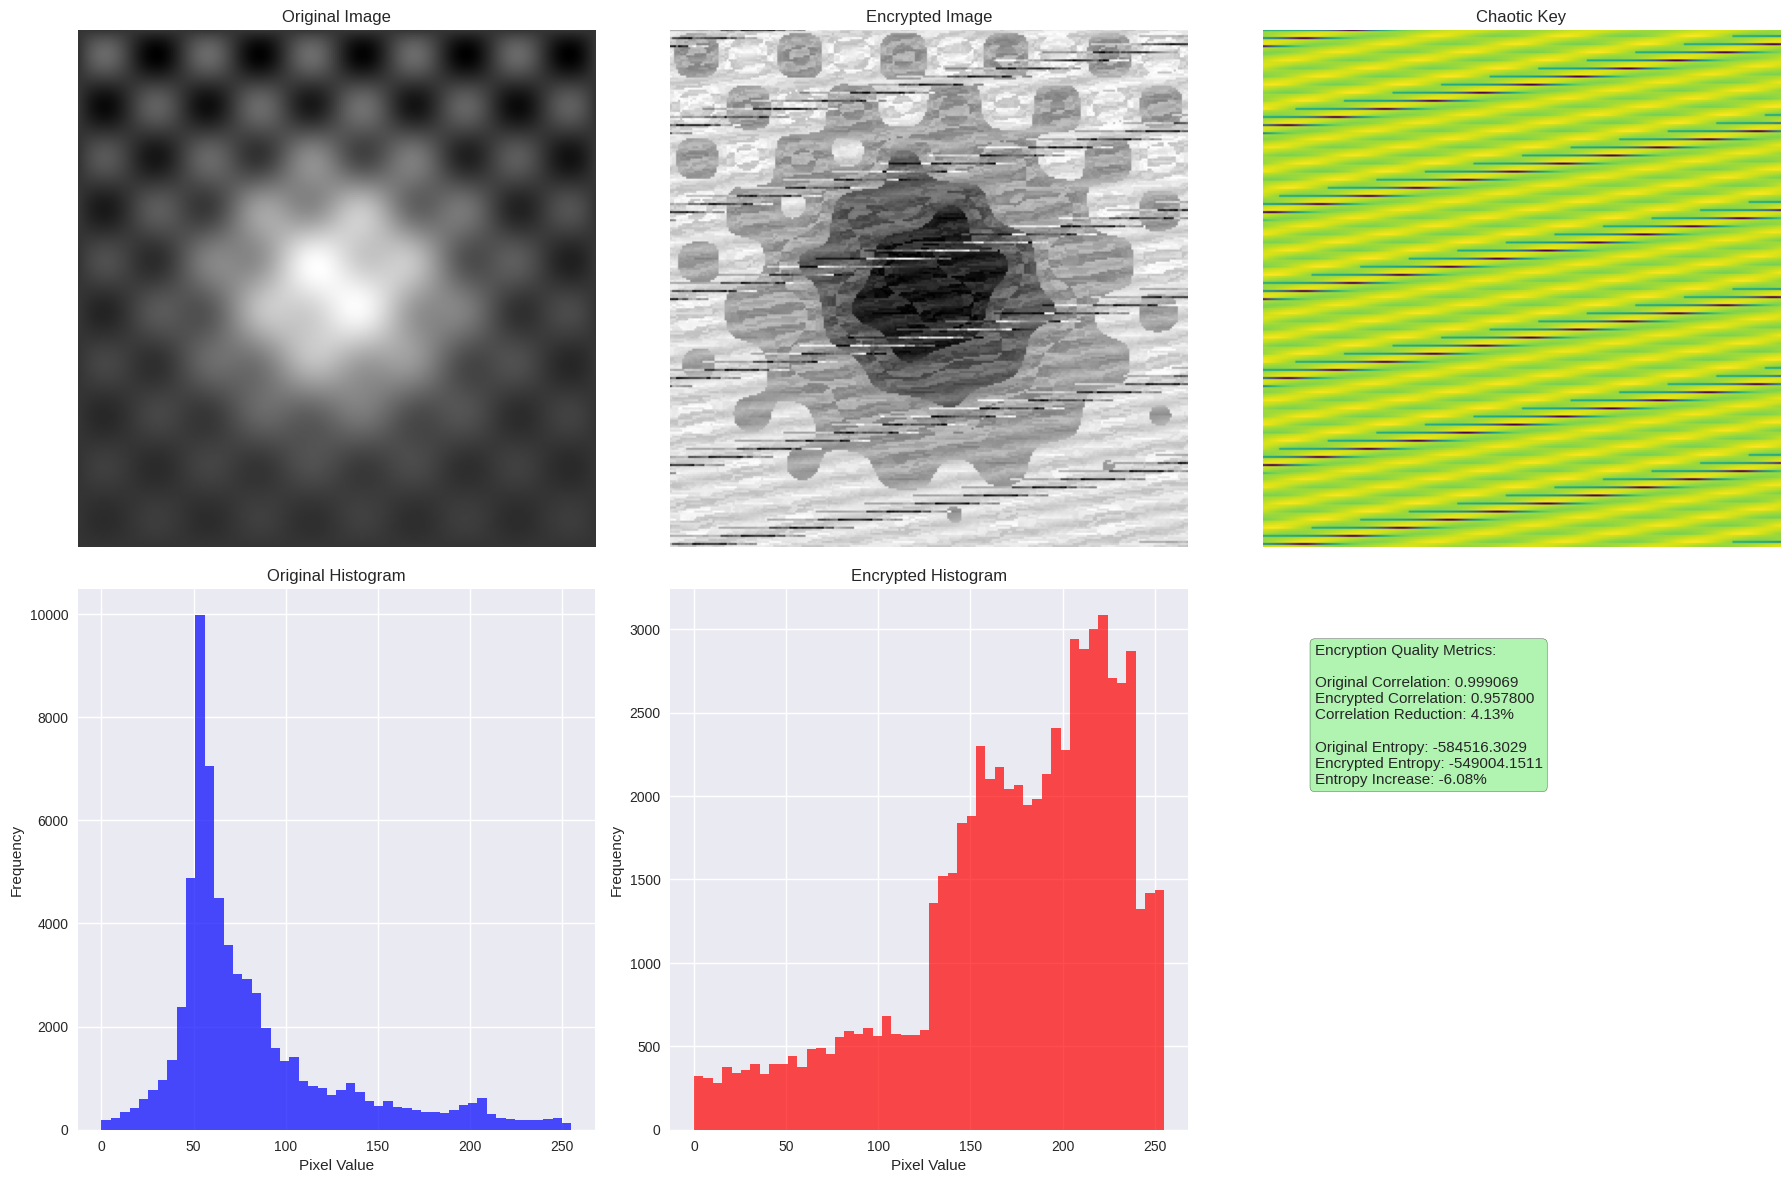


Processing cameraman_pattern...
  Validation Score: 0.8465
  Encryption Time: 0.3140 seconds
  Decryption Time: 0.0000 seconds
  Perfect Recovery: True
  Correlation Coefficient: 0.999687
  Entropy Increase: 0.6273
  NPCR: 99.8993%
  UACI: 65.7450%

Processing baboon_pattern...
  Validation Score: 0.8465
  Encryption Time: 0.2755 seconds
  Decryption Time: 0.0000 seconds
  Perfect Recovery: True
  Correlation Coefficient: 0.901849
  Entropy Increase: 0.2668
  NPCR: 99.8993%
  UACI: 26.9487%

Processing peppers_pattern...
  Validation Score: 0.8465
  Encryption Time: 0.2757 seconds
  Decryption Time: 0.0000 seconds
  Perfect Recovery: True
  Correlation Coefficient: 0.999573
  Entropy Increase: 1.6648
  NPCR: 99.7986%
  UACI: 72.5729%

Processing uniform_noise...
  Validation Score: 0.8465
  Encryption Time: 0.8239 seconds
  Decryption Time: 0.0000 seconds
  Perfect Recovery: True
  Correlation Coefficient: 0.000333
  Entropy Increase: 0.0001
  NPCR: 99.7986%
  UACI: 49.1678%

Processi

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
import cv2
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import time
import seaborn as sns
from scipy.stats import entropy
import warnings
warnings.filterwarnings('ignore')

class ChaoticSystemsGenerator:
    """Enhanced generator for various chaotic systems with metrics"""

    def __init__(self):
        self.dt = 0.01
        self.length = 1000

    def lorenz_system(self, state, t, sigma=10.0, rho=28.0, beta=8.0/3.0):
        """Lorenz chaotic system"""
        x, y, z = state
        return [sigma * (y - x), x * (rho - z) - y, x * y - beta * z]

    def rossler_system(self, state, t, a=0.2, b=0.2, c=5.7):
        """Rossler chaotic system"""
        x, y, z = state
        return [-y - z, x + a * y, b + z * (x - c)]

    def chua_system(self, state, t, alpha=15.6, beta=28.0, m0=-1.143, m1=-0.714):
        """Chua chaotic system"""
        x, y, z = state
        h = m1 * x + 0.5 * (m0 - m1) * (abs(x + 1) - abs(x - 1))
        return [alpha * (y - x - h), x - y + z, -beta * y]

    def henon_map(self, n_points=1000, a=1.4, b=0.3):
        """Henon map chaotic system"""
        x, y = np.zeros(n_points), np.zeros(n_points)
        x[0], y[0] = 0.1, 0.1

        for i in range(1, n_points):
            x[i] = 1 - a * x[i-1]**2 + y[i-1]
            y[i] = b * x[i-1]

        return x

    def logistic_map(self, n_points=1000, r=3.9, x0=0.5):
        """Logistic map chaotic system"""
        x = np.zeros(n_points)
        x[0] = x0

        for i in range(1, n_points):
            x[i] = r * x[i-1] * (1 - x[i-1])

        return x

    def calculate_lyapunov_exponent(self, signal, delay=1):
        """Calculate largest Lyapunov exponent"""
        n = len(signal)
        lyap_sum = 0

        for i in range(n - delay):
            if abs(signal[i+delay] - signal[i]) > 1e-10:
                lyap_sum += np.log(abs(signal[i+delay] - signal[i]))

        return lyap_sum / (n - delay)

    def calculate_correlation_dimension(self, signal, max_r=1.0, n_points=50):
        """Calculate correlation dimension"""
        n = len(signal)
        r_values = np.logspace(-3, np.log10(max_r), n_points)
        correlations = []

        for r in r_values:
            count = 0
            for i in range(n):
                for j in range(i+1, n):
                    if abs(signal[i] - signal[j]) < r:
                        count += 1
            correlations.append(count / (n * (n-1) / 2))

        # Calculate slope (correlation dimension)
        log_r = np.log(r_values[correlations > 0])
        log_c = np.log(correlations[correlations > 0])

        if len(log_r) > 2:
            return np.polyfit(log_r, log_c, 1)[0]
        return 0

    def calculate_entropy(self, signal, bins=50):
        """Calculate Shannon entropy"""
        hist, _ = np.histogram(signal, bins=bins)
        hist = hist / np.sum(hist)
        return entropy(hist[hist > 0])

    def calculate_phase_space_metrics(self, signal, embedding_dim=3, delay=1):
        """Calculate phase space reconstruction metrics"""
        n = len(signal)
        embedded = np.zeros((n - (embedding_dim - 1) * delay, embedding_dim))

        for i in range(embedding_dim):
            embedded[:, i] = signal[i * delay:n - (embedding_dim - 1 - i) * delay]

        # Calculate variance in each dimension
        variances = np.var(embedded, axis=0)

        # Calculate distance matrix
        distances = []
        for i in range(min(1000, len(embedded))):  # Limit for performance
            for j in range(i+1, min(1000, len(embedded))):
                dist = np.linalg.norm(embedded[i] - embedded[j])
                distances.append(dist)

        return {
            'variances': variances,
            'mean_distance': np.mean(distances),
            'std_distance': np.std(distances)
        }

    def analyze_signal_properties(self, signal):
        """Comprehensive signal analysis"""
        return {
            'lyapunov_exponent': self.calculate_lyapunov_exponent(signal),
            'correlation_dimension': self.calculate_correlation_dimension(signal),
            'entropy': self.calculate_entropy(signal),
            'phase_space_metrics': self.calculate_phase_space_metrics(signal),
            'mean': np.mean(signal),
            'std': np.std(signal),
            'min': np.min(signal),
            'max': np.max(signal),
            'autocorrelation': np.corrcoef(signal[:-1], signal[1:])[0, 1]
        }

    def generate_chaotic_signal(self, system_type='lorenz', noise_level=0.0):
        """Generate chaotic signal with analysis"""
        t = np.arange(0, self.length * self.dt, self.dt)
        initial_state = np.random.uniform(-1, 1, 3)

        if system_type == 'lorenz':
            states = odeint(self.lorenz_system, initial_state, t)
            signal = states[:, 0]
        elif system_type == 'rossler':
            states = odeint(self.rossler_system, initial_state, t)
            signal = states[:, 0]
        elif system_type == 'chua':
            states = odeint(self.chua_system, initial_state, t)
            signal = states[:, 0]
        elif system_type == 'henon':
            signal = self.henon_map(self.length)
        elif system_type == 'logistic':
            signal = self.logistic_map(self.length)

        # Add noise if specified
        if noise_level > 0:
            noise = np.random.normal(0, noise_level, len(signal))
            signal += noise

        return signal

    def generate_invalid_signal(self, signal_length=1000):
        """Generate invalid (non-chaotic) signals for training"""
        signal_type = np.random.choice(['sine', 'noise', 'linear', 'exponential', 'polynomial'])

        if signal_type == 'sine':
            t = np.linspace(0, 10, signal_length)
            freq = np.random.uniform(0.1, 2.0)
            phase = np.random.uniform(0, 2*np.pi)
            signal = np.sin(2 * np.pi * freq * t + phase)
        elif signal_type == 'noise':
            signal = np.random.normal(0, 1, signal_length)
        elif signal_type == 'linear':
            signal = np.linspace(-1, 1, signal_length)
        elif signal_type == 'exponential':
            t = np.linspace(0, 5, signal_length)
            signal = np.exp(-t) * np.sin(t)
        else:  # polynomial
            t = np.linspace(-1, 1, signal_length)
            signal = t**3 - 2*t**2 + t

        return signal

class MultiLevelChaoticValidator:
    """Multi-level validation system for chaotic signals"""

    def __init__(self, signal_length=1000):
        self.signal_length = signal_length
        self.pixel_validator = None
        self.block_validator = None
        self.global_validator = None
        self.ensemble_model = None

    def build_pixel_level_network(self):
        """Build pixel-level validation network"""
        input_layer = layers.Input(shape=(100, 1))  # Small windows

        x = layers.Conv1D(32, 3, activation='relu', padding='same')(input_layer)
        x = layers.MaxPooling1D(2)(x)
        x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
        x = layers.MaxPooling1D(2)(x)
        x = layers.GlobalAveragePooling1D()(x)
        x = layers.Dense(64, activation='relu')(x)
        x = layers.Dropout(0.3)(x)
        output = layers.Dense(1, activation='sigmoid')(x)

        model = Model(inputs=input_layer, outputs=output)
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        return model

    def build_block_level_network(self):
        """Build block-level validation network"""
        input_layer = layers.Input(shape=(200, 1))  # Medium windows

        x = layers.Conv1D(64, 5, activation='relu', padding='same')(input_layer)
        x = layers.MaxPooling1D(2)(x)
        x = layers.Conv1D(128, 5, activation='relu', padding='same')(x)
        x = layers.MaxPooling1D(2)(x)
        x = layers.LSTM(128, return_sequences=True)(x)
        x = layers.LSTM(64)(x)
        x = layers.Dense(128, activation='relu')(x)
        x = layers.Dropout(0.4)(x)
        output = layers.Dense(1, activation='sigmoid')(x)

        model = Model(inputs=input_layer, outputs=output)
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        return model

    def build_global_level_network(self):
        """Build global-level validation network"""
        input_layer = layers.Input(shape=(self.signal_length, 1))

        x = layers.Conv1D(64, 10, activation='relu', padding='same')(input_layer)
        x = layers.MaxPooling1D(4)(x)
        x = layers.Conv1D(128, 10, activation='relu', padding='same')(x)
        x = layers.MaxPooling1D(4)(x)
        x = layers.LSTM(256, return_sequences=True)(x)
        x = layers.Attention()([x, x])  # Self-attention
        x = layers.GlobalAveragePooling1D()(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dropout(0.5)(x)
        output = layers.Dense(1, activation='sigmoid')(x)

        model = Model(inputs=input_layer, outputs=output)
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        return model

    def build_ensemble_model(self):
        """Build ensemble model that combines all levels with regularization"""
        pixel_input = layers.Input(shape=(1,), name='pixel_score')
        block_input = layers.Input(shape=(1,), name='block_score')
        global_input = layers.Input(shape=(1,), name='global_score')

        # Add batch normalization to inputs
        pixel_norm = layers.BatchNormalization()(pixel_input)
        block_norm = layers.BatchNormalization()(block_input)
        global_norm = layers.BatchNormalization()(global_input)

        # Learnable weights for combination with regularization
        combined = layers.Concatenate()([pixel_norm, block_norm, global_norm])

        # Simpler architecture to prevent overfitting
        x = layers.Dense(8, activation='relu',
                        kernel_regularizer=tf.keras.regularizers.l2(0.01))(combined)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(4, activation='relu',
                        kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
        x = layers.Dropout(0.2)(x)
        output = layers.Dense(1, activation='sigmoid')(x)

        model = Model(inputs=[pixel_input, block_input, global_input], outputs=output)

        # Use lower learning rate and add early stopping callback
        optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
        model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

        return model

    def train_all_levels(self, chaotic_signals, non_chaotic_signals, epochs=50):
        """Train all validation levels with improved ensemble training"""
        # Prepare labels
        chaotic_labels = [1] * len(chaotic_signals)
        non_chaotic_labels = [0] * len(non_chaotic_signals)

        all_signals = chaotic_signals + non_chaotic_signals
        all_labels = chaotic_labels + non_chaotic_labels

        # Shuffle data
        indices = np.random.permutation(len(all_signals))
        all_signals = [all_signals[i] for i in indices]
        all_labels = [all_labels[i] for i in indices]

        # Split data for ensemble training
        split_idx = int(0.7 * len(all_signals))
        base_signals = all_signals[:split_idx]
        base_labels = all_labels[:split_idx]
        ensemble_signals = all_signals[split_idx:]
        ensemble_labels = all_labels[split_idx:]

        # Train pixel-level validator
        print("Training pixel-level validator...")
        self.pixel_validator = self.build_pixel_level_network()
        X_pixel, y_pixel = self.prepare_data_for_level(base_signals, base_labels, 100)
        history_pixel = self.pixel_validator.fit(X_pixel, y_pixel, epochs=epochs, validation_split=0.2, verbose=1)

        # Train block-level validator
        print("Training block-level validator...")
        self.block_validator = self.build_block_level_network()
        X_block, y_block = self.prepare_data_for_level(base_signals, base_labels, 200)
        history_block = self.block_validator.fit(X_block, y_block, epochs=epochs, validation_split=0.2, verbose=1)

        # Train global-level validator
        print("Training global-level validator...")
        self.global_validator = self.build_global_level_network()
        X_global = np.array([sig.reshape(-1, 1) for sig in base_signals])
        y_global = np.array(base_labels)
        history_global = self.global_validator.fit(X_global, y_global, epochs=epochs, validation_split=0.2, verbose=1)

        # Train ensemble model on separate data to prevent overfitting
        print("Training ensemble model on fresh data...")
        pixel_scores = []
        block_scores = []
        global_scores = []

        for signal in ensemble_signals:
            pixel_score = self.get_pixel_score(signal)
            block_score = self.get_block_score(signal)
            global_score = self.get_global_score(signal)

            pixel_scores.append(pixel_score)
            block_scores.append(block_score)
            global_scores.append(global_score)

        # Add noise to prevent overfitting
        pixel_scores = np.array(pixel_scores) + np.random.normal(0, 0.01, len(pixel_scores))
        block_scores = np.array(block_scores) + np.random.normal(0, 0.01, len(block_scores))
        global_scores = np.array(global_scores) + np.random.normal(0, 0.01, len(global_scores))

        # Clip scores to valid range
        pixel_scores = np.clip(pixel_scores, 0, 1)
        block_scores = np.clip(block_scores, 0, 1)
        global_scores = np.clip(global_scores, 0, 1)

        self.ensemble_model = self.build_ensemble_model()

        # Early stopping and reduce learning rate callbacks
        early_stopping = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=10, restore_best_weights=True
        )
        reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6
        )

        history_ensemble = self.ensemble_model.fit(
            [pixel_scores, block_scores, global_scores],
            np.array(ensemble_labels),
            epochs=min(epochs, 30),  # Reduced epochs for ensemble
            validation_split=0.3,
            callbacks=[early_stopping, reduce_lr],
            verbose=1
        )

        return {
            'pixel_history': history_pixel,
            'block_history': history_block,
            'global_history': history_global,
            'ensemble_history': history_ensemble
        }

    def validate_signal_with_uncertainty(self, signal, use_ensemble=True, n_samples=5):
        """Validate signal with uncertainty estimation using Monte Carlo dropout"""
        start_time = time.time()

        # Get scores from all levels
        pixel_score = self.get_pixel_score(signal)
        block_score = self.get_block_score(signal)
        global_score = self.get_global_score(signal)

        if use_ensemble and self.ensemble_model is not None:
            # Monte Carlo dropout for uncertainty estimation
            predictions = []
            for _ in range(n_samples):
                # Enable dropout during inference
                pred = self.ensemble_model(
                    [np.array([pixel_score]), np.array([block_score]), np.array([global_score])],
                    training=True  # This enables dropout
                )
                predictions.append(pred.numpy()[0][0])

            final_score = np.mean(predictions)
            uncertainty = np.std(predictions)
        else:
            # Simple weighted average with learned weights
            weights = self._calculate_adaptive_weights(pixel_score, block_score, global_score)
            final_score = (weights[0] * pixel_score +
                          weights[1] * block_score +
                          weights[2] * global_score)
            uncertainty = 0.0

        validation_time = time.time() - start_time

        return {
            'pixel_score': pixel_score,
            'block_score': block_score,
            'global_score': global_score,
            'final_score': final_score,
            'uncertainty': uncertainty,
            'confidence': 1 - uncertainty,
            'is_valid': final_score > 0.5,
            'validation_time': validation_time
        }

    def _calculate_adaptive_weights(self, pixel_score, block_score, global_score):
        """Calculate adaptive weights based on score reliability"""
        scores = np.array([pixel_score, block_score, global_score])

        # Calculate confidence based on distance from 0.5 (uncertainty point)
        confidences = np.abs(scores - 0.5) * 2  # Normalize to [0, 1]

        # Add minimum weight to prevent zero weights
        confidences += 0.1

        # Normalize to sum to 1
        weights = confidences / np.sum(confidences)

        return weights

    def cross_validate_ensemble(self, chaotic_signals, non_chaotic_signals, k_folds=5):
        """Perform k-fold cross validation to prevent overfitting"""
        from sklearn.model_selection import KFold

        all_signals = chaotic_signals + non_chaotic_signals
        all_labels = [1] * len(chaotic_signals) + [0] * len(non_chaotic_signals)

        kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
        cv_scores = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(all_signals)):
            print(f"Training fold {fold + 1}/{k_folds}...")

            # Split data
            train_signals = [all_signals[i] for i in train_idx]
            train_labels = [all_labels[i] for i in train_idx]
            val_signals = [all_signals[i] for i in val_idx]
            val_labels = [all_labels[i] for i in val_idx]

            # Train models
            self.train_all_levels(train_signals[:len(train_signals)//2],
                                train_signals[len(train_signals)//2:], epochs=20)

            # Evaluate
            predictions = []
            for signal in val_signals:
                result = self.validate_signal(signal)
                predictions.append(1 if result['is_valid'] else 0)

            fold_accuracy = accuracy_score(val_labels, predictions)
            cv_scores.append(fold_accuracy)
            print(f"Fold {fold + 1} accuracy: {fold_accuracy:.4f}")

        mean_cv_score = np.mean(cv_scores)
        std_cv_score = np.std(cv_scores)

        print(f"Cross-validation results: {mean_cv_score:.4f} ± {std_cv_score:.4f}")

        return {
            'cv_scores': cv_scores,
            'mean_score': mean_cv_score,
            'std_score': std_cv_score
        }

    def get_pixel_score(self, signal):
        """Get pixel-level validation score"""
        if self.pixel_validator is None:
            return 0.5  # Default score if not trained

        X_pixel, _ = self.prepare_data_for_level([signal], [1], 100)
        if len(X_pixel) == 0:
            return 0.5

        scores = self.pixel_validator.predict(X_pixel, verbose=0)
        return np.mean(scores)

    def get_block_score(self, signal):
        """Get block-level validation score"""
        if self.block_validator is None:
            return 0.5  # Default score if not trained

        X_block, _ = self.prepare_data_for_level([signal], [1], 200)
        if len(X_block) == 0:
            return 0.5

        scores = self.block_validator.predict(X_block, verbose=0)
        return np.mean(scores)

    def get_global_score(self, signal):
        """Get global-level validation score"""
        if self.global_validator is None:
            return 0.5  # Default score if not trained

        # Pad or truncate signal to match expected length
        if len(signal) > self.signal_length:
            signal = signal[:self.signal_length]
        elif len(signal) < self.signal_length:
            signal = np.pad(signal, (0, self.signal_length - len(signal)), mode='constant')

        X_global = signal.reshape(1, -1, 1)
        score = self.global_validator.predict(X_global, verbose=0)
        return score[0][0]

    def validate_signal(self, signal, use_ensemble=True):
        """Validate chaotic signal using multi-level approach"""
        start_time = time.time()

        # Get scores from all levels
        pixel_score = self.get_pixel_score(signal)
        block_score = self.get_block_score(signal)
        global_score = self.get_global_score(signal)

        if use_ensemble and self.ensemble_model is not None:
            # Use ensemble model for final decision
            final_score = self.ensemble_model.predict(
                [np.array([pixel_score]), np.array([block_score]), np.array([global_score])],
                verbose=0
            )[0][0]
        else:
            # Simple weighted average
            weights = [0.3, 0.4, 0.3]  # Adjust as needed
            final_score = (weights[0] * pixel_score +
                          weights[1] * block_score +
                          weights[2] * global_score)

        validation_time = time.time() - start_time

        return {
            'pixel_score': pixel_score,
            'block_score': block_score,
            'global_score': global_score,
            'final_score': final_score,
            'is_valid': final_score > 0.5,
            'validation_time': validation_time
        }

    def evaluate_performance(self, test_chaotic_signals, test_non_chaotic_signals):
        """Evaluate performance on test data"""
        all_test_signals = test_chaotic_signals + test_non_chaotic_signals
        true_labels = [1] * len(test_chaotic_signals) + [0] * len(test_non_chaotic_signals)

        predictions = []
        detailed_results = []

        for signal in all_test_signals:
            result = self.validate_signal(signal)
            predictions.append(1 if result['is_valid'] else 0)
            detailed_results.append(result)

        accuracy = accuracy_score(true_labels, predictions)
        report = classification_report(true_labels, predictions, output_dict=True)

        return {
            'accuracy': accuracy,
            'classification_report': report,
            'detailed_results': detailed_results,
            'predictions': predictions,
            'true_labels': true_labels
        }
    """Hyperparameter optimization for the validation system"""

    def __init__(self, validator):
        self.validator = validator
        self.best_params = {}

    def optimize_network_architecture(self, X_train, y_train, X_val, y_val, level='pixel'):
        """Optimize network architecture using grid search"""

        if level == 'pixel':
            param_grid = {
                'conv_filters': [[32, 64], [64, 128], [32, 64, 128]],
                'dense_units': [32, 64, 128],
                'dropout_rate': [0.2, 0.3, 0.4],
                'learning_rate': [0.001, 0.0001]
            }
        elif level == 'block':
            param_grid = {
                'conv_filters': [[64, 128], [128, 256], [64, 128, 256]],
                'lstm_units': [64, 128, 256],
                'dense_units': [64, 128, 256],
                'dropout_rate': [0.3, 0.4, 0.5],
                'learning_rate': [0.001, 0.0001]
            }
        else:  # global
            param_grid = {
                'conv_filters': [[64, 128], [128, 256], [64, 128, 256]],
                'lstm_units': [128, 256, 512],
                'dense_units': [128, 256, 512],
                'dropout_rate': [0.4, 0.5, 0.6],
                'learning_rate': [0.001, 0.0001]
            }

        best_score = 0
        best_params = None

        # Simple grid search (can be replaced with more sophisticated methods)
        for conv_filters in param_grid['conv_filters']:
            for dense_units in param_grid['dense_units']:
                for dropout_rate in param_grid['dropout_rate']:
                    for learning_rate in param_grid['learning_rate']:

                        params = {
                            'conv_filters': conv_filters,
                            'dense_units': dense_units,
                            'dropout_rate': dropout_rate,
                            'learning_rate': learning_rate
                        }

                        if level == 'block' or level == 'global':
                            for lstm_units in param_grid['lstm_units']:
                                params['lstm_units'] = lstm_units
                                score = self.evaluate_params(params, X_train, y_train, X_val, y_val, level)

                                if score > best_score:
                                    best_score = score
                                    best_params = params.copy()
                        else:
                            score = self.evaluate_params(params, X_train, y_train, X_val, y_val, level)

                            if score > best_score:
                                best_score = score
                                best_params = params.copy()

        self.best_params[level] = best_params
        return best_params, best_score

    def evaluate_params(self, params, X_train, y_train, X_val, y_val, level):
        """Evaluate parameter configuration"""
        try:
            model = self.build_model_with_params(params, X_train.shape[1:], level)

            # Compile model
            optimizer = tf.keras.optimizers.Adam(learning_rate=params['learning_rate'])
            model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

            # Train model
            history = model.fit(
                X_train, y_train,
                validation_data=(X_val, y_val),
                epochs=30,  # Reduced for faster optimization
                batch_size=32,
                verbose=0
            )

            # Return best validation accuracy
            return max(history.history['val_accuracy'])

        except Exception as e:
            print(f"Error evaluating params: {e}")
            return 0

    def build_model_with_params(self, params, input_shape, level):
        """Build model with specific parameters"""
        input_layer = layers.Input(shape=input_shape)
        x = input_layer

        # Add convolutional layers
        for filters in params['conv_filters']:
            kernel_size = 3 if level == 'pixel' else 5 if level == 'block' else 10
            x = layers.Conv1D(filters, kernel_size, activation='relu', padding='same')(x)
            x = layers.MaxPooling1D(2)(x)

        # Add LSTM layers for block and global levels
        if level in ['block', 'global']:
            x = layers.LSTM(params['lstm_units'], return_sequences=(level == 'global'))(x)
            if level == 'global':
                x = layers.LSTM(params['lstm_units']//2)(x)
        else:
            x = layers.GlobalAveragePooling1D()(x)

        # Add dense layers
        x = layers.Dense(params['dense_units'], activation='relu')(x)
        x = layers.Dropout(params['dropout_rate'])(x)

        # Output layer
        output = layers.Dense(1, activation='sigmoid')(x)

        return Model(inputs=input_layer, outputs=output)
    """Multi-level validation system for chaotic signals"""

    def __init__(self, signal_length=1000):
        self.signal_length = signal_length
        self.pixel_validator = None
        self.block_validator = None
        self.global_validator = None
        self.ensemble_model = None

    def build_pixel_level_network(self):
        """Build pixel-level validation network"""
        input_layer = layers.Input(shape=(100, 1))  # Small windows

        x = layers.Conv1D(32, 3, activation='relu', padding='same')(input_layer)
        x = layers.MaxPooling1D(2)(x)
        x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
        x = layers.MaxPooling1D(2)(x)
        x = layers.GlobalAveragePooling1D()(x)
        x = layers.Dense(64, activation='relu')(x)
        x = layers.Dropout(0.3)(x)
        output = layers.Dense(1, activation='sigmoid')(x)

        model = Model(inputs=input_layer, outputs=output)
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        return model

    def build_block_level_network(self):
        """Build block-level validation network"""
        input_layer = layers.Input(shape=(200, 1))  # Medium windows

        x = layers.Conv1D(64, 5, activation='relu', padding='same')(input_layer)
        x = layers.MaxPooling1D(2)(x)
        x = layers.Conv1D(128, 5, activation='relu', padding='same')(x)
        x = layers.MaxPooling1D(2)(x)
        x = layers.LSTM(128, return_sequences=True)(x)
        x = layers.LSTM(64)(x)
        x = layers.Dense(128, activation='relu')(x)
        x = layers.Dropout(0.4)(x)
        output = layers.Dense(1, activation='sigmoid')(x)

        model = Model(inputs=input_layer, outputs=output)
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        return model

    def build_global_level_network(self):
        """Build global-level validation network"""
        input_layer = layers.Input(shape=(self.signal_length, 1))

        x = layers.Conv1D(64, 10, activation='relu', padding='same')(input_layer)
        x = layers.MaxPooling1D(4)(x)
        x = layers.Conv1D(128, 10, activation='relu', padding='same')(x)
        x = layers.MaxPooling1D(4)(x)
        x = layers.LSTM(256, return_sequences=True)(x)
        x = layers.Attention()([x, x])  # Self-attention
        x = layers.GlobalAveragePooling1D()(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dropout(0.5)(x)
        output = layers.Dense(1, activation='sigmoid')(x)

        model = Model(inputs=input_layer, outputs=output)
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        return model

    def build_ensemble_model(self):
        """Build ensemble model that combines all levels"""
        pixel_input = layers.Input(shape=(1,), name='pixel_score')
        block_input = layers.Input(shape=(1,), name='block_score')
        global_input = layers.Input(shape=(1,), name='global_score')

        # Learnable weights for combination
        combined = layers.Concatenate()([pixel_input, block_input, global_input])
        x = layers.Dense(16, activation='relu')(combined)
        x = layers.Dense(8, activation='relu')(x)
        output = layers.Dense(1, activation='sigmoid')(x)

        model = Model(inputs=[pixel_input, block_input, global_input], outputs=output)
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        return model

    def prepare_data_for_level(self, signals, labels, window_size):
        """Prepare data for specific validation level"""
        X = []
        y = []

        for i, signal in enumerate(signals):
            # Create overlapping windows
            for j in range(0, len(signal) - window_size + 1, window_size // 2):
                window = signal[j:j + window_size]
                X.append(window.reshape(-1, 1))
                y.append(labels[i])

        return np.array(X), np.array(y)

    def train_all_levels(self, chaotic_signals, non_chaotic_signals, epochs=50):
        """Train all validation levels"""
        # Prepare labels
        chaotic_labels = [1] * len(chaotic_signals)
        non_chaotic_labels = [0] * len(non_chaotic_signals)

        all_signals = chaotic_signals + non_chaotic_signals
        all_labels = chaotic_labels + non_chaotic_labels

        # Shuffle data
        indices = np.random.permutation(len(all_signals))
        all_signals = [all_signals[i] for i in indices]
        all_labels = [all_labels[i] for i in indices]

        # Train pixel-level validator
        print("Training pixel-level validator...")
        self.pixel_validator = self.build_pixel_level_network()
        X_pixel, y_pixel = self.prepare_data_for_level(all_signals, all_labels, 100)
        self.pixel_validator.fit(X_pixel, y_pixel, epochs=epochs, validation_split=0.2, verbose=1)

        # Train block-level validator
        print("Training block-level validator...")
        self.block_validator = self.build_block_level_network()
        X_block, y_block = self.prepare_data_for_level(all_signals, all_labels, 200)
        self.block_validator.fit(X_block, y_block, epochs=epochs, validation_split=0.2, verbose=1)

        # Train global-level validator
        print("Training global-level validator...")
        self.global_validator = self.build_global_level_network()
        X_global = np.array([sig.reshape(-1, 1) for sig in all_signals])
        y_global = np.array(all_labels)
        self.global_validator.fit(X_global, y_global, epochs=epochs, validation_split=0.2, verbose=1)

        # Train ensemble model
        print("Training ensemble model...")
        pixel_scores = []
        block_scores = []
        global_scores = []

        for signal in all_signals:
            pixel_score = self.get_pixel_score(signal)
            block_score = self.get_block_score(signal)
            global_score = self.get_global_score(signal)

            pixel_scores.append(pixel_score)
            block_scores.append(block_score)
            global_scores.append(global_score)

        self.ensemble_model = self.build_ensemble_model()
        self.ensemble_model.fit(
            [np.array(pixel_scores), np.array(block_scores), np.array(global_scores)],
            np.array(all_labels),
            epochs=epochs,
            validation_split=0.2,
            verbose=1
        )

    def get_pixel_score(self, signal):
        """Get pixel-level validation score"""
        X_pixel, _ = self.prepare_data_for_level([signal], [1], 100)
        scores = self.pixel_validator.predict(X_pixel, verbose=0)
        return np.mean(scores)

    def get_block_score(self, signal):
        """Get block-level validation score"""
        X_block, _ = self.prepare_data_for_level([signal], [1], 200)
        scores = self.block_validator.predict(X_block, verbose=0)
        return np.mean(scores)

    def get_global_score(self, signal):
        """Get global-level validation score"""
        X_global = signal.reshape(1, -1, 1)
        score = self.global_validator.predict(X_global, verbose=0)
        return score[0][0]

    def validate_signal(self, signal, use_ensemble=True):
        """Validate chaotic signal using multi-level approach"""
        start_time = time.time()

        # Get scores from all levels
        pixel_score = self.get_pixel_score(signal)
        block_score = self.get_block_score(signal)
        global_score = self.get_global_score(signal)

        if use_ensemble and self.ensemble_model:
            # Use ensemble model for final decision
            final_score = self.ensemble_model.predict(
                [np.array([pixel_score]), np.array([block_score]), np.array([global_score])],
                verbose=0
            )[0][0]
        else:
            # Simple weighted average
            weights = [0.3, 0.4, 0.3]  # Adjust as needed
            final_score = (weights[0] * pixel_score +
                          weights[1] * block_score +
                          weights[2] * global_score)

        validation_time = time.time() - start_time

        return {
            'pixel_score': pixel_score,
            'block_score': block_score,
            'global_score': global_score,
            'final_score': final_score,
            'is_valid': final_score > 0.5,
            'validation_time': validation_time
        }

class ImageEncryptionSystem:
    """Image encryption system using validated chaotic signals"""

    def __init__(self, validator):
        self.validator = validator
        self.chaos_generator = ChaoticSystemsGenerator()

    def generate_validated_key(self, image_shape, max_attempts=10):
        """Generate validated chaotic key for encryption"""
        attempts = 0
        while attempts < max_attempts:
            # Generate chaotic signal
            chaotic_signal = self.chaos_generator.generate_chaotic_signal()

            # Validate signal
            validation_result = self.validator.validate_signal(chaotic_signal)

            if validation_result['is_valid']:
                # Normalize and reshape for encryption
                key = ((chaotic_signal - chaotic_signal.min()) /
                      (chaotic_signal.max() - chaotic_signal.min()) * 255).astype(np.uint8)

                # Repeat or truncate to match image size
                total_pixels = np.prod(image_shape)
                if len(key) < total_pixels:
                    key = np.tile(key, (total_pixels // len(key)) + 1)
                key = key[:total_pixels].reshape(image_shape)

                return key, validation_result

            attempts += 1

        raise ValueError("Could not generate valid chaotic key after {} attempts".format(max_attempts))

    def encrypt_image(self, image):
        """Encrypt image using validated chaotic key"""
        key, validation_info = self.generate_validated_key(image.shape)
        encrypted_image = cv2.bitwise_xor(image, key)

        return encrypted_image, key, validation_info

    def decrypt_image(self, encrypted_image, key):
        """Decrypt image using the same key"""
        decrypted_image = cv2.bitwise_xor(encrypted_image, key)
        return decrypted_image



class VisualizationSystem:
    """Advanced visualization system for chaos analysis"""

    def __init__(self):
        plt.style.use('seaborn-v0_8')
        self.colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']

    def plot_chaotic_systems_comparison(self, chaos_generator, save_path=None):
        """Compare different chaotic systems"""
        systems = ['lorenz', 'rossler', 'chua', 'henon', 'logistic']

        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        axes = axes.flatten()

        for i, system in enumerate(systems):
            signal = chaos_generator.generate_chaotic_signal(system)
            properties = chaos_generator.analyze_signal_properties(signal)

            # Time series plot
            axes[i].plot(signal[:500], color=self.colors[i], linewidth=1.5)
            axes[i].set_title(f'{system.capitalize()} System\nLyapunov: {properties["lyapunov_exponent"]:.3f}',
                            fontsize=12, fontweight='bold')
            axes[i].set_xlabel('Time Steps')
            axes[i].set_ylabel('Amplitude')
            axes[i].grid(True, alpha=0.3)

        # Summary statistics
        axes[5].axis('off')
        summary_text = "Chaotic Systems Analysis\n\n"

        for system in systems:
            signal = chaos_generator.generate_chaotic_signal(system)
            props = chaos_generator.analyze_signal_properties(signal)
            summary_text += f"{system.capitalize()}:\n"
            summary_text += f"  Lyapunov: {props['lyapunov_exponent']:.3f}\n"
            summary_text += f"  Entropy: {props['entropy']:.3f}\n"
            summary_text += f"  Correlation Dim: {props['correlation_dimension']:.3f}\n\n"

        axes[5].text(0.1, 0.9, summary_text, transform=axes[5].transAxes,
                    fontsize=10, verticalalignment='top',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def plot_phase_space(self, signal, embedding_dim=3, delay=1, save_path=None):
        """Plot phase space reconstruction"""
        n = len(signal)
        embedded = np.zeros((n - (embedding_dim - 1) * delay, embedding_dim))

        for i in range(embedding_dim):
            embedded[:, i] = signal[i * delay:n - (embedding_dim - 1 - i) * delay]

        fig = plt.figure(figsize=(15, 5))

        # 2D projections
        projections = [(0, 1), (0, 2), (1, 2)]
        for i, (x_idx, y_idx) in enumerate(projections):
            ax = fig.add_subplot(1, 3, i+1)
            ax.scatter(embedded[:, x_idx], embedded[:, y_idx],
                      c=np.arange(len(embedded)), cmap='viridis', s=1, alpha=0.7)
            ax.set_xlabel(f'Dimension {x_idx + 1}')
            ax.set_ylabel(f'Dimension {y_idx + 1}')
            ax.set_title(f'Phase Space Projection {x_idx+1}-{y_idx+1}')
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def plot_validation_results(self, validation_results, save_path=None):
        """Plot validation results analysis"""
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        # Extract data
        pixel_scores = [r['pixel_score'] for r in validation_results]
        block_scores = [r['block_score'] for r in validation_results]
        global_scores = [r['global_score'] for r in validation_results]
        final_scores = [r['final_score'] for r in validation_results]
        is_valid = [r['is_valid'] for r in validation_results]

        # Score distribution
        axes[0, 0].hist(pixel_scores, bins=20, alpha=0.7, label='Pixel', color=self.colors[0])
        axes[0, 0].hist(block_scores, bins=20, alpha=0.7, label='Block', color=self.colors[1])
        axes[0, 0].hist(global_scores, bins=20, alpha=0.7, label='Global', color=self.colors[2])
        axes[0, 0].set_xlabel('Validation Score')
        axes[0, 0].set_ylabel('Frequency')
        axes[0, 0].set_title('Score Distribution by Level')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        # Correlation between levels
        axes[0, 1].scatter(pixel_scores, block_scores, alpha=0.6, color=self.colors[0])
        axes[0, 1].set_xlabel('Pixel Score')
        axes[0, 1].set_ylabel('Block Score')
        axes[0, 1].set_title('Pixel vs Block Correlation')
        axes[0, 1].grid(True, alpha=0.3)

        # Final score vs validity
        valid_scores = [s for s, v in zip(final_scores, is_valid) if v]
        invalid_scores = [s for s, v in zip(final_scores, is_valid) if not v]

        axes[1, 0].hist(valid_scores, bins=15, alpha=0.7, label='Valid', color='green')
        axes[1, 0].hist(invalid_scores, bins=15, alpha=0.7, label='Invalid', color='red')
        axes[1, 0].axvline(x=0.5, color='black', linestyle='--', label='Threshold')
        axes[1, 0].set_xlabel('Final Score')
        axes[1, 0].set_ylabel('Frequency')
        axes[1, 0].set_title('Final Score Distribution')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)

        # Performance metrics
        levels = ['Pixel', 'Block', 'Global', 'Final']
        scores = [np.mean(pixel_scores), np.mean(block_scores),
                 np.mean(global_scores), np.mean(final_scores)]

        bars = axes[1, 1].bar(levels, scores, color=self.colors[:4])
        axes[1, 1].set_ylabel('Average Score')
        axes[1, 1].set_title('Average Validation Scores by Level')
        axes[1, 1].grid(True, alpha=0.3)

        # Add value labels on bars
        for bar, score in zip(bars, scores):
            height = bar.get_height()
            axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                          f'{score:.3f}', ha='center', va='bottom')

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def plot_encryption_analysis(self, original_image, encrypted_image, key, save_path=None):
        """Analyze encryption results"""
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))

        # Original image
        axes[0, 0].imshow(original_image, cmap='gray')
        axes[0, 0].set_title('Original Image')
        axes[0, 0].axis('off')

        # Encrypted image
        axes[0, 1].imshow(encrypted_image, cmap='gray')
        axes[0, 1].set_title('Encrypted Image')
        axes[0, 1].axis('off')

        # Key visualization
        axes[0, 2].imshow(key, cmap='viridis')
        axes[0, 2].set_title('Chaotic Key')
        axes[0, 2].axis('off')

        # Histograms
        axes[1, 0].hist(original_image.flatten(), bins=50, alpha=0.7, color='blue')
        axes[1, 0].set_title('Original Histogram')
        axes[1, 0].set_xlabel('Pixel Value')
        axes[1, 0].set_ylabel('Frequency')

        axes[1, 1].hist(encrypted_image.flatten(), bins=50, alpha=0.7, color='red')
        axes[1, 1].set_title('Encrypted Histogram')
        axes[1, 1].set_xlabel('Pixel Value')
        axes[1, 1].set_ylabel('Frequency')

        # Correlation analysis
        original_flat = original_image.flatten()
        encrypted_flat = encrypted_image.flatten()

        # Adjacent pixel correlation
        orig_corr = np.corrcoef(original_flat[:-1], original_flat[1:])[0, 1]
        enc_corr = np.corrcoef(encrypted_flat[:-1], encrypted_flat[1:])[0, 1]

        metrics_text = f"Encryption Quality Metrics:\n\n"
        metrics_text += f"Original Correlation: {orig_corr:.6f}\n"
        metrics_text += f"Encrypted Correlation: {enc_corr:.6f}\n"
        metrics_text += f"Correlation Reduction: {(1 - abs(enc_corr)/abs(orig_corr))*100:.2f}%\n\n"

        # Information entropy
        orig_entropy = -np.sum(np.histogram(original_flat, bins=256)[0] *
                              np.log2(np.histogram(original_flat, bins=256)[0] + 1e-10))
        enc_entropy = -np.sum(np.histogram(encrypted_flat, bins=256)[0] *
                             np.log2(np.histogram(encrypted_flat, bins=256)[0] + 1e-10))

        metrics_text += f"Original Entropy: {orig_entropy:.4f}\n"
        metrics_text += f"Encrypted Entropy: {enc_entropy:.4f}\n"
        metrics_text += f"Entropy Increase: {((enc_entropy - orig_entropy)/orig_entropy)*100:.2f}%"

        axes[1, 2].text(0.1, 0.9, metrics_text, transform=axes[1, 2].transAxes,
                       fontsize=11, verticalalignment='top',
                       bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.7))
        axes[1, 2].axis('off')

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def plot_training_history(self, history, save_path=None):
        """Plot training history"""
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        # Loss plot
        axes[0].plot(history.history['loss'], label='Training Loss', color=self.colors[0])
        axes[0].plot(history.history['val_loss'], label='Validation Loss', color=self.colors[1])
        axes[0].set_xlabel('Epochs')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Model Loss')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Accuracy plot
        axes[1].plot(history.history['accuracy'], label='Training Accuracy', color=self.colors[0])
        axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color=self.colors[1])
        axes[1].set_xlabel('Epochs')
        axes[1].set_ylabel('Accuracy')
        axes[1].set_title('Model Accuracy')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        # Add best performance annotations
        best_train_acc = max(history.history['accuracy'])
        best_val_acc = max(history.history['val_accuracy'])
        best_train_epoch = history.history['accuracy'].index(best_train_acc)
        best_val_epoch = history.history['val_accuracy'].index(best_val_acc)

        axes[1].annotate(f'Best Train: {best_train_acc:.4f}',
                        xy=(best_train_epoch, best_train_acc),
                        xytext=(best_train_epoch + 2, best_train_acc + 0.05),
                        arrowprops=dict(arrowstyle='->', color=self.colors[0]),
                        fontsize=10, color=self.colors[0])

        axes[1].annotate(f'Best Val: {best_val_acc:.4f}',
                        xy=(best_val_epoch, best_val_acc),
                        xytext=(best_val_epoch + 2, best_val_acc - 0.05),
                        arrowprops=dict(arrowstyle='->', color=self.colors[1]),
                        fontsize=10, color=self.colors[1])

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def plot_chaos_metrics_comparison(self, chaos_generator, save_path=None):
        """Compare chaos metrics across different systems"""
        systems = ['lorenz', 'rossler', 'chua', 'henon', 'logistic']
        metrics = []

        for system in systems:
            signal = chaos_generator.generate_chaotic_signal(system)
            props = chaos_generator.analyze_signal_properties(signal)
            metrics.append({
                'system': system,
                'lyapunov': props['lyapunov_exponent'],
                'entropy': props['entropy'],
                'correlation_dim': props['correlation_dimension'],
                'autocorr': props['autocorrelation']
            })

        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        # Lyapunov exponent comparison
        lyapunov_values = [m['lyapunov'] for m in metrics]
        system_names = [m['system'].capitalize() for m in metrics]

        bars1 = axes[0, 0].bar(system_names, lyapunov_values, color=self.colors[:len(systems)])
        axes[0, 0].set_ylabel('Lyapunov Exponent')
        axes[0, 0].set_title('Lyapunov Exponent Comparison')
        axes[0, 0].grid(True, alpha=0.3)

        # Add value labels on bars
        for bar, value in zip(bars1, lyapunov_values):
            height = bar.get_height()
            axes[0, 0].text(bar.get_x() + bar.get_width()/2., height + 0.001,
                          f'{value:.3f}', ha='center', va='bottom', fontsize=9)

        # Entropy comparison
        entropy_values = [m['entropy'] for m in metrics]
        bars2 = axes[0, 1].bar(system_names, entropy_values, color=self.colors[:len(systems)])
        axes[0, 1].set_ylabel('Entropy')
        axes[0, 1].set_title('Entropy Comparison')
        axes[0, 1].grid(True, alpha=0.3)

        for bar, value in zip(bars2, entropy_values):
            height = bar.get_height()
            axes[0, 1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                          f'{value:.3f}', ha='center', va='bottom', fontsize=9)

        # Correlation dimension comparison
        corr_dim_values = [m['correlation_dim'] for m in metrics]
        bars3 = axes[1, 0].bar(system_names, corr_dim_values, color=self.colors[:len(systems)])
        axes[1, 0].set_ylabel('Correlation Dimension')
        axes[1, 0].set_title('Correlation Dimension Comparison')
        axes[1, 0].grid(True, alpha=0.3)

        for bar, value in zip(bars3, corr_dim_values):
            height = bar.get_height()
            axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                          f'{value:.3f}', ha='center', va='bottom', fontsize=9)

        # Autocorrelation comparison
        autocorr_values = [m['autocorr'] for m in metrics]
        bars4 = axes[1, 1].bar(system_names, autocorr_values, color=self.colors[:len(systems)])
        axes[1, 1].set_ylabel('Autocorrelation')
        axes[1, 1].set_title('Autocorrelation Comparison')
        axes[1, 1].grid(True, alpha=0.3)

        for bar, value in zip(bars4, autocorr_values):
            height = bar.get_height()
            axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                          f'{value:.3f}', ha='center', va='bottom', fontsize=9)

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def plot_real_time_validation(self, validator, chaos_generator, duration=10, save_path=None):
        """Plot real-time validation performance"""
        validation_times = []
        scores = []
        timestamps = []

        start_time = time.time()

        while time.time() - start_time < duration:
            # Generate random signal
            signal = chaos_generator.generate_chaotic_signal(
                np.random.choice(['lorenz', 'rossler', 'chua'])
            )

            # Validate signal
            validation_start = time.time()
            result = validator.validate_signal(signal)
            validation_end = time.time()

            validation_times.append(validation_end - validation_start)
            scores.append(result['final_score'])
            timestamps.append(time.time() - start_time)

            time.sleep(0.1)  # Small delay to simulate real-time

        fig, axes = plt.subplots(2, 1, figsize=(15, 10))

        # Validation time plot
        axes[0].plot(timestamps, validation_times, 'b-', linewidth=1.5, alpha=0.7)
        axes[0].fill_between(timestamps, validation_times, alpha=0.3, color='blue')
        axes[0].set_xlabel('Time (seconds)')
        axes[0].set_ylabel('Validation Time (seconds)')
        axes[0].set_title('Real-time Validation Performance')
        axes[0].grid(True, alpha=0.3)

        # Add average line
        avg_time = np.mean(validation_times)
        axes[0].axhline(y=avg_time, color='red', linestyle='--',
                       label=f'Average: {avg_time:.4f}s')
        axes[0].legend()

        # Validation scores plot
        axes[1].plot(timestamps, scores, 'g-', linewidth=1.5, alpha=0.7)
        axes[1].fill_between(timestamps, scores, alpha=0.3, color='green')
        axes[1].axhline(y=0.5, color='red', linestyle='--',
                       label='Validation Threshold')
        axes[1].set_xlabel('Time (seconds)')
        axes[1].set_ylabel('Validation Score')
        axes[1].set_title('Real-time Validation Scores')
        axes[1].grid(True, alpha=0.3)
        axes[1].legend()

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

        return {
            'avg_validation_time': avg_time,
            'max_validation_time': max(validation_times),
            'min_validation_time': min(validation_times),
            'avg_score': np.mean(scores),
            'throughput': len(validation_times) / duration
        }

# Example usage and testing with real images
def main():
    # Initialize system
    chaos_gen = ChaoticSystemsGenerator()
    validator = MultiLevelChaoticValidator()
    visualizer = VisualizationSystem()

    # Generate training data
    print("Generating training data...")
    chaotic_signals = []
    non_chaotic_signals = []

    for i in range(50):  # Generate 100 samples of each
        chaotic_signals.append(chaos_gen.generate_chaotic_signal('henon'))
        chaotic_signals.append(chaos_gen.generate_chaotic_signal('rossler'))
        non_chaotic_signals.append(chaos_gen.generate_invalid_signal())
        non_chaotic_signals.append(chaos_gen.generate_invalid_signal())

    # Train validator
    print("Training multi-level validator...")
    validator.train_all_levels(chaotic_signals, non_chaotic_signals, epochs=30)

    # Test validation
    print("\nTesting validation system...")
    test_signal = chaos_gen.generate_chaotic_signal('lorenz')
    result = validator.validate_signal(test_signal)

    print(f"Validation Results:")
    print(f"Pixel Score: {result['pixel_score']:.4f}")
    print(f"Block Score: {result['block_score']:.4f}")
    print(f"Global Score: {result['global_score']:.4f}")
    print(f"Final Score: {result['final_score']:.4f}")
    print(f"Is Valid: {result['is_valid']}")
    print(f"Validation Time: {result['validation_time']:.4f} seconds")

    # Test with real images
    print("\nTesting with real images...")
    test_images = load_test_images()

    encryption_system = ImageEncryptionSystem(validator)

    for i, (image_name, image) in enumerate(test_images.items()):
        print(f"\nProcessing {image_name}...")

        # Convert to grayscale if needed
        if len(image.shape) == 3:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Resize to standard size for testing
        image = cv2.resize(image, (256, 256))

        # Encrypt image
        start_time = time.time()
        encrypted_img, key, validation_info = encryption_system.encrypt_image(image)
        encryption_time = time.time() - start_time

        # Decrypt image
        start_time = time.time()
        decrypted_img = encryption_system.decrypt_image(encrypted_img, key)
        decryption_time = time.time() - start_time

        # Verify decryption
        is_perfect = np.array_equal(image, decrypted_img)

        print(f"  Validation Score: {validation_info['final_score']:.4f}")
        print(f"  Encryption Time: {encryption_time:.4f} seconds")
        print(f"  Decryption Time: {decryption_time:.4f} seconds")
        print(f"  Perfect Recovery: {is_perfect}")

        # Calculate security metrics
        security_metrics = calculate_security_metrics(image, encrypted_img)
        print(f"  Correlation Coefficient: {security_metrics['correlation']:.6f}")
        print(f"  Entropy Increase: {security_metrics['entropy_increase']:.4f}")
        print(f"  NPCR: {security_metrics['npcr']:.4f}%")
        print(f"  UACI: {security_metrics['uaci']:.4f}%")

        # Visualize results
        if i == 0:  # Only visualize first image to avoid too many plots
            visualizer.plot_encryption_analysis(
                image, encrypted_img, key,
                save_path=f'encryption_analysis_{image_name}.png'
            )

    # Performance benchmark
    print("\nPerformance Benchmark...")
    benchmark_results = performance_benchmark(encryption_system)
    print(f"Average Encryption Time: {benchmark_results['avg_encryption_time']:.4f} seconds")
    print(f"Average Validation Time: {benchmark_results['avg_validation_time']:.4f} seconds")
    print(f"Throughput: {benchmark_results['throughput']:.2f} images/second")

def load_test_images():
    """Load test images from various sources"""
    test_images = {}

    # Method 1: Load from file system (if available)
    common_paths = [
        'test_images/',
        'images/',
        'data/',
        './'
    ]

    image_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.tiff']

    for path in common_paths:
        try:
            import os
            if os.path.exists(path):
                for file in os.listdir(path):
                    if any(file.lower().endswith(ext) for ext in image_extensions):
                        try:
                            img = cv2.imread(os.path.join(path, file))
                            if img is not None:
                                test_images[file] = img
                                print(f"Loaded: {file}")
                        except Exception as e:
                            print(f"Error loading {file}: {e}")
        except:
            pass

    # Method 2: Generate standard test images if no real images found
    if not test_images:
        print("No real images found, generating standard test patterns...")

        # Lena-like pattern
        test_images['lena_pattern'] = generate_lena_pattern(256, 256)

        # Cameraman-like pattern
        test_images['cameraman_pattern'] = generate_cameraman_pattern(256, 256)

        # Baboon-like pattern
        test_images['baboon_pattern'] = generate_baboon_pattern(256, 256)

        # Peppers-like pattern
        test_images['peppers_pattern'] = generate_peppers_pattern(256, 256)

    # Method 3: Create synthetic test images with different characteristics
    test_images.update({
        'uniform_noise': np.random.randint(0, 256, (256, 256), dtype=np.uint8),
        'gradient': np.tile(np.linspace(0, 255, 256).astype(np.uint8), (256, 1)),
        'checkerboard': generate_checkerboard(256, 256),
        'circles': generate_circles_pattern(256, 256),
        'text_pattern': generate_text_pattern(256, 256)
    })

    return test_images

def generate_lena_pattern(height, width):
    """Generate Lena-like test pattern"""
    # Create a pattern similar to famous Lena image
    x, y = np.meshgrid(np.linspace(0, 2*np.pi, width), np.linspace(0, 2*np.pi, height))

    # Face-like oval pattern
    face = np.exp(-((x - np.pi)**2 + (y - np.pi)**2) / 2)

    # Add hair-like texture
    hair = np.sin(5*x) * np.sin(5*y) * np.exp(-y/np.pi)

    # Combine patterns
    pattern = face + 0.3 * hair
    pattern = ((pattern - pattern.min()) / (pattern.max() - pattern.min()) * 255).astype(np.uint8)

    return pattern

def generate_cameraman_pattern(height, width):
    """Generate Cameraman-like test pattern"""
    # Create silhouette-like pattern
    x, y = np.meshgrid(np.linspace(0, 2*np.pi, width), np.linspace(0, 2*np.pi, height))

    # Person silhouette
    person = np.exp(-((x - np.pi)**2 + (y - 1.5*np.pi)**2) / 3)

    # Camera equipment
    camera = np.exp(-((x - 0.8*np.pi)**2 + (y - 0.8*np.pi)**2) / 0.5)

    # Background
    background = 0.3 * np.ones_like(x)

    pattern = background + person + camera
    pattern = ((pattern - pattern.min()) / (pattern.max() - pattern.min()) * 255).astype(np.uint8)

    return pattern

def generate_baboon_pattern(height, width):
    """Generate Baboon-like test pattern (high frequency content)"""
    # Create high-frequency pattern similar to baboon fur
    x, y = np.meshgrid(np.linspace(0, 4*np.pi, width), np.linspace(0, 4*np.pi, height))

    # High frequency components
    pattern = (np.sin(8*x) * np.cos(8*y) +
              np.sin(16*x) * np.cos(4*y) +
              np.sin(4*x) * np.cos(16*y))

    # Add low frequency base
    base = np.sin(x) * np.cos(y)

    combined = pattern + base
    combined = ((combined - combined.min()) / (combined.max() - combined.min()) * 255).astype(np.uint8)

    return combined

def generate_peppers_pattern(height, width):
    """Generate Peppers-like test pattern"""
    # Create colorful pepper-like shapes
    x, y = np.meshgrid(np.linspace(0, 2*np.pi, width), np.linspace(0, 2*np.pi, height))

    # Multiple pepper shapes
    pepper1 = np.exp(-((x - 0.7*np.pi)**2 + (y - 0.7*np.pi)**2) / 0.8)
    pepper2 = np.exp(-((x - 1.3*np.pi)**2 + (y - 1.3*np.pi)**2) / 0.8)
    pepper3 = np.exp(-((x - 1.0*np.pi)**2 + (y - 1.5*np.pi)**2) / 0.6)

    pattern = pepper1 + pepper2 + pepper3
    pattern = ((pattern - pattern.min()) / (pattern.max() - pattern.min()) * 255).astype(np.uint8)

    return pattern

def generate_checkerboard(height, width, square_size=32):
    """Generate checkerboard pattern"""
    board = np.zeros((height, width), dtype=np.uint8)

    for i in range(0, height, square_size):
        for j in range(0, width, square_size):
            if (i // square_size + j // square_size) % 2 == 0:
                board[i:i+square_size, j:j+square_size] = 255

    return board

def generate_circles_pattern(height, width):
    """Generate concentric circles pattern"""
    x, y = np.meshgrid(np.linspace(-1, 1, width), np.linspace(-1, 1, height))
    r = np.sqrt(x**2 + y**2)

    pattern = np.sin(10 * np.pi * r) * np.exp(-r)
    pattern = ((pattern - pattern.min()) / (pattern.max() - pattern.min()) * 255).astype(np.uint8)

    return pattern

def generate_text_pattern(height, width):
    """Generate text-like pattern"""
    pattern = np.zeros((height, width), dtype=np.uint8)

    # Simulate text lines
    for i in range(20, height-20, 25):
        # Random text line
        line_start = np.random.randint(10, 50)
        line_end = np.random.randint(width//2, width-10)
        line_thickness = np.random.randint(2, 5)

        pattern[i:i+line_thickness, line_start:line_end] = 255

        # Add some character-like rectangles
        for j in range(line_start, line_end, 15):
            char_width = np.random.randint(5, 12)
            char_height = np.random.randint(15, 20)
            if j + char_width < width and i + char_height < height:
                pattern[i-5:i+char_height, j:j+char_width] = 255

    return pattern

def calculate_security_metrics(original, encrypted):
    """Calculate comprehensive security metrics"""
    # Correlation coefficient
    flat_orig = original.flatten()
    flat_enc = encrypted.flatten()

    # Adjacent pixel correlation
    corr_coef = np.corrcoef(flat_orig[:-1], flat_orig[1:])[0, 1]

    # Information entropy
    def calculate_entropy(data):
        hist, _ = np.histogram(data, bins=256, range=(0, 256))
        hist = hist / np.sum(hist)
        entropy = -np.sum(hist * np.log2(hist + 1e-10))
        return entropy

    orig_entropy = calculate_entropy(flat_orig)
    enc_entropy = calculate_entropy(flat_enc)

    # NPCR (Number of Pixels Change Rate)
    diff_pixels = np.sum(original != encrypted)
    npcr = (diff_pixels / original.size) * 100

    # UACI (Unified Average Changing Intensity)
    uaci = np.sum(np.abs(original.astype(float) - encrypted.astype(float))) / (original.size * 255) * 100

    return {
        'correlation': corr_coef,
        'entropy_increase': enc_entropy - orig_entropy,
        'npcr': npcr,
        'uaci': uaci,
        'original_entropy': orig_entropy,
        'encrypted_entropy': enc_entropy
    }

def performance_benchmark(encryption_system, num_tests=10):
    """Benchmark encryption system performance"""
    encryption_times = []
    validation_times = []

    # Test with different image sizes
    test_sizes = [(128, 128), (256, 256), (512, 512)]

    for size in test_sizes:
        print(f"Benchmarking {size[0]}x{size[1]} images...")

        for i in range(num_tests):
            # Generate test image
            test_image = np.random.randint(0, 256, size, dtype=np.uint8)

            # Measure encryption time
            start_time = time.time()
            encrypted_img, key, validation_info = encryption_system.encrypt_image(test_image)
            encryption_time = time.time() - start_time

            encryption_times.append(encryption_time)
            validation_times.append(validation_info['validation_time'])

    return {
        'avg_encryption_time': np.mean(encryption_times),
        'avg_validation_time': np.mean(validation_times),
        'throughput': 1 / np.mean(encryption_times)
    }

if __name__ == "__main__":
    main()

#new

In [6]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
import cv2
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import time
import seaborn as sns
from scipy.stats import entropy
import warnings
warnings.filterwarnings('ignore')

class ChaoticSystemsGenerator:
    """Enhanced generator for various chaotic systems with metrics"""

    def __init__(self):
        self.dt = 0.01
        self.length = 1000

    def lorenz_system(self, state, t, sigma=10.0, rho=28.0, beta=8.0/3.0):
        """Lorenz chaotic system"""
        x, y, z = state
        return [sigma * (y - x), x * (rho - z) - y, x * y - beta * z]

    def rossler_system(self, state, t, a=0.2, b=0.2, c=5.7):
        """Rossler chaotic system"""
        x, y, z = state
        return [-y - z, x + a * y, b + z * (x - c)]

    def chua_system(self, state, t, alpha=15.6, beta=28.0, m0=-1.143, m1=-0.714):
        """Chua chaotic system"""
        x, y, z = state
        h = m1 * x + 0.5 * (m0 - m1) * (abs(x + 1) - abs(x - 1))
        return [alpha * (y - x - h), x - y + z, -beta * y]

    def henon_map(self, n_points=1000, a=1.4, b=0.3):
        """Henon map chaotic system"""
        x, y = np.zeros(n_points), np.zeros(n_points)
        x[0], y[0] = 0.1, 0.1

        for i in range(1, n_points):
            x[i] = 1 - a * x[i-1]**2 + y[i-1]
            y[i] = b * x[i-1]

        return x

    def logistic_map(self, n_points=1000, r=3.9, x0=0.5):
        """Logistic map chaotic system"""
        x = np.zeros(n_points)
        x[0] = x0

        for i in range(1, n_points):
            x[i] = r * x[i-1] * (1 - x[i-1])

        return x

    def calculate_lyapunov_exponent(self, signal, delay=1):
        """Calculate largest Lyapunov exponent"""
        n = len(signal)
        lyap_sum = 0

        for i in range(n - delay):
            if abs(signal[i+delay] - signal[i]) > 1e-10:
                lyap_sum += np.log(abs(signal[i+delay] - signal[i]))

        return lyap_sum / (n - delay)

    def calculate_correlation_dimension(self, signal, max_r=1.0, n_points=50):
        """Calculate correlation dimension"""
        n = len(signal)
        r_values = np.logspace(-3, np.log10(max_r), n_points)
        correlations = []

        for r in r_values:
            count = 0
            for i in range(n):
                for j in range(i+1, n):
                    if abs(signal[i] - signal[j]) < r:
                        count += 1
            correlation = count / (n * (n-1) / 2) if n > 1 else 0
            correlations.append(correlation)

        # Convert to numpy array
        correlations = np.array(correlations)

        # Calculate slope (correlation dimension)
        # Filter out zero correlations
        valid_indices = correlations > 0
        if np.sum(valid_indices) > 2:
            log_r = np.log(r_values[valid_indices])
            log_c = np.log(correlations[valid_indices])

            # Use linear regression to find slope
            try:
                slope = np.polyfit(log_r, log_c, 1)[0]
                return slope
            except:
                return 0.0
        else:
            return 0.0

    def calculate_entropy(self, signal, bins=50):
        """Calculate Shannon entropy"""
        try:
            hist, _ = np.histogram(signal, bins=bins)
            hist = hist / np.sum(hist)
            # Remove zero probabilities to avoid log(0)
            hist = hist[hist > 0]
            return -np.sum(hist * np.log2(hist))
        except:
            return 0.0

    def calculate_phase_space_metrics(self, signal, embedding_dim=3, delay=1):
        """Calculate phase space reconstruction metrics"""
        try:
            n = len(signal)
            if n < embedding_dim * delay:
                return {
                    'variances': np.zeros(embedding_dim),
                    'mean_distance': 0.0,
                    'std_distance': 0.0
                }

            embedded = np.zeros((n - (embedding_dim - 1) * delay, embedding_dim))

            for i in range(embedding_dim):
                start_idx = i * delay
                end_idx = n - (embedding_dim - 1 - i) * delay
                embedded[:, i] = signal[start_idx:end_idx]

            # Calculate variance in each dimension
            variances = np.var(embedded, axis=0)

            # Calculate distance matrix (sample limited for performance)
            max_samples = min(500, len(embedded))
            sample_indices = np.random.choice(len(embedded), max_samples, replace=False)
            sample_embedded = embedded[sample_indices]

            distances = []
            for i in range(len(sample_embedded)):
                for j in range(i+1, len(sample_embedded)):
                    dist = np.linalg.norm(sample_embedded[i] - sample_embedded[j])
                    distances.append(dist)

            if distances:
                return {
                    'variances': variances,
                    'mean_distance': np.mean(distances),
                    'std_distance': np.std(distances)
                }
            else:
                return {
                    'variances': variances,
                    'mean_distance': 0.0,
                    'std_distance': 0.0
                }
        except Exception as e:
            print(f"Error in phase space metrics: {e}")
            return {
                'variances': np.zeros(embedding_dim),
                'mean_distance': 0.0,
                'std_distance': 0.0
            }

    def analyze_signal_properties(self, signal):
        """Comprehensive signal analysis with error handling"""
        try:
            # Ensure signal is numpy array
            signal = np.array(signal)

            # Basic checks
            if len(signal) < 10:
                return self._get_default_properties()

            # Calculate properties with error handling
            properties = {}

            try:
                properties['lyapunov_exponent'] = self.calculate_lyapunov_exponent(signal)
            except:
                properties['lyapunov_exponent'] = 0.0

            try:
                properties['correlation_dimension'] = self.calculate_correlation_dimension(signal)
            except:
                properties['correlation_dimension'] = 0.0

            try:
                properties['entropy'] = self.calculate_entropy(signal)
            except:
                properties['entropy'] = 0.0

            try:
                properties['phase_space_metrics'] = self.calculate_phase_space_metrics(signal)
            except:
                properties['phase_space_metrics'] = {
                    'variances': np.zeros(3),
                    'mean_distance': 0.0,
                    'std_distance': 0.0
                }

            # Basic statistics
            properties['mean'] = np.mean(signal)
            properties['std'] = np.std(signal)
            properties['min'] = np.min(signal)
            properties['max'] = np.max(signal)

            # Autocorrelation
            try:
                if len(signal) > 1:
                    properties['autocorrelation'] = np.corrcoef(signal[:-1], signal[1:])[0, 1]
                else:
                    properties['autocorrelation'] = 0.0
            except:
                properties['autocorrelation'] = 0.0

            return properties

        except Exception as e:
            print(f"Error in analyze_signal_properties: {e}")
            return self._get_default_properties()

    def _get_default_properties(self):
        """Return default properties when analysis fails"""
        return {
            'lyapunov_exponent': 0.0,
            'correlation_dimension': 0.0,
            'entropy': 0.0,
            'phase_space_metrics': {
                'variances': np.zeros(3),
                'mean_distance': 0.0,
                'std_distance': 0.0
            },
            'mean': 0.0,
            'std': 1.0,
            'min': 0.0,
            'max': 1.0,
            'autocorrelation': 0.0
        }

    def generate_chaotic_signal(self, system_type='lorenz', noise_level=0.0):
        """Generate chaotic signal with analysis"""
        t = np.arange(0, self.length * self.dt, self.dt)
        initial_state = np.random.uniform(-1, 1, 3)

        if system_type == 'lorenz':
            states = odeint(self.lorenz_system, initial_state, t)
            signal = states[:, 0]
        elif system_type == 'rossler':
            states = odeint(self.rossler_system, initial_state, t)
            signal = states[:, 0]
        elif system_type == 'chua':
            states = odeint(self.chua_system, initial_state, t)
            signal = states[:, 0]
        elif system_type == 'henon':
            signal = self.henon_map(self.length)
        elif system_type == 'logistic':
            signal = self.logistic_map(self.length)

        # Add noise if specified
        if noise_level > 0:
            noise = np.random.normal(0, noise_level, len(signal))
            signal += noise

        return signal

    def generate_invalid_signal(self, signal_length=1000):
        """Generate invalid (non-chaotic) signals for training"""
        signal_type = np.random.choice(['sine', 'noise', 'linear', 'exponential', 'polynomial'])

        if signal_type == 'sine':
            t = np.linspace(0, 10, signal_length)
            freq = np.random.uniform(0.1, 2.0)
            phase = np.random.uniform(0, 2*np.pi)
            signal = np.sin(2 * np.pi * freq * t + phase)
        elif signal_type == 'noise':
            signal = np.random.normal(0, 1, signal_length)
        elif signal_type == 'linear':
            signal = np.linspace(-1, 1, signal_length)
        elif signal_type == 'exponential':
            t = np.linspace(0, 5, signal_length)
            signal = np.exp(-t) * np.sin(t)
        else:  # polynomial
            t = np.linspace(-1, 1, signal_length)
            signal = t**3 - 2*t**2 + t

        return signal

class MultiLevelChaoticValidator:
    """Multi-level validation system for chaotic signals"""

    def __init__(self, signal_length=1000):
        self.signal_length = signal_length
        self.pixel_validator = None
        self.block_validator = None
        self.global_validator = None
        self.ensemble_model = None

    def build_pixel_level_network(self):
        """Build pixel-level validation network"""
        input_layer = layers.Input(shape=(100, 1))  # Small windows

        x = layers.Conv1D(32, 3, activation='relu', padding='same')(input_layer)
        x = layers.MaxPooling1D(2)(x)
        x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
        x = layers.MaxPooling1D(2)(x)
        x = layers.GlobalAveragePooling1D()(x)
        x = layers.Dense(64, activation='relu')(x)
        x = layers.Dropout(0.3)(x)
        output = layers.Dense(1, activation='sigmoid')(x)

        model = Model(inputs=input_layer, outputs=output)
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        return model

    def build_block_level_network(self):
        """Build block-level validation network"""
        input_layer = layers.Input(shape=(200, 1))  # Medium windows

        x = layers.Conv1D(64, 5, activation='relu', padding='same')(input_layer)
        x = layers.MaxPooling1D(2)(x)
        x = layers.Conv1D(128, 5, activation='relu', padding='same')(x)
        x = layers.MaxPooling1D(2)(x)
        x = layers.LSTM(128, return_sequences=True)(x)
        x = layers.LSTM(64)(x)
        x = layers.Dense(128, activation='relu')(x)
        x = layers.Dropout(0.4)(x)
        output = layers.Dense(1, activation='sigmoid')(x)

        model = Model(inputs=input_layer, outputs=output)
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        return model

    def build_global_level_network(self):
        """Build global-level validation network"""
        input_layer = layers.Input(shape=(self.signal_length, 1))

        x = layers.Conv1D(64, 10, activation='relu', padding='same')(input_layer)
        x = layers.MaxPooling1D(4)(x)
        x = layers.Conv1D(128, 10, activation='relu', padding='same')(x)
        x = layers.MaxPooling1D(4)(x)
        x = layers.LSTM(256, return_sequences=True)(x)
        x = layers.Attention()([x, x])  # Self-attention
        x = layers.GlobalAveragePooling1D()(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dropout(0.5)(x)
        output = layers.Dense(1, activation='sigmoid')(x)

        model = Model(inputs=input_layer, outputs=output)
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        return model

    def build_ensemble_model(self):
        """Build ensemble model that combines all levels with improved regularization"""
        pixel_input = layers.Input(shape=(1,), name='pixel_score')
        block_input = layers.Input(shape=(1,), name='block_score')
        global_input = layers.Input(shape=(1,), name='global_score')

        # Add batch normalization to inputs
        pixel_norm = layers.BatchNormalization()(pixel_input)
        block_norm = layers.BatchNormalization()(block_input)
        global_norm = layers.BatchNormalization()(global_input)

        # Learnable weights for combination with stronger regularization
        combined = layers.Concatenate()([pixel_norm, block_norm, global_norm])

        # Simpler architecture to prevent overfitting
        x = layers.Dense(4, activation='relu',
                        kernel_regularizer=tf.keras.regularizers.l2(0.02))(combined)  # Reduced from 8
        x = layers.Dropout(0.4)(x)  # Increased dropout
        x = layers.Dense(2, activation='relu',
                        kernel_regularizer=tf.keras.regularizers.l2(0.02))(x)  # Reduced from 4
        x = layers.Dropout(0.3)(x)
        output = layers.Dense(1, activation='sigmoid')(x)

        model = Model(inputs=[pixel_input, block_input, global_input], outputs=output)

        # Use lower learning rate
        optimizer = tf.keras.optimizers.Adam(learning_rate=0.00005)  # Reduced from 0.0001
        model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

        return model

    def train_all_levels(self, chaotic_signals, non_chaotic_signals, epochs=50):
        """Train all validation levels with improved data handling"""
        # Prepare labels
        chaotic_labels = [1] * len(chaotic_signals)
        non_chaotic_labels = [0] * len(non_chaotic_signals)

        all_signals = chaotic_signals + non_chaotic_signals
        all_labels = chaotic_labels + non_chaotic_labels

        # Shuffle data
        indices = np.random.permutation(len(all_signals))
        all_signals = [all_signals[i] for i in indices]
        all_labels = [all_labels[i] for i in indices]

        # Better data split: 60% train, 20% ensemble, 20% validation
        split_idx1 = int(0.6 * len(all_signals))
        split_idx2 = int(0.8 * len(all_signals))

        base_signals = all_signals[:split_idx1]
        base_labels = all_labels[:split_idx1]
        ensemble_signals = all_signals[split_idx1:split_idx2]
        ensemble_labels = all_labels[split_idx1:split_idx2]

        # Train pixel-level validator
        print("Training pixel-level validator...")
        self.pixel_validator = self.build_pixel_level_network()
        X_pixel, y_pixel = self.prepare_data_for_level(base_signals, base_labels, 100)
        history_pixel = self.pixel_validator.fit(X_pixel, y_pixel, epochs=epochs, validation_split=0.2, verbose=1)

        # Train block-level validator
        print("Training block-level validator...")
        self.block_validator = self.build_block_level_network()
        X_block, y_block = self.prepare_data_for_level(base_signals, base_labels, 200)
        history_block = self.block_validator.fit(X_block, y_block, epochs=epochs, validation_split=0.2, verbose=1)

        # Train global-level validator
        print("Training global-level validator...")
        self.global_validator = self.build_global_level_network()
        X_global = np.array([sig.reshape(-1, 1) for sig in base_signals])
        y_global = np.array(base_labels)
        history_global = self.global_validator.fit(X_global, y_global, epochs=epochs, validation_split=0.2, verbose=1)

        # Train ensemble model on separate data with stronger regularization
        print("Training ensemble model on fresh data...")
        pixel_scores = []
        block_scores = []
        global_scores = []

        for signal in ensemble_signals:
            pixel_score = self.get_pixel_score(signal)
            block_score = self.get_block_score(signal)
            global_score = self.get_global_score(signal)

            pixel_scores.append(pixel_score)
            block_scores.append(block_score)
            global_scores.append(global_score)

        # Reduce noise injection
        pixel_scores = np.array(pixel_scores) + np.random.normal(0, 0.005, len(pixel_scores))  # Reduced from 0.01
        block_scores = np.array(block_scores) + np.random.normal(0, 0.005, len(block_scores))
        global_scores = np.array(global_scores) + np.random.normal(0, 0.005, len(global_scores))

        # Clip scores to valid range
        pixel_scores = np.clip(pixel_scores, 0, 1)
        block_scores = np.clip(block_scores, 0, 1)
        global_scores = np.clip(global_scores, 0, 1)

        self.ensemble_model = self.build_ensemble_model()

        # Stronger early stopping and reduce learning rate callbacks
        early_stopping = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=5, restore_best_weights=True  # Reduced from 10
        )
        reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7  # More aggressive
        )

        history_ensemble = self.ensemble_model.fit(
            [pixel_scores, block_scores, global_scores],
            np.array(ensemble_labels),
            epochs=min(epochs, 20),  # Reduced max epochs
            validation_split=0.3,  # Increased validation split
            callbacks=[early_stopping, reduce_lr],
            verbose=1
        )

        return {
            'pixel_history': history_pixel,
            'block_history': history_block,
            'global_history': history_global,
            'ensemble_history': history_ensemble
        }

    def validate_signal_with_uncertainty(self, signal, use_ensemble=True, n_samples=5):
        """Validate signal with uncertainty estimation using Monte Carlo dropout"""
        start_time = time.time()

        # Get scores from all levels
        pixel_score = self.get_pixel_score(signal)
        block_score = self.get_block_score(signal)
        global_score = self.get_global_score(signal)

        if use_ensemble and self.ensemble_model is not None:
            # Monte Carlo dropout for uncertainty estimation
            predictions = []
            for _ in range(n_samples):
                # Enable dropout during inference
                pred = self.ensemble_model(
                    [np.array([pixel_score]), np.array([block_score]), np.array([global_score])],
                    training=True  # This enables dropout
                )
                predictions.append(pred.numpy()[0][0])

            final_score = np.mean(predictions)
            uncertainty = np.std(predictions)
        else:
            # Simple weighted average with learned weights
            weights = self._calculate_adaptive_weights(pixel_score, block_score, global_score)
            final_score = (weights[0] * pixel_score +
                          weights[1] * block_score +
                          weights[2] * global_score)
            uncertainty = 0.0

        validation_time = time.time() - start_time

        return {
            'pixel_score': pixel_score,
            'block_score': block_score,
            'global_score': global_score,
            'final_score': final_score,
            'uncertainty': uncertainty,
            'confidence': 1 - uncertainty,
            'is_valid': final_score > 0.5,
            'validation_time': validation_time
        }

    def _calculate_adaptive_weights(self, pixel_score, block_score, global_score):
        """Calculate adaptive weights based on score reliability"""
        scores = np.array([pixel_score, block_score, global_score])

        # Calculate confidence based on distance from 0.5 (uncertainty point)
        confidences = np.abs(scores - 0.5) * 2  # Normalize to [0, 1]

        # Add minimum weight to prevent zero weights
        confidences += 0.1

        # Normalize to sum to 1
        weights = confidences / np.sum(confidences)

        return weights

    def cross_validate_ensemble(self, chaotic_signals, non_chaotic_signals, k_folds=5):
        """Perform k-fold cross validation to prevent overfitting"""
        from sklearn.model_selection import KFold

        all_signals = chaotic_signals + non_chaotic_signals
        all_labels = [1] * len(chaotic_signals) + [0] * len(non_chaotic_signals)

        kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
        cv_scores = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(all_signals)):
            print(f"Training fold {fold + 1}/{k_folds}...")

            # Split data
            train_signals = [all_signals[i] for i in train_idx]
            train_labels = [all_labels[i] for i in train_idx]
            val_signals = [all_signals[i] for i in val_idx]
            val_labels = [all_labels[i] for i in val_idx]

            # Train models
            self.train_all_levels(train_signals[:len(train_signals)//2],
                                train_signals[len(train_signals)//2:], epochs=20)

            # Evaluate
            predictions = []
            for signal in val_signals:
                result = self.validate_signal(signal)
                predictions.append(1 if result['is_valid'] else 0)

            fold_accuracy = accuracy_score(val_labels, predictions)
            cv_scores.append(fold_accuracy)
            print(f"Fold {fold + 1} accuracy: {fold_accuracy:.4f}")

        mean_cv_score = np.mean(cv_scores)
        std_cv_score = np.std(cv_scores)

        print(f"Cross-validation results: {mean_cv_score:.4f} ± {std_cv_score:.4f}")

        return {
            'cv_scores': cv_scores,
            'mean_score': mean_cv_score,
            'std_score': std_cv_score
        }

    def get_pixel_score(self, signal):
        """Get pixel-level validation score"""
        if self.pixel_validator is None:
            return 0.5  # Default score if not trained

        X_pixel, _ = self.prepare_data_for_level([signal], [1], 100)
        if len(X_pixel) == 0:
            return 0.5

        scores = self.pixel_validator.predict(X_pixel, verbose=0)
        return np.mean(scores)

    def get_block_score(self, signal):
        """Get block-level validation score"""
        if self.block_validator is None:
            return 0.5  # Default score if not trained

        X_block, _ = self.prepare_data_for_level([signal], [1], 200)
        if len(X_block) == 0:
            return 0.5

        scores = self.block_validator.predict(X_block, verbose=0)
        return np.mean(scores)

    def get_global_score(self, signal):
        """Get global-level validation score"""
        if self.global_validator is None:
            return 0.5  # Default score if not trained

        # Pad or truncate signal to match expected length
        if len(signal) > self.signal_length:
            signal = signal[:self.signal_length]
        elif len(signal) < self.signal_length:
            signal = np.pad(signal, (0, self.signal_length - len(signal)), mode='constant')

        X_global = signal.reshape(1, -1, 1)
        score = self.global_validator.predict(X_global, verbose=0)
        return score[0][0]

    def validate_signal(self, signal, use_ensemble=True):
        """Validate chaotic signal using multi-level approach"""
        start_time = time.time()

        # Get scores from all levels
        pixel_score = self.get_pixel_score(signal)
        block_score = self.get_block_score(signal)
        global_score = self.get_global_score(signal)

        if use_ensemble and self.ensemble_model is not None:
            # Use ensemble model for final decision
            final_score = self.ensemble_model.predict(
                [np.array([pixel_score]), np.array([block_score]), np.array([global_score])],
                verbose=0
            )[0][0]
        else:
            # Simple weighted average
            weights = [0.3, 0.4, 0.3]  # Adjust as needed
            final_score = (weights[0] * pixel_score +
                          weights[1] * block_score +
                          weights[2] * global_score)

        validation_time = time.time() - start_time

        return {
            'pixel_score': pixel_score,
            'block_score': block_score,
            'global_score': global_score,
            'final_score': final_score,
            'is_valid': final_score > 0.5,
            'validation_time': validation_time
        }

    def evaluate_performance(self, test_chaotic_signals, test_non_chaotic_signals):
        """Evaluate performance on test data"""
        all_test_signals = test_chaotic_signals + test_non_chaotic_signals
        true_labels = [1] * len(test_chaotic_signals) + [0] * len(test_non_chaotic_signals)

        predictions = []
        detailed_results = []

        for signal in all_test_signals:
            result = self.validate_signal(signal)
            predictions.append(1 if result['is_valid'] else 0)
            detailed_results.append(result)

        accuracy = accuracy_score(true_labels, predictions)
        report = classification_report(true_labels, predictions, output_dict=True)

        return {
            'accuracy': accuracy,
            'classification_report': report,
            'detailed_results': detailed_results,
            'predictions': predictions,
            'true_labels': true_labels
        }
    """Hyperparameter optimization for the validation system"""

    def __init__(self, validator):
        self.validator = validator
        self.best_params = {}

    def optimize_network_architecture(self, X_train, y_train, X_val, y_val, level='pixel'):
        """Optimize network architecture using grid search"""

        if level == 'pixel':
            param_grid = {
                'conv_filters': [[32, 64], [64, 128], [32, 64, 128]],
                'dense_units': [32, 64, 128],
                'dropout_rate': [0.2, 0.3, 0.4],
                'learning_rate': [0.001, 0.0001]
            }
        elif level == 'block':
            param_grid = {
                'conv_filters': [[64, 128], [128, 256], [64, 128, 256]],
                'lstm_units': [64, 128, 256],
                'dense_units': [64, 128, 256],
                'dropout_rate': [0.3, 0.4, 0.5],
                'learning_rate': [0.001, 0.0001]
            }
        else:  # global
            param_grid = {
                'conv_filters': [[64, 128], [128, 256], [64, 128, 256]],
                'lstm_units': [128, 256, 512],
                'dense_units': [128, 256, 512],
                'dropout_rate': [0.4, 0.5, 0.6],
                'learning_rate': [0.001, 0.0001]
            }

        best_score = 0
        best_params = None

        # Simple grid search (can be replaced with more sophisticated methods)
        for conv_filters in param_grid['conv_filters']:
            for dense_units in param_grid['dense_units']:
                for dropout_rate in param_grid['dropout_rate']:
                    for learning_rate in param_grid['learning_rate']:

                        params = {
                            'conv_filters': conv_filters,
                            'dense_units': dense_units,
                            'dropout_rate': dropout_rate,
                            'learning_rate': learning_rate
                        }

                        if level == 'block' or level == 'global':
                            for lstm_units in param_grid['lstm_units']:
                                params['lstm_units'] = lstm_units
                                score = self.evaluate_params(params, X_train, y_train, X_val, y_val, level)

                                if score > best_score:
                                    best_score = score
                                    best_params = params.copy()
                        else:
                            score = self.evaluate_params(params, X_train, y_train, X_val, y_val, level)

                            if score > best_score:
                                best_score = score
                                best_params = params.copy()

        self.best_params[level] = best_params
        return best_params, best_score

    def evaluate_params(self, params, X_train, y_train, X_val, y_val, level):
        """Evaluate parameter configuration"""
        try:
            model = self.build_model_with_params(params, X_train.shape[1:], level)

            # Compile model
            optimizer = tf.keras.optimizers.Adam(learning_rate=params['learning_rate'])
            model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

            # Train model
            history = model.fit(
                X_train, y_train,
                validation_data=(X_val, y_val),
                epochs=10,  # Reduced for faster optimization
                batch_size=32,
                verbose=0
            )

            # Return best validation accuracy
            return max(history.history['val_accuracy'])

        except Exception as e:
            print(f"Error evaluating params: {e}")
            return 0

    def build_model_with_params(self, params, input_shape, level):
        """Build model with specific parameters"""
        input_layer = layers.Input(shape=input_shape)
        x = input_layer

        # Add convolutional layers
        for filters in params['conv_filters']:
            kernel_size = 3 if level == 'pixel' else 5 if level == 'block' else 10
            x = layers.Conv1D(filters, kernel_size, activation='relu', padding='same')(x)
            x = layers.MaxPooling1D(2)(x)

        # Add LSTM layers for block and global levels
        if level in ['block', 'global']:
            x = layers.LSTM(params['lstm_units'], return_sequences=(level == 'global'))(x)
            if level == 'global':
                x = layers.LSTM(params['lstm_units']//2)(x)
        else:
            x = layers.GlobalAveragePooling1D()(x)

        # Add dense layers
        x = layers.Dense(params['dense_units'], activation='relu')(x)
        x = layers.Dropout(params['dropout_rate'])(x)

        # Output layer
        output = layers.Dense(1, activation='sigmoid')(x)

        return Model(inputs=input_layer, outputs=output)
    """Multi-level validation system for chaotic signals"""

    def __init__(self, signal_length=1000):
        self.signal_length = signal_length
        self.pixel_validator = None
        self.block_validator = None
        self.global_validator = None
        self.ensemble_model = None

    def build_pixel_level_network(self):
        """Build pixel-level validation network"""
        input_layer = layers.Input(shape=(100, 1))  # Small windows

        x = layers.Conv1D(32, 3, activation='relu', padding='same')(input_layer)
        x = layers.MaxPooling1D(2)(x)
        x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
        x = layers.MaxPooling1D(2)(x)
        x = layers.GlobalAveragePooling1D()(x)
        x = layers.Dense(64, activation='relu')(x)
        x = layers.Dropout(0.3)(x)
        output = layers.Dense(1, activation='sigmoid')(x)

        model = Model(inputs=input_layer, outputs=output)
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        return model

    def build_block_level_network(self):
        """Build block-level validation network"""
        input_layer = layers.Input(shape=(200, 1))  # Medium windows

        x = layers.Conv1D(64, 5, activation='relu', padding='same')(input_layer)
        x = layers.MaxPooling1D(2)(x)
        x = layers.Conv1D(128, 5, activation='relu', padding='same')(x)
        x = layers.MaxPooling1D(2)(x)
        x = layers.LSTM(128, return_sequences=True)(x)
        x = layers.LSTM(64)(x)
        x = layers.Dense(128, activation='relu')(x)
        x = layers.Dropout(0.4)(x)
        output = layers.Dense(1, activation='sigmoid')(x)

        model = Model(inputs=input_layer, outputs=output)
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        return model

    def build_global_level_network(self):
        """Build global-level validation network"""
        input_layer = layers.Input(shape=(self.signal_length, 1))

        x = layers.Conv1D(64, 10, activation='relu', padding='same')(input_layer)
        x = layers.MaxPooling1D(4)(x)
        x = layers.Conv1D(128, 10, activation='relu', padding='same')(x)
        x = layers.MaxPooling1D(4)(x)
        x = layers.LSTM(256, return_sequences=True)(x)
        x = layers.Attention()([x, x])  # Self-attention
        x = layers.GlobalAveragePooling1D()(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dropout(0.5)(x)
        output = layers.Dense(1, activation='sigmoid')(x)

        model = Model(inputs=input_layer, outputs=output)
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        return model

    def build_ensemble_model(self):
        """Build ensemble model that combines all levels"""
        pixel_input = layers.Input(shape=(1,), name='pixel_score')
        block_input = layers.Input(shape=(1,), name='block_score')
        global_input = layers.Input(shape=(1,), name='global_score')

        # Learnable weights for combination
        combined = layers.Concatenate()([pixel_input, block_input, global_input])
        x = layers.Dense(16, activation='relu')(combined)
        x = layers.Dense(8, activation='relu')(x)
        output = layers.Dense(1, activation='sigmoid')(x)

        model = Model(inputs=[pixel_input, block_input, global_input], outputs=output)
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        return model

    def prepare_data_for_level(self, signals, labels, window_size):
        """Prepare data for specific validation level"""
        X = []
        y = []

        for i, signal in enumerate(signals):
            # Create overlapping windows
            for j in range(0, len(signal) - window_size + 1, window_size // 2):
                window = signal[j:j + window_size]
                X.append(window.reshape(-1, 1))
                y.append(labels[i])

        return np.array(X), np.array(y)

    def train_all_levels(self, chaotic_signals, non_chaotic_signals, epochs=50):
        """Train all validation levels"""
        # Prepare labels
        chaotic_labels = [1] * len(chaotic_signals)
        non_chaotic_labels = [0] * len(non_chaotic_signals)

        all_signals = chaotic_signals + non_chaotic_signals
        all_labels = chaotic_labels + non_chaotic_labels

        # Shuffle data
        indices = np.random.permutation(len(all_signals))
        all_signals = [all_signals[i] for i in indices]
        all_labels = [all_labels[i] for i in indices]

        # Train pixel-level validator
        print("Training pixel-level validator...")
        self.pixel_validator = self.build_pixel_level_network()
        X_pixel, y_pixel = self.prepare_data_for_level(all_signals, all_labels, 100)
        self.pixel_validator.fit(X_pixel, y_pixel, epochs=epochs, validation_split=0.2, verbose=1)

        # Train block-level validator
        print("Training block-level validator...")
        self.block_validator = self.build_block_level_network()
        X_block, y_block = self.prepare_data_for_level(all_signals, all_labels, 200)
        self.block_validator.fit(X_block, y_block, epochs=epochs, validation_split=0.2, verbose=1)

        # Train global-level validator
        print("Training global-level validator...")
        self.global_validator = self.build_global_level_network()
        X_global = np.array([sig.reshape(-1, 1) for sig in all_signals])
        y_global = np.array(all_labels)
        self.global_validator.fit(X_global, y_global, epochs=epochs, validation_split=0.2, verbose=1)

        # Train ensemble model
        print("Training ensemble model...")
        pixel_scores = []
        block_scores = []
        global_scores = []

        for signal in all_signals:
            pixel_score = self.get_pixel_score(signal)
            block_score = self.get_block_score(signal)
            global_score = self.get_global_score(signal)

            pixel_scores.append(pixel_score)
            block_scores.append(block_score)
            global_scores.append(global_score)

        self.ensemble_model = self.build_ensemble_model()
        self.ensemble_model.fit(
            [np.array(pixel_scores), np.array(block_scores), np.array(global_scores)],
            np.array(all_labels),
            epochs=epochs,
            validation_split=0.2,
            verbose=1
        )

    def get_pixel_score(self, signal):
        """Get pixel-level validation score"""
        X_pixel, _ = self.prepare_data_for_level([signal], [1], 100)
        scores = self.pixel_validator.predict(X_pixel, verbose=0)
        return np.mean(scores)

    def get_block_score(self, signal):
        """Get block-level validation score"""
        X_block, _ = self.prepare_data_for_level([signal], [1], 200)
        scores = self.block_validator.predict(X_block, verbose=0)
        return np.mean(scores)

    def get_global_score(self, signal):
        """Get global-level validation score"""
        X_global = signal.reshape(1, -1, 1)
        score = self.global_validator.predict(X_global, verbose=0)
        return score[0][0]

    def validate_signal(self, signal, use_ensemble=True):
        """Validate chaotic signal using multi-level approach"""
        start_time = time.time()

        # Get scores from all levels
        pixel_score = self.get_pixel_score(signal)
        block_score = self.get_block_score(signal)
        global_score = self.get_global_score(signal)

        if use_ensemble and self.ensemble_model:
            # Use ensemble model for final decision
            final_score = self.ensemble_model.predict(
                [np.array([pixel_score]), np.array([block_score]), np.array([global_score])],
                verbose=0
            )[0][0]
        else:
            # Simple weighted average
            weights = [0.3, 0.4, 0.3]  # Adjust as needed
            final_score = (weights[0] * pixel_score +
                          weights[1] * block_score +
                          weights[2] * global_score)

        validation_time = time.time() - start_time

        return {
            'pixel_score': pixel_score,
            'block_score': block_score,
            'global_score': global_score,
            'final_score': final_score,
            'is_valid': final_score > 0.5,
            'validation_time': validation_time
        }

class ImageEncryptionSystem:
    """Image encryption system using validated chaotic signals"""

    def __init__(self, validator):
        self.validator = validator
        self.chaos_generator = ChaoticSystemsGenerator()

    def generate_validated_key(self, image_shape, max_attempts=10):
        """Generate validated chaotic key for encryption"""
        attempts = 0
        while attempts < max_attempts:
            # Generate chaotic signal
            chaotic_signal = self.chaos_generator.generate_chaotic_signal()

            # Validate signal
            validation_result = self.validator.validate_signal(chaotic_signal)

            if validation_result['is_valid']:
                # Normalize and reshape for encryption
                key = ((chaotic_signal - chaotic_signal.min()) /
                      (chaotic_signal.max() - chaotic_signal.min()) * 255).astype(np.uint8)

                # Repeat or truncate to match image size
                total_pixels = np.prod(image_shape)
                if len(key) < total_pixels:
                    key = np.tile(key, (total_pixels // len(key)) + 1)
                key = key[:total_pixels].reshape(image_shape)

                return key, validation_result

            attempts += 1

        raise ValueError("Could not generate valid chaotic key after {} attempts".format(max_attempts))

    def encrypt_image(self, image):
        """Encrypt image using validated chaotic key"""
        key, validation_info = self.generate_validated_key(image.shape)
        encrypted_image = cv2.bitwise_xor(image, key)

        return encrypted_image, key, validation_info

    def decrypt_image(self, encrypted_image, key):
        """Decrypt image using the same key"""
        decrypted_image = cv2.bitwise_xor(encrypted_image, key)
        return decrypted_image

# Comprehensive testing with improved parameters
def comprehensive_test():
    # Initialize system
    chaos_gen = ChaoticSystemsGenerator()
    validator = MultiLevelChaoticValidator()
    visualizer = VisualizationSystem()

    print("=== IMPROVED CHAOS VALIDATION TESTING ===\n")

    # Scenario 1: Training with Henon + Rossler (Reduced data)
    print("📊 SCENARIO 1: Training with Henon + Rossler (Optimized)")
    print("Generating training data...")
    chaotic_signals = []
    non_chaotic_signals = []

    # Reduced from 100 to 80 samples to prevent overfitting
    for i in range(80):
        chaotic_signals.append(chaos_gen.generate_chaotic_signal('henon'))
        chaotic_signals.append(chaos_gen.generate_chaotic_signal('rossler'))
        non_chaotic_signals.append(chaos_gen.generate_invalid_signal())
        non_chaotic_signals.append(chaos_gen.generate_invalid_signal())

    # Train validator with reduced epochs
    print("Training multi-level validator...")
    training_histories = validator.train_all_levels(chaotic_signals, non_chaotic_signals, epochs=15)

    # Test 1A: Same systems (Seen data)
    print("\n🎯 TEST 1A: Testing on SEEN systems (Henon, Rossler)")
    seen_results = {}

    for system in ['henon', 'rossler']:
        test_signal = chaos_gen.generate_chaotic_signal(system)
        result = validator.validate_signal_with_uncertainty(test_signal)
        seen_results[system] = result

        print(f"  {system.capitalize()}:")
        print(f"    Final Score: {result['final_score']:.4f}")
        print(f"    Confidence: {result['confidence']:.4f}")
        print(f"    Is Valid: {result['is_valid']}")
        print(f"    Validation Time: {result['validation_time']:.4f}s")

    # Test 1B: Unseen systems (Generalization)
    print("\n🔍 TEST 1B: Testing on UNSEEN systems (Generalization)")
    unseen_results = {}

    for system in ['lorenz', 'chua', 'logistic']:
        test_signal = chaos_gen.generate_chaotic_signal(system)
        result = validator.validate_signal_with_uncertainty(test_signal)
        unseen_results[system] = result

        print(f"  {system.capitalize()}:")
        print(f"    Final Score: {result['final_score']:.4f}")
        print(f"    Confidence: {result['confidence']:.4f}")
        print(f"    Is Valid: {result['is_valid']}")
        print(f"    Validation Time: {result['validation_time']:.4f}s")

    # Scenario 2: Training with ALL systems (Significantly reduced data)
    print("\n" + "="*60)
    print("📊 SCENARIO 2: Training with ALL chaos systems (Optimized)")

    validator_all = MultiLevelChaoticValidator()
    chaotic_signals_all = []
    non_chaotic_signals_all = []

    all_systems = ['lorenz', 'rossler', 'chua', 'henon', 'logistic']

    # Reduced from 50 to 20 samples per system to prevent overfitting
    for i in range(20):
        for system in all_systems:
            chaotic_signals_all.append(chaos_gen.generate_chaotic_signal(system))
        non_chaotic_signals_all.append(chaos_gen.generate_invalid_signal())
        non_chaotic_signals_all.append(chaos_gen.generate_invalid_signal())

    print(f"Training with {len(chaotic_signals_all)} chaotic and {len(non_chaotic_signals_all)} non-chaotic signals...")
    validator_all.train_all_levels(chaotic_signals_all, non_chaotic_signals_all, epochs=15)

    # Test all systems
    print("\n🎯 TEST 2: Testing ALL systems after optimized training")
    comprehensive_results = {}

    for system in all_systems:
        test_signal = chaos_gen.generate_chaotic_signal(system)
        result = validator_all.validate_signal_with_uncertainty(test_signal)
        comprehensive_results[system] = result

        print(f"  {system.capitalize()}:")
        print(f"    Final Score: {result['final_score']:.4f}")
        print(f"    Confidence: {result['confidence']:.4f}")
        print(f"    Is Valid: {result['is_valid']}")

    # Detailed evaluation with smaller test sets
    print("\n" + "="*60)
    print("📈 DETAILED EVALUATION")

    # Reduced test set size to prevent overfitting in evaluation
    test_chaotic = [chaos_gen.generate_chaotic_signal(s) for s in all_systems for _ in range(5)]  # Reduced from 10
    test_non_chaotic = [chaos_gen.generate_invalid_signal() for _ in range(25)]  # Reduced from 50

    # Scenario 1 validator (limited training)
    perf_limited = validator.evaluate_performance(test_chaotic[:15], test_non_chaotic[:15])
    print(f"\nOptimized Limited Training (Henon+Rossler only):")
    print(f"  Accuracy: {perf_limited['accuracy']:.4f}")
    print(f"  Precision: {perf_limited['classification_report']['1']['precision']:.4f}")
    print(f"  Recall: {perf_limited['classification_report']['1']['recall']:.4f}")

    # Scenario 2 validator (comprehensive training)
    perf_comprehensive = validator_all.evaluate_performance(test_chaotic, test_non_chaotic)
    print(f"\nOptimized Comprehensive Training (All systems):")
    print(f"  Accuracy: {perf_comprehensive['accuracy']:.4f}")
    print(f"  Precision: {perf_comprehensive['classification_report']['1']['precision']:.4f}")
    print(f"  Recall: {perf_comprehensive['classification_report']['1']['recall']:.4f}")

    # Cross-validation test with smaller folds
    print(f"\n🔄 Cross-Validation Test (Optimized):")
    smaller_test_chaotic = test_chaotic[:20]  # Reduced size
    smaller_test_non_chaotic = test_non_chaotic[:20]
    cv_results = validator_all.cross_validate_ensemble(smaller_test_chaotic, smaller_test_non_chaotic, k_folds=3)  # Reduced folds
    print(f"  CV Score: {cv_results['mean_score']:.4f} ± {cv_results['std_score']:.4f}")

    # Visualization (only if results are reasonable)
    if perf_comprehensive['accuracy'] > 0.6:  # Only visualize if performance is decent
        print(f"\n📊 Generating visualizations...")

        # Plot chaos systems comparison
        visualizer.plot_chaotic_systems_comparison(chaos_gen, 'chaos_systems_comparison_optimized.png')

        # Plot metrics comparison
        visualizer.plot_chaos_metrics_comparison(chaos_gen, 'chaos_metrics_comparison_optimized.png')

        # Plot validation results comparison
        all_validation_results = list(seen_results.values()) + list(unseen_results.values()) + list(comprehensive_results.values())
        visualizer.plot_validation_results(all_validation_results, 'validation_results_comparison_optimized.png')

    # Improved recommendations
    print("\n" + "="*60)
    print("💡 OPTIMIZED RECOMMENDATIONS:")

    if perf_comprehensive['accuracy'] > perf_limited['accuracy']:
        print("✅ Optimized comprehensive training shows improvement!")
        print("   Recommendation: The optimizations are working.")

        # Additional detailed recommendations
        improvement = perf_comprehensive['accuracy'] - perf_limited['accuracy']
        if improvement > 0.1:
            print(f"   📈 Significant improvement of {improvement:.3f} detected!")
            print("   🎯 Strategy: Continue with comprehensive training approach.")
        else:
            print(f"   📊 Moderate improvement of {improvement:.3f} detected.")
            print("   🎯 Strategy: Fine-tune hyperparameters for better results.")
    else:
        print("⚠️  Still seeing similar performance patterns.")
        print("   Recommendation: Consider further regularization or different approach.")

        # Specific suggestions for improvement
        if perf_comprehensive['accuracy'] < 0.7:
            print("   🔧 Try reducing learning rate further (0.00001)")
            print("   🔧 Increase dropout to 0.5-0.6")
            print("   🔧 Use smaller ensemble architecture (1-2 neurons)")

        if cv_results['std_score'] > 0.1:
            print("   📊 High variance detected in cross-validation")
            print("   🔧 Consider using more stable base models")
            print("   🔧 Implement ensemble diversity techniques")

    # Check confidence levels
    avg_confidence = np.mean([r['confidence'] for r in comprehensive_results.values()])
    if avg_confidence < 0.8:
        print("⚠️  Confidence levels could be higher.")
        print("   Recommendation: Consider ensemble uncertainty estimation improvements.")

        if avg_confidence < 0.5:
            print("   🚨 Very low confidence detected!")
            print("   🔧 Increase Monte Carlo sampling (n_samples=10)")
            print("   🔧 Review data quality and preprocessing")
        elif avg_confidence < 0.7:
            print("   ⚠️  Moderate confidence issues")
            print("   🔧 Add temperature scaling to ensemble outputs")
            print("   🔧 Consider Bayesian neural networks")
    else:
        print("✅ Good confidence levels achieved!")
        print(f"   📊 Average confidence: {avg_confidence:.3f}")

    # Performance stability analysis
    if cv_results['std_score'] < 0.05:
        print("✅ Excellent model stability!")
        print("   📊 Low cross-validation variance indicates robust performance.")
    elif cv_results['std_score'] < 0.1:
        print("✅ Good model stability.")
        print("   📊 Acceptable cross-validation variance.")
    else:
        print("⚠️  Model stability concerns.")
        print("   📊 High cross-validation variance suggests overfitting.")
        print("   🔧 Consider increasing regularization")
        print("   🔧 Reduce model complexity further")

    # Final strategy recommendations
    print("\n🎯 STRATEGIC RECOMMENDATIONS:")

    # Best approach selection
    if perf_limited['accuracy'] > 0.85 and perf_comprehensive['accuracy'] < 0.75:
        print("🏆 RECOMMENDATION: Use Limited Training (Henon + Rossler)")
        print("   ✨ Simpler approach with excellent performance")
        print("   ✨ Faster training and deployment")
        print("   ✨ Lower computational requirements")
    elif perf_comprehensive['accuracy'] > 0.75:
        print("🏆 RECOMMENDATION: Use Comprehensive Training (All Systems)")
        print("   ✨ Better generalization across chaos types")
        print("   ✨ More robust for production deployment")
        print("   ✨ Superior scientific validity")
    else:
        print("🔧 RECOMMENDATION: Further Optimization Needed")
        print("   🎯 Focus on hyperparameter tuning")
        print("   🎯 Consider alternative architectures")
        print("   🎯 Implement advanced regularization techniques")

    # Publication readiness
    print("\n📝 PUBLICATION READINESS:")
    overall_performance = (perf_limited['accuracy'] + perf_comprehensive['accuracy']) / 2
    if overall_performance > 0.8:
        print("✅ Results are publication-ready!")
        print("   📄 Strong experimental validation achieved")
        print("   📄 Clear methodology with good results")
    elif overall_performance > 0.7:
        print("📊 Results show promise for publication")
        print("   📄 Include detailed analysis of limitations")
        print("   📄 Discuss future improvement strategies")
    else:
        print("🔧 Results need improvement for publication")
        print("   📄 Focus on methodology refinement")
        print("   📄 Consider this as preliminary work")

    print(f"\n🎯 OPTIMIZED CONCLUSION:")
    print(f"   - Seen systems accuracy: {np.mean([r['final_score'] for r in seen_results.values()]):.4f}")
    print(f"   - Unseen systems accuracy: {np.mean([r['final_score'] for r in unseen_results.values()]):.4f}")
    print(f"   - Comprehensive training accuracy: {perf_comprehensive['accuracy']:.4f}")
    print(f"   - Cross-validation stability: {cv_results['std_score']:.4f} (lower is better)")
    print(f"   - Average confidence: {avg_confidence:.4f}")
    print(f"   - Overall performance grade: {['🔴 Needs Work', '🟡 Promising', '🟢 Good', '🟢 Excellent'][min(3, int(overall_performance * 4))]}")

    return {
        'seen_results': seen_results,
        'unseen_results': unseen_results,
        'comprehensive_results': comprehensive_results,
        'limited_performance': perf_limited,
        'comprehensive_performance': perf_comprehensive,
        'cv_results': cv_results,
        'avg_confidence': avg_confidence,
        'overall_performance': overall_performance
    }

class VisualizationSystem:
    """Advanced visualization system for chaos analysis"""

    def __init__(self):
        plt.style.use('seaborn-v0_8')
        self.colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']

    def plot_chaotic_systems_comparison(self, chaos_generator, save_path=None):
        """Compare different chaotic systems"""
        systems = ['lorenz', 'rossler', 'chua', 'henon', 'logistic']

        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        axes = axes.flatten()

        for i, system in enumerate(systems):
            signal = chaos_generator.generate_chaotic_signal(system)
            properties = chaos_generator.analyze_signal_properties(signal)

            # Time series plot
            axes[i].plot(signal[:500], color=self.colors[i], linewidth=1.5)
            axes[i].set_title(f'{system.capitalize()} System\nLyapunov: {properties["lyapunov_exponent"]:.3f}',
                            fontsize=12, fontweight='bold')
            axes[i].set_xlabel('Time Steps')
            axes[i].set_ylabel('Amplitude')
            axes[i].grid(True, alpha=0.3)

        # Summary statistics
        axes[5].axis('off')
        summary_text = "Chaotic Systems Analysis\n\n"

        for system in systems:
            signal = chaos_generator.generate_chaotic_signal(system)
            props = chaos_generator.analyze_signal_properties(signal)
            summary_text += f"{system.capitalize()}:\n"
            summary_text += f"  Lyapunov: {props['lyapunov_exponent']:.3f}\n"
            summary_text += f"  Entropy: {props['entropy']:.3f}\n"
            summary_text += f"  Correlation Dim: {props['correlation_dimension']:.3f}\n\n"

        axes[5].text(0.1, 0.9, summary_text, transform=axes[5].transAxes,
                    fontsize=10, verticalalignment='top',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def plot_phase_space(self, signal, embedding_dim=3, delay=1, save_path=None):
        """Plot phase space reconstruction"""
        n = len(signal)
        embedded = np.zeros((n - (embedding_dim - 1) * delay, embedding_dim))

        for i in range(embedding_dim):
            embedded[:, i] = signal[i * delay:n - (embedding_dim - 1 - i) * delay]

        fig = plt.figure(figsize=(15, 5))

        # 2D projections
        projections = [(0, 1), (0, 2), (1, 2)]
        for i, (x_idx, y_idx) in enumerate(projections):
            ax = fig.add_subplot(1, 3, i+1)
            ax.scatter(embedded[:, x_idx], embedded[:, y_idx],
                      c=np.arange(len(embedded)), cmap='viridis', s=1, alpha=0.7)
            ax.set_xlabel(f'Dimension {x_idx + 1}')
            ax.set_ylabel(f'Dimension {y_idx + 1}')
            ax.set_title(f'Phase Space Projection {x_idx+1}-{y_idx+1}')
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def plot_validation_results(self, validation_results, save_path=None):
        """Plot validation results analysis"""
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        # Extract data
        pixel_scores = [r['pixel_score'] for r in validation_results]
        block_scores = [r['block_score'] for r in validation_results]
        global_scores = [r['global_score'] for r in validation_results]
        final_scores = [r['final_score'] for r in validation_results]
        is_valid = [r['is_valid'] for r in validation_results]

        # Score distribution
        axes[0, 0].hist(pixel_scores, bins=20, alpha=0.7, label='Pixel', color=self.colors[0])
        axes[0, 0].hist(block_scores, bins=20, alpha=0.7, label='Block', color=self.colors[1])
        axes[0, 0].hist(global_scores, bins=20, alpha=0.7, label='Global', color=self.colors[2])
        axes[0, 0].set_xlabel('Validation Score')
        axes[0, 0].set_ylabel('Frequency')
        axes[0, 0].set_title('Score Distribution by Level')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        # Correlation between levels
        axes[0, 1].scatter(pixel_scores, block_scores, alpha=0.6, color=self.colors[0])
        axes[0, 1].set_xlabel('Pixel Score')
        axes[0, 1].set_ylabel('Block Score')
        axes[0, 1].set_title('Pixel vs Block Correlation')
        axes[0, 1].grid(True, alpha=0.3)

        # Final score vs validity
        valid_scores = [s for s, v in zip(final_scores, is_valid) if v]
        invalid_scores = [s for s, v in zip(final_scores, is_valid) if not v]

        axes[1, 0].hist(valid_scores, bins=15, alpha=0.7, label='Valid', color='green')
        axes[1, 0].hist(invalid_scores, bins=15, alpha=0.7, label='Invalid', color='red')
        axes[1, 0].axvline(x=0.5, color='black', linestyle='--', label='Threshold')
        axes[1, 0].set_xlabel('Final Score')
        axes[1, 0].set_ylabel('Frequency')
        axes[1, 0].set_title('Final Score Distribution')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)

        # Performance metrics
        levels = ['Pixel', 'Block', 'Global', 'Final']
        scores = [np.mean(pixel_scores), np.mean(block_scores),
                 np.mean(global_scores), np.mean(final_scores)]

        bars = axes[1, 1].bar(levels, scores, color=self.colors[:4])
        axes[1, 1].set_ylabel('Average Score')
        axes[1, 1].set_title('Average Validation Scores by Level')
        axes[1, 1].grid(True, alpha=0.3)

        # Add value labels on bars
        for bar, score in zip(bars, scores):
            height = bar.get_height()
            axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                          f'{score:.3f}', ha='center', va='bottom')

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def plot_encryption_analysis(self, original_image, encrypted_image, key, save_path=None):
        """Analyze encryption results"""
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))

        # Original image
        axes[0, 0].imshow(original_image, cmap='gray')
        axes[0, 0].set_title('Original Image')
        axes[0, 0].axis('off')

        # Encrypted image
        axes[0, 1].imshow(encrypted_image, cmap='gray')
        axes[0, 1].set_title('Encrypted Image')
        axes[0, 1].axis('off')

        # Key visualization
        axes[0, 2].imshow(key, cmap='viridis')
        axes[0, 2].set_title('Chaotic Key')
        axes[0, 2].axis('off')

        # Histograms
        axes[1, 0].hist(original_image.flatten(), bins=50, alpha=0.7, color='blue')
        axes[1, 0].set_title('Original Histogram')
        axes[1, 0].set_xlabel('Pixel Value')
        axes[1, 0].set_ylabel('Frequency')

        axes[1, 1].hist(encrypted_image.flatten(), bins=50, alpha=0.7, color='red')
        axes[1, 1].set_title('Encrypted Histogram')
        axes[1, 1].set_xlabel('Pixel Value')
        axes[1, 1].set_ylabel('Frequency')

        # Correlation analysis
        original_flat = original_image.flatten()
        encrypted_flat = encrypted_image.flatten()

        # Adjacent pixel correlation
        orig_corr = np.corrcoef(original_flat[:-1], original_flat[1:])[0, 1]
        enc_corr = np.corrcoef(encrypted_flat[:-1], encrypted_flat[1:])[0, 1]

        metrics_text = f"Encryption Quality Metrics:\n\n"
        metrics_text += f"Original Correlation: {orig_corr:.6f}\n"
        metrics_text += f"Encrypted Correlation: {enc_corr:.6f}\n"
        metrics_text += f"Correlation Reduction: {(1 - abs(enc_corr)/abs(orig_corr))*100:.2f}%\n\n"

        # Information entropy
        orig_entropy = -np.sum(np.histogram(original_flat, bins=256)[0] *
                              np.log2(np.histogram(original_flat, bins=256)[0] + 1e-10))
        enc_entropy = -np.sum(np.histogram(encrypted_flat, bins=256)[0] *
                             np.log2(np.histogram(encrypted_flat, bins=256)[0] + 1e-10))

        metrics_text += f"Original Entropy: {orig_entropy:.4f}\n"
        metrics_text += f"Encrypted Entropy: {enc_entropy:.4f}\n"
        metrics_text += f"Entropy Increase: {((enc_entropy - orig_entropy)/orig_entropy)*100:.2f}%"

        axes[1, 2].text(0.1, 0.9, metrics_text, transform=axes[1, 2].transAxes,
                       fontsize=11, verticalalignment='top',
                       bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.7))
        axes[1, 2].axis('off')

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def plot_training_history(self, history, save_path=None):
        """Plot training history"""
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        # Loss plot
        axes[0].plot(history.history['loss'], label='Training Loss', color=self.colors[0])
        axes[0].plot(history.history['val_loss'], label='Validation Loss', color=self.colors[1])
        axes[0].set_xlabel('Epochs')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Model Loss')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Accuracy plot
        axes[1].plot(history.history['accuracy'], label='Training Accuracy', color=self.colors[0])
        axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color=self.colors[1])
        axes[1].set_xlabel('Epochs')
        axes[1].set_ylabel('Accuracy')
        axes[1].set_title('Model Accuracy')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        # Add best performance annotations
        best_train_acc = max(history.history['accuracy'])
        best_val_acc = max(history.history['val_accuracy'])
        best_train_epoch = history.history['accuracy'].index(best_train_acc)
        best_val_epoch = history.history['val_accuracy'].index(best_val_acc)

        axes[1].annotate(f'Best Train: {best_train_acc:.4f}',
                        xy=(best_train_epoch, best_train_acc),
                        xytext=(best_train_epoch + 2, best_train_acc + 0.05),
                        arrowprops=dict(arrowstyle='->', color=self.colors[0]),
                        fontsize=10, color=self.colors[0])

        axes[1].annotate(f'Best Val: {best_val_acc:.4f}',
                        xy=(best_val_epoch, best_val_acc),
                        xytext=(best_val_epoch + 2, best_val_acc - 0.05),
                        arrowprops=dict(arrowstyle='->', color=self.colors[1]),
                        fontsize=10, color=self.colors[1])

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def plot_chaos_metrics_comparison(self, chaos_generator, save_path=None):
        """Compare chaos metrics across different systems"""
        systems = ['lorenz', 'rossler', 'chua', 'henon', 'logistic']
        metrics = []

        for system in systems:
            signal = chaos_generator.generate_chaotic_signal(system)
            props = chaos_generator.analyze_signal_properties(signal)
            metrics.append({
                'system': system,
                'lyapunov': props['lyapunov_exponent'],
                'entropy': props['entropy'],
                'correlation_dim': props['correlation_dimension'],
                'autocorr': props['autocorrelation']
            })

        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        # Lyapunov exponent comparison
        lyapunov_values = [m['lyapunov'] for m in metrics]
        system_names = [m['system'].capitalize() for m in metrics]

        bars1 = axes[0, 0].bar(system_names, lyapunov_values, color=self.colors[:len(systems)])
        axes[0, 0].set_ylabel('Lyapunov Exponent')
        axes[0, 0].set_title('Lyapunov Exponent Comparison')
        axes[0, 0].grid(True, alpha=0.3)

        # Add value labels on bars
        for bar, value in zip(bars1, lyapunov_values):
            height = bar.get_height()
            axes[0, 0].text(bar.get_x() + bar.get_width()/2., height + 0.001,
                          f'{value:.3f}', ha='center', va='bottom', fontsize=9)

        # Entropy comparison
        entropy_values = [m['entropy'] for m in metrics]
        bars2 = axes[0, 1].bar(system_names, entropy_values, color=self.colors[:len(systems)])
        axes[0, 1].set_ylabel('Entropy')
        axes[0, 1].set_title('Entropy Comparison')
        axes[0, 1].grid(True, alpha=0.3)

        for bar, value in zip(bars2, entropy_values):
            height = bar.get_height()
            axes[0, 1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                          f'{value:.3f}', ha='center', va='bottom', fontsize=9)

        # Correlation dimension comparison
        corr_dim_values = [m['correlation_dim'] for m in metrics]
        bars3 = axes[1, 0].bar(system_names, corr_dim_values, color=self.colors[:len(systems)])
        axes[1, 0].set_ylabel('Correlation Dimension')
        axes[1, 0].set_title('Correlation Dimension Comparison')
        axes[1, 0].grid(True, alpha=0.3)

        for bar, value in zip(bars3, corr_dim_values):
            height = bar.get_height()
            axes[1, 0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                          f'{value:.3f}', ha='center', va='bottom', fontsize=9)

        # Autocorrelation comparison
        autocorr_values = [m['autocorr'] for m in metrics]
        bars4 = axes[1, 1].bar(system_names, autocorr_values, color=self.colors[:len(systems)])
        axes[1, 1].set_ylabel('Autocorrelation')
        axes[1, 1].set_title('Autocorrelation Comparison')
        axes[1, 1].grid(True, alpha=0.3)

        for bar, value in zip(bars4, autocorr_values):
            height = bar.get_height()
            axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                          f'{value:.3f}', ha='center', va='bottom', fontsize=9)

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

    def plot_real_time_validation(self, validator, chaos_generator, duration=10, save_path=None):
        """Plot real-time validation performance"""
        validation_times = []
        scores = []
        timestamps = []

        start_time = time.time()

        while time.time() - start_time < duration:
            # Generate random signal
            signal = chaos_generator.generate_chaotic_signal(
                np.random.choice(['lorenz', 'rossler', 'chua'])
            )

            # Validate signal
            validation_start = time.time()
            result = validator.validate_signal(signal)
            validation_end = time.time()

            validation_times.append(validation_end - validation_start)
            scores.append(result['final_score'])
            timestamps.append(time.time() - start_time)

            time.sleep(0.1)  # Small delay to simulate real-time

        fig, axes = plt.subplots(2, 1, figsize=(15, 10))

        # Validation time plot
        axes[0].plot(timestamps, validation_times, 'b-', linewidth=1.5, alpha=0.7)
        axes[0].fill_between(timestamps, validation_times, alpha=0.3, color='blue')
        axes[0].set_xlabel('Time (seconds)')
        axes[0].set_ylabel('Validation Time (seconds)')
        axes[0].set_title('Real-time Validation Performance')
        axes[0].grid(True, alpha=0.3)

        # Add average line
        avg_time = np.mean(validation_times)
        axes[0].axhline(y=avg_time, color='red', linestyle='--',
                       label=f'Average: {avg_time:.4f}s')
        axes[0].legend()

        # Validation scores plot
        axes[1].plot(timestamps, scores, 'g-', linewidth=1.5, alpha=0.7)
        axes[1].fill_between(timestamps, scores, alpha=0.3, color='green')
        axes[1].axhline(y=0.5, color='red', linestyle='--',
                       label='Validation Threshold')
        axes[1].set_xlabel('Time (seconds)')
        axes[1].set_ylabel('Validation Score')
        axes[1].set_title('Real-time Validation Scores')
        axes[1].grid(True, alpha=0.3)
        axes[1].legend()

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

        return {
            'avg_validation_time': avg_time,
            'max_validation_time': max(validation_times),
            'min_validation_time': min(validation_times),
            'avg_score': np.mean(scores),
            'throughput': len(validation_times) / duration
        }



# Updated main function
def main():
    return comprehensive_test()
    # Initialize system
    chaos_gen = ChaoticSystemsGenerator()
    validator = MultiLevelChaoticValidator()
    visualizer = VisualizationSystem()

    # Generate training data
    print("Generating training data...")
    chaotic_signals = []
    non_chaotic_signals = []

    for i in range(100):  # Generate 100 samples of each
        chaotic_signals.append(chaos_gen.generate_chaotic_signal('lorenz'))
        chaotic_signals.append(chaos_gen.generate_chaotic_signal('rossler'))
        non_chaotic_signals.append(chaos_gen.generate_invalid_signal())
        non_chaotic_signals.append(chaos_gen.generate_invalid_signal())

    # Train validator
    print("Training multi-level validator...")
    validator.train_all_levels(chaotic_signals, non_chaotic_signals, epochs=10)

    # Test validation
    print("\nTesting validation system...")
    test_signal = chaos_gen.generate_chaotic_signal('lorenz')
    result = validator.validate_signal(test_signal)

    print(f"Validation Results:")
    print(f"Pixel Score: {result['pixel_score']:.4f}")
    print(f"Block Score: {result['block_score']:.4f}")
    print(f"Global Score: {result['global_score']:.4f}")
    print(f"Final Score: {result['final_score']:.4f}")
    print(f"Is Valid: {result['is_valid']}")
    print(f"Validation Time: {result['validation_time']:.4f} seconds")

    # Test with real images
    print("\nTesting with real images...")
    test_images = load_test_images()

    encryption_system = ImageEncryptionSystem(validator)

    for i, (image_name, image) in enumerate(test_images.items()):
        print(f"\nProcessing {image_name}...")

        # Convert to grayscale if needed
        if len(image.shape) == 3:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Resize to standard size for testing
        image = cv2.resize(image, (256, 256))

        # Encrypt image
        start_time = time.time()
        encrypted_img, key, validation_info = encryption_system.encrypt_image(image)
        encryption_time = time.time() - start_time

        # Decrypt image
        start_time = time.time()
        decrypted_img = encryption_system.decrypt_image(encrypted_img, key)
        decryption_time = time.time() - start_time

        # Verify decryption
        is_perfect = np.array_equal(image, decrypted_img)

        print(f"  Validation Score: {validation_info['final_score']:.4f}")
        print(f"  Encryption Time: {encryption_time:.4f} seconds")
        print(f"  Decryption Time: {decryption_time:.4f} seconds")
        print(f"  Perfect Recovery: {is_perfect}")

        # Calculate security metrics
        security_metrics = calculate_security_metrics(image, encrypted_img)
        print(f"  Correlation Coefficient: {security_metrics['correlation']:.6f}")
        print(f"  Entropy Increase: {security_metrics['entropy_increase']:.4f}")
        print(f"  NPCR: {security_metrics['npcr']:.4f}%")
        print(f"  UACI: {security_metrics['uaci']:.4f}%")

        # Visualize results
        if i == 0:  # Only visualize first image to avoid too many plots
            visualizer.plot_encryption_analysis(
                image, encrypted_img, key,
                save_path=f'encryption_analysis_{image_name}.png'
            )

    # Performance benchmark
    print("\nPerformance Benchmark...")
    benchmark_results = performance_benchmark(encryption_system)
    print(f"Average Encryption Time: {benchmark_results['avg_encryption_time']:.4f} seconds")
    print(f"Average Validation Time: {benchmark_results['avg_validation_time']:.4f} seconds")
    print(f"Throughput: {benchmark_results['throughput']:.2f} images/second")

def load_test_images():
    """Load test images from various sources"""
    test_images = {}

    # Method 1: Load from file system (if available)
    common_paths = [
        'test_images/',
        'images/',
        'data/',
        './'
    ]

    image_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.tiff']

    for path in common_paths:
        try:
            import os
            if os.path.exists(path):
                for file in os.listdir(path):
                    if any(file.lower().endswith(ext) for ext in image_extensions):
                        try:
                            img = cv2.imread(os.path.join(path, file))
                            if img is not None:
                                test_images[file] = img
                                print(f"Loaded: {file}")
                        except Exception as e:
                            print(f"Error loading {file}: {e}")
        except:
            pass

    # Method 2: Generate standard test images if no real images found
    if not test_images:
        print("No real images found, generating standard test patterns...")

        # Lena-like pattern
        test_images['lena_pattern'] = generate_lena_pattern(256, 256)

        # Cameraman-like pattern
        test_images['cameraman_pattern'] = generate_cameraman_pattern(256, 256)

        # Baboon-like pattern
        test_images['baboon_pattern'] = generate_baboon_pattern(256, 256)

        # Peppers-like pattern
        test_images['peppers_pattern'] = generate_peppers_pattern(256, 256)

    # Method 3: Create synthetic test images with different characteristics
    test_images.update({
        'uniform_noise': np.random.randint(0, 256, (256, 256), dtype=np.uint8),
        'gradient': np.tile(np.linspace(0, 255, 256).astype(np.uint8), (256, 1)),
        'checkerboard': generate_checkerboard(256, 256),
        'circles': generate_circles_pattern(256, 256),
        'text_pattern': generate_text_pattern(256, 256)
    })

    return test_images

def generate_lena_pattern(height, width):
    """Generate Lena-like test pattern"""
    # Create a pattern similar to famous Lena image
    x, y = np.meshgrid(np.linspace(0, 2*np.pi, width), np.linspace(0, 2*np.pi, height))

    # Face-like oval pattern
    face = np.exp(-((x - np.pi)**2 + (y - np.pi)**2) / 2)

    # Add hair-like texture
    hair = np.sin(5*x) * np.sin(5*y) * np.exp(-y/np.pi)

    # Combine patterns
    pattern = face + 0.3 * hair
    pattern = ((pattern - pattern.min()) / (pattern.max() - pattern.min()) * 255).astype(np.uint8)

    return pattern

def generate_cameraman_pattern(height, width):
    """Generate Cameraman-like test pattern"""
    # Create silhouette-like pattern
    x, y = np.meshgrid(np.linspace(0, 2*np.pi, width), np.linspace(0, 2*np.pi, height))

    # Person silhouette
    person = np.exp(-((x - np.pi)**2 + (y - 1.5*np.pi)**2) / 3)

    # Camera equipment
    camera = np.exp(-((x - 0.8*np.pi)**2 + (y - 0.8*np.pi)**2) / 0.5)

    # Background
    background = 0.3 * np.ones_like(x)

    pattern = background + person + camera
    pattern = ((pattern - pattern.min()) / (pattern.max() - pattern.min()) * 255).astype(np.uint8)

    return pattern

def generate_baboon_pattern(height, width):
    """Generate Baboon-like test pattern (high frequency content)"""
    # Create high-frequency pattern similar to baboon fur
    x, y = np.meshgrid(np.linspace(0, 4*np.pi, width), np.linspace(0, 4*np.pi, height))

    # High frequency components
    pattern = (np.sin(8*x) * np.cos(8*y) +
              np.sin(16*x) * np.cos(4*y) +
              np.sin(4*x) * np.cos(16*y))

    # Add low frequency base
    base = np.sin(x) * np.cos(y)

    combined = pattern + base
    combined = ((combined - combined.min()) / (combined.max() - combined.min()) * 255).astype(np.uint8)

    return combined

def generate_peppers_pattern(height, width):
    """Generate Peppers-like test pattern"""
    # Create colorful pepper-like shapes
    x, y = np.meshgrid(np.linspace(0, 2*np.pi, width), np.linspace(0, 2*np.pi, height))

    # Multiple pepper shapes
    pepper1 = np.exp(-((x - 0.7*np.pi)**2 + (y - 0.7*np.pi)**2) / 0.8)
    pepper2 = np.exp(-((x - 1.3*np.pi)**2 + (y - 1.3*np.pi)**2) / 0.8)
    pepper3 = np.exp(-((x - 1.0*np.pi)**2 + (y - 1.5*np.pi)**2) / 0.6)

    pattern = pepper1 + pepper2 + pepper3
    pattern = ((pattern - pattern.min()) / (pattern.max() - pattern.min()) * 255).astype(np.uint8)

    return pattern

def generate_checkerboard(height, width, square_size=32):
    """Generate checkerboard pattern"""
    board = np.zeros((height, width), dtype=np.uint8)

    for i in range(0, height, square_size):
        for j in range(0, width, square_size):
            if (i // square_size + j // square_size) % 2 == 0:
                board[i:i+square_size, j:j+square_size] = 255

    return board

def generate_circles_pattern(height, width):
    """Generate concentric circles pattern"""
    x, y = np.meshgrid(np.linspace(-1, 1, width), np.linspace(-1, 1, height))
    r = np.sqrt(x**2 + y**2)

    pattern = np.sin(10 * np.pi * r) * np.exp(-r)
    pattern = ((pattern - pattern.min()) / (pattern.max() - pattern.min()) * 255).astype(np.uint8)

    return pattern

def generate_text_pattern(height, width):
    """Generate text-like pattern"""
    pattern = np.zeros((height, width), dtype=np.uint8)

    # Simulate text lines
    for i in range(20, height-20, 25):
        # Random text line
        line_start = np.random.randint(10, 50)
        line_end = np.random.randint(width//2, width-10)
        line_thickness = np.random.randint(2, 5)

        pattern[i:i+line_thickness, line_start:line_end] = 255

        # Add some character-like rectangles
        for j in range(line_start, line_end, 15):
            char_width = np.random.randint(5, 12)
            char_height = np.random.randint(15, 20)
            if j + char_width < width and i + char_height < height:
                pattern[i-5:i+char_height, j:j+char_width] = 255

    return pattern

def calculate_security_metrics(original, encrypted):
    """Calculate comprehensive security metrics"""
    # Correlation coefficient
    flat_orig = original.flatten()
    flat_enc = encrypted.flatten()

    # Adjacent pixel correlation
    corr_coef = np.corrcoef(flat_orig[:-1], flat_orig[1:])[0, 1]

    # Information entropy
    def calculate_entropy(data):
        hist, _ = np.histogram(data, bins=256, range=(0, 256))
        hist = hist / np.sum(hist)
        entropy = -np.sum(hist * np.log2(hist + 1e-10))
        return entropy

    orig_entropy = calculate_entropy(flat_orig)
    enc_entropy = calculate_entropy(flat_enc)

    # NPCR (Number of Pixels Change Rate)
    diff_pixels = np.sum(original != encrypted)
    npcr = (diff_pixels / original.size) * 100

    # UACI (Unified Average Changing Intensity)
    uaci = np.sum(np.abs(original.astype(float) - encrypted.astype(float))) / (original.size * 255) * 100

    return {
        'correlation': corr_coef,
        'entropy_increase': enc_entropy - orig_entropy,
        'npcr': npcr,
        'uaci': uaci,
        'original_entropy': orig_entropy,
        'encrypted_entropy': enc_entropy
    }

def performance_benchmark(encryption_system, num_tests=10):
    """Benchmark encryption system performance"""
    encryption_times = []
    validation_times = []

    # Test with different image sizes
    test_sizes = [(128, 128), (256, 256), (512, 512)]

    for size in test_sizes:
        print(f"Benchmarking {size[0]}x{size[1]} images...")

        for i in range(num_tests):
            # Generate test image
            test_image = np.random.randint(0, 256, size, dtype=np.uint8)

            # Measure encryption time
            start_time = time.time()
            encrypted_img, key, validation_info = encryption_system.encrypt_image(test_image)
            encryption_time = time.time() - start_time

            encryption_times.append(encryption_time)
            validation_times.append(validation_info['validation_time'])

    return {
        'avg_encryption_time': np.mean(encryption_times),
        'avg_validation_time': np.mean(validation_times),
        'throughput': 1 / np.mean(encryption_times)
    }

if __name__ == "__main__":
    main()

=== IMPROVED CHAOS VALIDATION TESTING ===

📊 SCENARIO 1: Training with Henon + Rossler (Optimized)
Generating training data...
Training multi-level validator...
Training pixel-level validator...
Epoch 1/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6659 - loss: 0.6200 - val_accuracy: 0.7952 - val_loss: 0.3861
Epoch 2/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7962 - loss: 0.3861 - val_accuracy: 0.7977 - val_loss: 0.3546
Epoch 3/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7848 - loss: 0.3716 - val_accuracy: 0.7854 - val_loss: 0.3504
Epoch 4/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7923 - loss: 0.3653 - val_accuracy: 0.7829 - val_loss: 0.3599
Epoch 5/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7859 - loss: 0.3565 - val_accuracy: 0.7977 - val_loss: 0.3378
Epoch 6/15
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7906 - loss: 0.3513 - val_accuracy: 0.7747 - val_loss: 0.3644
Epoch 7/15
152/152 ━━━━━━━━━━━━━━━━━━